## Обзор метрик, оценка монетизации и юнит-экономики, поиск инсайтов и точек роста, A/B-тестирование маркетплейса

**Автор:** Журавлева Наталия Витальевна

Нам было дано задание провести анализ быстрорастущего маркетплейса, который уже нашёл свою нишу, начал приносить прибыль.

До недавнего времени здесь обходились отчётами в Excel, ориентировались на бухгалтерские сводки и интуицию. Но бизнес растёт, и стало понятно, что нужны настоящие продуктовые данные, системный взгляд и аналитика, которая не просто описывает проект, а развивает его.

Команда хочет понять, как чувствует себя продукт: кто приходит, кто остаётся, кто платит, кто уходит. А ещё: на каких каналах держится рост, какие категории товаров приносят деньги, а какие висят мёртвым грузом.

Анализ будет происходить в пять этапов: 
- Первичный анализ и сбор данных.
- Обзор ключевых метрик.
- Оценка метрик монетизации и юнит-экономики.
- Поиск инсайтов и точек роста. Сегментация и формулирование гипотез.
- Подготовка эксперимента и подведение его итогов.

# Описание данных

## Таблица `Users` 

Справочная таблица, содержащая основную информацию о пользователях маркетплейса.
Используется для аналитики поведения клиентов, сегментации, расчёта когорт, атрибуции каналов привлечения и построения пользовательских витрин.

Таблица включает демографические характеристики, регион проживания, канал привлечения, а также когорты регистрации, позволяющие анализировать динамику роста базы и эффективность маркетинговых кампаний.

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

Таблица, содержащая логи пользовательских действий на платформе маркетплейса.
Используется для анализа поведения пользователей, построения воронок, расчёта активности, исследование устройств и ОС.

Таблица фиксирует каждый значимый шаг пользователя: просмотры страниц, взаимодействие с товарами, добавление в корзину, покупки и другие действия.

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

Таблица, содержащая информацию о всех оформленных заказах на маркетплейсе.
Используется для расчёта выручки, анализа покупательского поведения, построения сегментов, категорийных срезов

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

Таблица, содержащая данные о маркетинговых расходах по каналам привлечения.
Используется для анализа эффективности маркетинга

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

Эти события отражают весь путь пользователя: от первого посещения до оформления заказа и взаимодействия с контентом.

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price (общей цены товара)

## Описание метрик

Метрики - числовые показатели, которые помогают измерить, насколько эффективно работает бизнес.

- `DAU` - уникальное количество пользователей, которые взаимодействовали с продуктом за день;
- `WAU` - уникальное количество пользователей, которые взаимодействовали с продуктом за неделю;
- `MAU` - уникальное количество пользователей, которые взаимодействовали с продуктом за месяц;
- `AOV` - средний чек пользователя (без учета комиссии маркетплейса);
- `ARPU` - средняя выручка на одного активного пользователя (который просто взаимодействовал с продуктом);
- `ARPPU` - средняя выручка на одного платящего пользователя (в расчет берем тех, кто оформил заказ);
- `Conversion` - конверсия в заказ, которая отражает долю платящих пользователей от активных пользователей маркетплейса;
- `CTR` - коэффициент "кликабельности". Оценим, насколько хорошо превью товара мотивирует открыть карточку;
- `Retention Rate` - метрика, которая отображает, какой процент пользователей вернулся к использованию продукта через определенный промежуток времени;
- `CAC` - стоимость привлечения одного клиента;
- `LTV` - показывает прибыль, которую маркетплейс получил от клиента за определенный промежуток времени;
- `ROI` - коэффициент окупаемости вложений;
- `Payback_period` - Срок окупаемости затрат на привлечение.

# Блок кода и расчета метрик

*Прежде чем приступить к анализу, загрузим библиотеки, которые будем использовать в ходе исследования:*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t
from scipy.stats import ttest_ind
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.colors as mcolors
from datetime import timedelta
import math
from scipy.stats import chi2_contingency

*Загрузим данные из датасетов:*

In [2]:
pa_marketplace_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', parse_dates=['order_date', 'order_week', 'order_month'])
pa_marketplace_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv', parse_dates=['spend_month'])
pa_marketplace_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
pa_marketplace_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv', parse_dates=['event_date', 'event_week', 'event_month'])

*Проведем предобработку данных по каждому датасету.*

*Начнем с датасета `pa_marketplace_orders`:*

In [3]:
pa_marketplace_orders.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [4]:
pa_marketplace_orders.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 31357 entries, 0 to 31356
,Data columns (total 10 columns):
, #   Column         Non-Null Count  Dtype         
,---  ------         --------------  -----         
, 0   order_id       31357 non-null  int64         
, 1   user_id        31357 non-null  int64         
, 2   order_date     31357 non-null  datetime64[ns]
, 3   product_name   31357 non-null  object        
, 4   quantity       31357 non-null  int64         
, 5   unit_price     31357 non-null  float64       
, 6   total_price    31357 non-null  float64       
, 7   category_name  31357 non-null  object        
, 8   order_week     31357 non-null  datetime64[ns]
, 9   order_month    31357 non-null  datetime64[ns]
,dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
,memory usage: 2.4+ MB


*Датасет `pa_marketplace_orders` содержит информацию о заказах пользователей. Сам датасет состоит из 10 столбцов и 31357 строк. Пропусков в данном датасете нет. Столбцы с датами приведены к верному формату. Проверим на наличие явных и неявных дубликатов.*

*Найдем дубликаты в датасете по столбцам user_id, order_id и order_date, так как один и тот же пользователь не может дважды в одно и тоже время совершить один и тот же заказ:*

In [5]:
user_order_duplicates = pa_marketplace_orders.duplicated(subset=['user_id', 'order_id', 'order_date'], keep='last')
duplicate_rows_orders = pa_marketplace_orders[user_order_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_orders.shape[0]}")
display(duplicate_rows_orders)

'Найдено дубликатов: 0'

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month


*Неявные дубликаты не найдены. Отсортируем датасет и найдем явные дубликаты:*

In [6]:
pa_marketplace_orders_sorted = pa_marketplace_orders.sort_values(by=pa_marketplace_orders.columns.tolist())
duplicates_orders = pa_marketplace_orders_sorted[pa_marketplace_orders_sorted.duplicated(keep=False)]
display(duplicates_orders)

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month


*Явных дубликатов нет. Данные готовы для дальнейшего анализа.*

*Перейдем к предобработке данных датасета `pa_marketplace_campaign_costs`:*

In [7]:
pa_marketplace_campaign_costs.head()

,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750


*Удалим столбец `Unnamed: 0`, так как он дублирует индекс строки:*

In [8]:
pa_marketplace_campaign_costs = pa_marketplace_campaign_costs.drop(columns=['Unnamed: 0'])

In [9]:
pa_marketplace_campaign_costs.head()

,acq_channel,spend_month,budget
0,Affiliate,2024-01-01,179343.3875
1,Affiliate,2024-02-01,175488.4875
2,Affiliate,2024-03-01,164543.4750
3,Affiliate,2024-04-01,186869.9750
4,Affiliate,2024-05-01,166443.7750


In [10]:
pa_marketplace_campaign_costs.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 88 entries, 0 to 87
,Data columns (total 3 columns):
, #   Column       Non-Null Count  Dtype         
,---  ------       --------------  -----         
, 0   acq_channel  88 non-null     object        
, 1   spend_month  88 non-null     datetime64[ns]
, 2   budget       88 non-null     float64       
,dtypes: datetime64[ns](1), float64(1), object(1)
,memory usage: 2.2+ KB


*Датасет `pa_marketplace_campaign_costs` содержит информацию о каналах привлечения пользователей и бюджете, который был потрачен на привлечение. Сам датасет состоит из 3 столбцов и 88 строк. Пропусков нет. Столбец с датами приведен к верному формату. Проверим наличие дубликатов. Сначала выявим неявные дубликаты по столбцам `acq_channel` и `spend_month`, так как канал привлечения и месяц, в котором был потрачен бюджет на данный канал совпадать не могут:*

In [11]:
campain_duplicates = pa_marketplace_campaign_costs.duplicated(subset=['acq_channel', 'spend_month'], keep='last')
duplicate_rows_campains = pa_marketplace_campaign_costs[campain_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_campains.shape[0]}")
display(duplicate_rows_campains)

'Найдено дубликатов: 0'

,acq_channel,spend_month,budget


*Теперь проанализируем явные дубликаты:*

In [12]:
pa_marketplace_campains_sorted = pa_marketplace_campaign_costs.sort_values(by=pa_marketplace_campaign_costs.columns.tolist())
duplicates_campains = pa_marketplace_campains_sorted[pa_marketplace_campains_sorted.duplicated(keep=False)]
display(duplicates_campains)

,acq_channel,spend_month,budget


*Дубликатов нет. Данные готовы для дальнейшего анализа.*

*Перейдем к датасету `pa_marketplace_users`. Проведем предобработку данных:*

In [13]:
pa_marketplace_users.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


In [14]:
pa_marketplace_users.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 44151 entries, 0 to 44150
,Data columns (total 9 columns):
, #   Column             Non-Null Count  Dtype         
,---  ------             --------------  -----         
, 0   user_id            44151 non-null  int64         
, 1   registration_date  44151 non-null  datetime64[ns]
, 2   age                44151 non-null  int64         
, 3   gender             44151 non-null  object        
, 4   region             44151 non-null  object        
, 5   acq_channel        44151 non-null  object        
, 6   buyer_segment      44151 non-null  object        
, 7   cohort_week        44151 non-null  datetime64[ns]
, 8   cohort_month       44151 non-null  datetime64[ns]
,dtypes: datetime64[ns](3), int64(2), object(4)
,memory usage: 3.0+ MB


*Датасет `pa_marketplace_users` содержит информацию о пользователях. Сам датасет состоит из 9 столбцов и 44151 строк. Пропусков нет. Столбец с датами приведен к верному формату. Проверим наличие дубликатов. Сначала выявим неявные дубликаты по столбцам `user_id` и `registration_date`, так как один и тот же пользователь не мог зарегистрироваться дважды в одно и то же время:*

In [15]:
users_duplicates = pa_marketplace_users.duplicated(subset=['user_id', 'registration_date'], keep='last')
duplicate_rows_users = pa_marketplace_users[users_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_users.shape[0]}")
display(duplicate_rows_users)

'Найдено дубликатов: 0'

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month


*Теперь проанализируем явные дубликаты:*

In [16]:
pa_marketplace_users_sorted = pa_marketplace_users.sort_values(by=pa_marketplace_users.columns.tolist())
duplicates_users = pa_marketplace_users_sorted[pa_marketplace_users_sorted.duplicated(keep=False)]
display(duplicates_users)

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month


*Дубликатов нет. Данные готовы для дальнейшего анализа.*

*Последний датасет, который мы будем использовать при анализе - `pa_marketplace_events`. Проведем предобработку данных датасета:*

In [17]:
pa_marketplace_events.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [18]:
pa_marketplace_events.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 785859 entries, 0 to 785858
,Data columns (total 9 columns):
, #   Column        Non-Null Count   Dtype         
,---  ------        --------------   -----         
, 0   event_id      785859 non-null  int64         
, 1   user_id       785859 non-null  int64         
, 2   event_date    785859 non-null  datetime64[ns]
, 3   event_type    785859 non-null  object        
, 4   os            785859 non-null  object        
, 5   device        785859 non-null  object        
, 6   product_name  385740 non-null  object        
, 7   event_week    785859 non-null  datetime64[ns]
, 8   event_month   785859 non-null  datetime64[ns]
,dtypes: datetime64[ns](3), int64(2), object(4)
,memory usage: 54.0+ MB


In [19]:
events_with_missing_product = pa_marketplace_events[
    pa_marketplace_events['event_type'].isin([
        'product_view', 'product_click', 'add_to_cart', 'remove_from_cart',
        'checkout_start', 'checkout_complete', 'wishlist_add'
    ]) & pa_marketplace_events['product_name'].isna()
]

events_with_missing_product.shape

(176413, 9)

In [20]:
missing_by_event = pa_marketplace_events[
    pa_marketplace_events['product_name'].isna()
]['event_type'].value_counts()

missing_by_event

page_view            125663
checkout_start        92401
checkout_complete     84012
filter_apply          14243
user_login            14109
category_view         14040
user_logout           13981
promo_view            13935
search                13909
banner_click          13826
Name: event_type, dtype: int64

*Датасет `pa_marketplace_events` содержит информацию о событиях пользователей. Сам датасет состоит из 9 столбцов и 785859 строк. Столбец с датами приведен к верному формату. В столбце `product_name` имеются пропуски. Проверим долю таких пропусков:*.

In [21]:
display (pa_marketplace_events.isna().sum() / len(pa_marketplace_events))

event_id        0.000000
user_id         0.000000
event_date      0.000000
event_type      0.000000
os              0.000000
device          0.000000
product_name    0.509149
event_week      0.000000
event_month     0.000000
dtype: float64

*Столбец `product_name` содержит 50.9% пропусков. Данный столбец содержит информацию о наименовании товара, к которому относится событие. Несмотря на очень большое количество пропусков заполнить их нулями или иными значениями мы не можем, так как нам неизвестно наименование товара. Оставим пропуски как есть. Проверим данные на наличие дубликатов. Неявные дубликаты будем проверять по столбцам `event_id` и `user_id`, так как у каждого пользователя не может быть два уникальных идентификатора события:*

In [22]:
events_duplicates = pa_marketplace_events.duplicated(subset=['event_id', 'user_id'], keep='last')
duplicate_rows_events = pa_marketplace_events[events_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_events.shape[0]}")
display(duplicate_rows_events)

'Найдено дубликатов: 0'

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month


*Проверим данные на наличие явных дубликатов:*

In [23]:
pa_marketplace_events_sorted = pa_marketplace_events.sort_values(by=pa_marketplace_events.columns.tolist())
duplicates_events = pa_marketplace_events_sorted[pa_marketplace_events_sorted.duplicated(keep=False)]
display(duplicates_events)

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month


*Дубликатов нет. Данные готовы для дальнейшего анализа.*

### 2. Построить обзор ключевых метрик

*Для начала рассчитаем выручку маркетплейса:*

In [24]:
pa_marketplace_orders['marketplace_revenue'] = pa_marketplace_orders['total_price'] * 0.05

*Создадим копии датасетов:*

In [25]:
orders = pa_marketplace_orders.copy()
users = pa_marketplace_users.copy()
events = pa_marketplace_events.copy()
campaign_costs = pa_marketplace_campaign_costs.copy()

*Проверим, за какой период собраны данные в датасетах:*

In [26]:
print(f"- Заказы: с {orders['order_date'].min().date()} по {orders['order_date'].max().date()}")
print(f"- События: с {events['event_date'].min().date()} по {events['event_date'].max().date()}")
print(f"- Пользователи: с {users['registration_date'].min().date()} по {users['registration_date'].max().date()}")

- Заказы: с 2024-01-01 по 2024-12-31
,- События: с 2024-01-01 по 2024-12-31
,- Пользователи: с 2024-01-01 по 2024-12-31


*Данные в датасетах представлены за 2024 год.*

**Анализ активности пользователей по дням, неделям, месяцам (метрики DAU, WAU, MAU).**

*Проанализируем среднее количество посещений приложения в день, неделю и месяц (DAU, WAU, MAU):*

In [27]:
events['event_date_only'] = events['event_date'].dt.normalize()
events['event_week'] = events['event_date'].dt.to_period('W')
events['event_month'] = events['event_date'].dt.to_period('M')

In [28]:
daily_users = events.groupby('event_date_only')['user_id'].nunique().reset_index()
weekly_users = events.groupby('event_week')['user_id'].nunique().reset_index()
monthly_active_users = events.groupby('event_month')['user_id'].nunique().reset_index()

In [29]:
dau_mean = daily_users['user_id'].mean()
wau_mean = weekly_users['user_id'].mean()
mau_mean = monthly_active_users['user_id'].mean()

In [30]:
categories = ['DAU', 'WAU', 'MAU']
values = [dau_mean, wau_mean, mau_mean]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

*Визуализируем:*

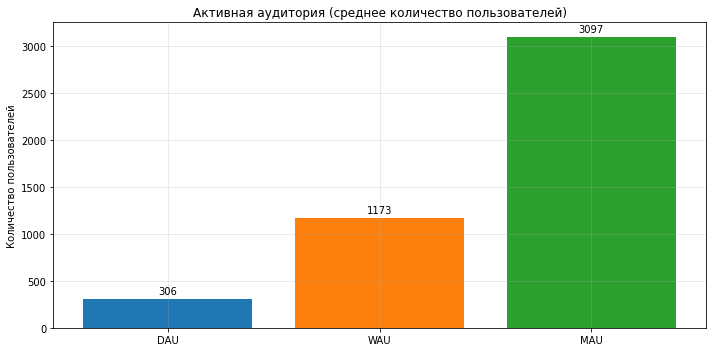

In [31]:
plt.figure(figsize=(10, 5))
bars = plt.bar(categories, values, color=colors)
plt.title('Активная аудитория (среднее количество пользователей)')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
for bar, value in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01,
             f'{value:.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()      
plt.show()

*Среднее количество активных пользователей в день составило 306 человек, в неделю - 1173, в месяц - 3097.*

*Для анализа основных метрик бизнеса из дат выделим месяц и вычислим общие метрики:*

In [32]:
orders['order_month'] = orders['order_date'].dt.to_period('M')
events['event_month'] = events['event_date'].dt.to_period('M')
users['reg_month'] = users['registration_date'].dt.to_period('M')

In [33]:
total_users = users['user_id'].nunique()
total_orders = orders['order_id'].nunique()
total_revenue = orders['total_price'].sum()
total_paying_users = orders['user_id'].nunique()

In [34]:
monthly_metrics = orders.groupby('order_month').agg({
    'order_id': 'count', #общее количество заказов
    'total_price': 'sum', #общая сумма заказов
    'marketplace_revenue': 'sum', #общая выручка с комиссии маркетплейса
    'user_id': 'nunique', #количество пользователей
    'quantity': 'sum' #количество единиц товаров в заказе
}).reset_index()

In [35]:
monthly_metrics.columns = ['month', 'orders_count', 'total_revenue', 'marketplace_revenue', 'paying_users', 'items_sold']

In [36]:
mau = events.groupby('event_month')['user_id'].nunique().reset_index()
mau.columns = ['month', 'mau']

In [37]:
new_users = users.groupby('reg_month')['user_id'].nunique().reset_index()
new_users.columns = ['month', 'new_users']

In [38]:
monthly_metrics = monthly_metrics.merge(mau, on='month', how='left')
monthly_metrics = monthly_metrics.merge(new_users, on='month', how='left')

*Рассчитаем метрики AOV (средний чек пользователя), ARPU (средняя выручка от одного активного пользователя), ARPPU (средняя выручка от одного платящего пользователя) и CR (конверсия в заказ):*

In [39]:
monthly_metrics['aov'] = monthly_metrics['total_revenue'] / monthly_metrics['orders_count']  # средняя сумма заказа
monthly_metrics['arpu'] = monthly_metrics['marketplace_revenue'] / monthly_metrics['mau'].replace(0, np.nan)  # средняя выручка на одного пользователя
monthly_metrics['arppu'] = (monthly_metrics['marketplace_revenue'] / monthly_metrics['paying_users'].replace(0, np.nan))  # средняя выручка от одного платящего пользователя
monthly_metrics['conversion_rate'] = (monthly_metrics['paying_users'] / monthly_metrics['mau'].replace(0, np.nan) * 100)  # конверсия в заказ

*Соберем все данные в один датасет:*

In [40]:
monthly_dynamics = monthly_metrics.copy()
monthly_dynamics[['aov', 'arpu', 'arppu', 'conversion_rate']] = \
    monthly_dynamics[['aov', 'arpu', 'arppu', 'conversion_rate']].round(2)

In [41]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [42]:
display(monthly_dynamics)

,month,orders_count,total_revenue,marketplace_revenue,paying_users,items_sold,mau,new_users,aov,arpu,arppu,conversion_rate
0,2024-01,964,12977800.53,648890.03,454,1918,1149,2985,13462.45,564.74,1429.27,39.51
1,2024-02,1917,25931140.19,1296557.01,839,3851,2162,2711,13526.94,599.70,1545.36,38.81
2,2024-03,2791,38814995.89,1940749.79,1165,5640,2844,2965,13907.20,682.40,1665.88,40.96
3,2024-04,3124,42856767.90,2142838.39,1324,6240,3059,2905,13718.56,700.50,1618.46,43.28
4,2024-05,3518,49575162.02,2478758.10,1404,6996,3310,3066,14091.86,748.87,1765.50,42.42
5,2024-06,3058,42120237.13,2106011.86,1230,6075,3174,2810,13773.79,663.52,1712.20,38.75
6,2024-07,3413,48930709.06,2446535.45,1385,6855,3481,4388,14336.57,702.83,1766.45,39.79
7,2024-08,3393,49316047.93,2465802.40,1385,6823,3861,4431,14534.64,638.64,1780.36,35.87
8,2024-09,2756,38707333.94,1935366.70,1163,5553,3744,4466,14044.75,516.92,1664.12,31.06
9,2024-10,2478,34322165.12,1716108.26,999,4998,3581,4440,13850.75,479.23,1717.83,27.90


*Перейдем к визуализации метрик:*

*Новые зарегистрированные пользователи:*

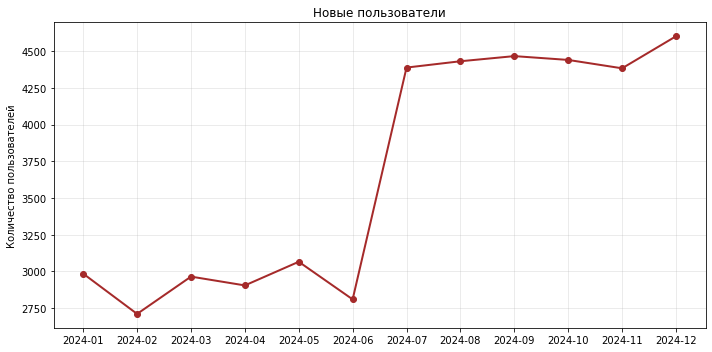

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['new_users'], marker='o', linewidth=2, color='brown')
plt.title('Новые пользователи')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Количество новых пользователей в июле резко выросло относительно июня (в июне таких пользователей было 2810, а в июле уже 4388). Вероятно в июне была запущена маркетинговая кампания, которая прошла успешно и привлекла большое количество новых пользователей. Далее график остается примерно на одном уровне и к концу года количество новых пользователей немного растет.*

*Динамика выручки маркетплейса по месяцам:*

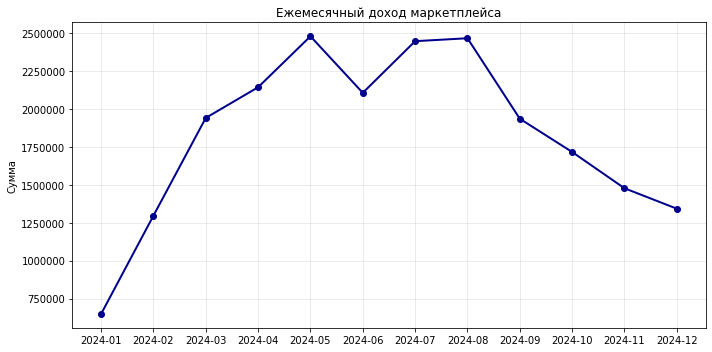

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['marketplace_revenue'], marker='o', linewidth=2, color='darkblue')
plt.title('Ежемесячный доход маркетплейса')
plt.ylabel('Сумма')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(axis='y', style='plain')
plt.tight_layout()
plt.show()

*Количество заказов и покупателей:*

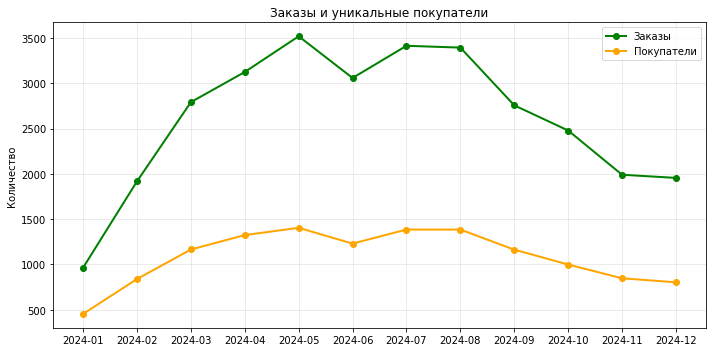

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['orders_count'], label='Заказы', marker='o', linewidth=2, color='green')
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['paying_users'], label='Покупатели', marker='o', linewidth=2, color='orange')
plt.title('Заказы и уникальные покупатели')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

*Графики выручки, общего количества заказов и покупателей по месяцам идентичны. Наблюдается постепенный рост с начала года и первый пик достигается в мае. На это могли повлиять майкие праздники, когда пользователи активнее заказывают какие-либо товары. Далее идет небольшой спад и снова подъём в июле-августе, что также может свидетельствовать о том, что в июне была проведена хорошая маркетинговая кампания, которая могла повлиять на увеличение количества заказов и выручки. А далее идет спад, в том числе к концу декабря, когда пользователи начинают активно покупать подарки к Новому году.*

*Проанализируем детальнее метрику MAU (Активные пользователи за месяц):*

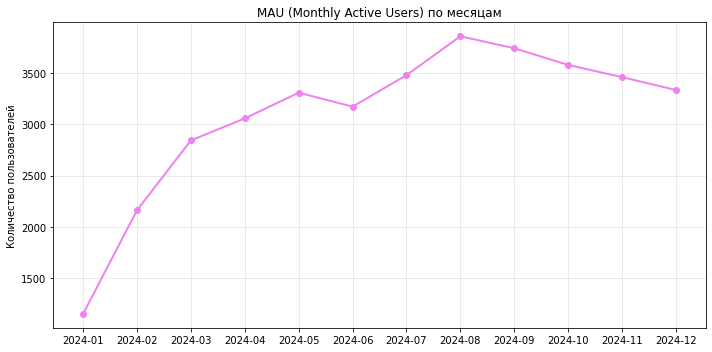

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['mau'], marker='o', linewidth=2, color='violet')
plt.title('MAU (Monthly Active Users) по месяцам')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Активность пользователей ежемесячно росла до мая 2024 года (3310 пользователей), далее произошел спад и метрика вновь начала расти с июля и достигла пика в августе (3861 пользователей). Однако, начиная с сентября наблюдается плавное снижение активности пользователей до конца года (3336 пользователей).*

*Исследуем среднюю стоимость заказов пользователей на маркетплейсе (AOV):*

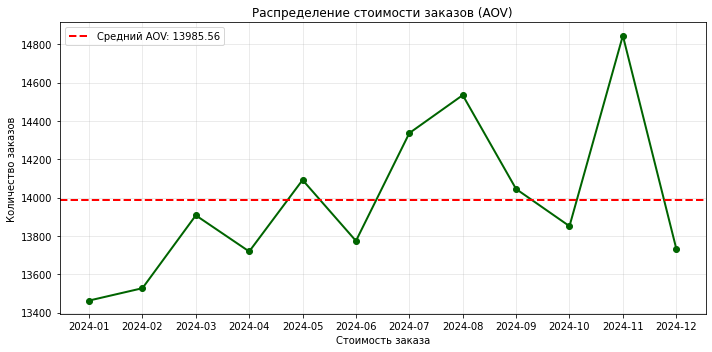

In [47]:
avg_aov = monthly_dynamics['aov'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['aov'], marker='o', linewidth=2, color='darkgreen')
plt.axhline(y=avg_aov, color='red', linestyle='--', linewidth=2,  label=f'Средний AOV: {avg_aov:.2f}')
plt.title('Распределение стоимости заказов (AOV)')
plt.xlabel('Стоимость заказа')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

*Наблюдается плавный волнообразный рост средней стоимости заказов, который увеличивается в июле (14336.57), но в сентябре снова резкий спад. Далее в ноябре виден рост средней стоимости (14845.23) и потом в декабре метрика вновь идет на спад. Исследуем распределение средней стоимости заказов среди пользователей:*

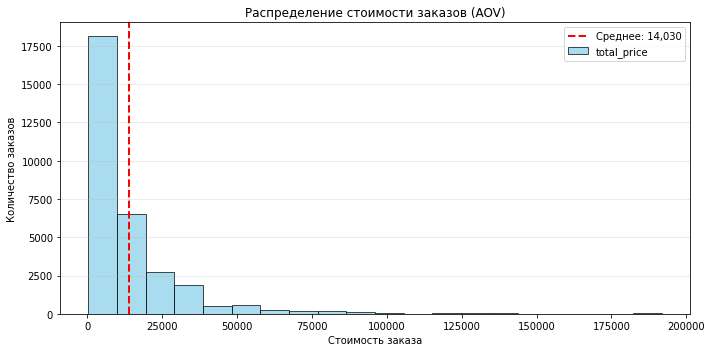

In [48]:
plt.figure(figsize=(10, 5))
orders['total_price'].plot.hist(bins=20, color='skyblue', edgecolor='black', alpha=0.7)
mean_aov = orders['total_price'].mean()
plt.axvline(x=mean_aov, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_aov:,.0f}')
plt.title('Распределение стоимости заказов (AOV)')
plt.xlabel('Стоимость заказа')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

*Большая часть пользователей совершает недорогие покупки ниже средней стоимости заказов, однако встречаются и крупные покупатели, которые тратят на покупки от 175 000 до 200 000.*

*Теперь проанализируем среднюю выручку от одного пользователя (ARPU) и от одного платящего пользователя (ARPPU):*

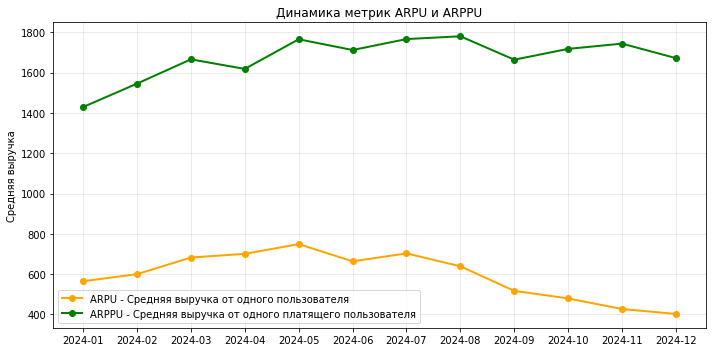

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['arpu'], label='ARPU - Средняя выручка от одного пользователя', marker='o', linewidth=2, color='orange')
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['arppu'], label='ARPPU - Средняя выручка от одного платящего пользователя', marker='o', linewidth=2, color='green')
plt.title('Динамика метрик ARPU и ARPPU')
plt.ylabel('Средняя выручка')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**ARPU** - *средняя выручка маркетплейса на пользователя с начала года начинает расти, достигает пика в мае (748.87). Далее идет спад в июне, небольшой рост в июле и начиная с августа метрика резко падает вниз (если в январе средняя выручка на пользователя 564.74, то в декабре уже 402.43.*

**ARPPU** - *метрика, которая отображает среднюю выручку маркетплейса от одного платящего пользователя (а не просто на пользователя маркетплейса, который мог не взаимодействовать с сервисом). Здесь более плавные показатели. Также наблюдается рост выручки в мае и июле, достигая пика в августе (1780.36), а далее идет небольшой, но не критичный спад*.

*Разная динамика ARPU и ARPPU указывает на увеличение доли неактивных/малоактивных пользователей при сохранении качества платящей базы.*

*Перейдем к анализу конверсии в заказ (сколько пользователей в итоге переходят к оформлению заказа):*

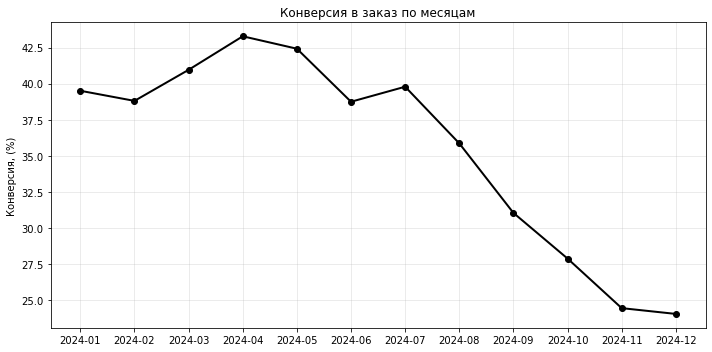

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_dynamics['month'].astype(str), monthly_dynamics['conversion_rate'], marker='o', linewidth=2, color='black')
plt.title('Конверсия в заказ по месяцам')
plt.ylabel('Конверсия, (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Конверсия в заказ отражает долю платящих пользователей от активных пользователей маркетплейса по месяцам. Пик метрики достигается в апреле (43.28% активных пользователей стали платящими), далее метрика имеет тенденцию к резкому спаду (всего 24.07% в конце года относительно 39.51% в начале года), лишь немного поднимаясь в июле. Очевидно, что пользователи продолжают заходить на платформу (активность сохраняется), но всё реже совершают заказы.*

*Проверим количество пользователей на каждом этапе событий:*

In [51]:
event_counts = events['event_type'].value_counts()
print("Распределение событий:")
print(event_counts)

Распределение событий:
,page_view            125663
,product_view         125318
,product_click        121946
,add_to_cart          110675
,checkout_start        92401
,checkout_complete     84012
,filter_apply          14243
,user_login            14109
,category_view         14040
,remove_from_cart      14034
,user_logout           13981
,promo_view            13935
,search                13909
,banner_click          13826
,wishlist_add          13767
,Name: event_type, dtype: int64


*Проанализируем метрику CTR - коэффициент "кликабельности". Оценим, насколько хорошо превью товара мотивирует открыть 
карточку:*

In [52]:
product_views = events[events['event_type'] == 'product_view'].shape[0]
product_clicks = events[events['event_type'] == 'product_click'].shape[0]

ctr_norm = product_clicks / product_views * 100
print(f"CTR карточек товара: {ctr_norm:.2f}%")

CTR карточек товара: 97.31%


*CTR карточек товара по данным (product_click / product_view) составляет 97.31%.
Такой показатель является аномально высоким и не отражает реального поведения пользователей.
Причина — особенности логирования: количество событий product_click значительно выше количества product_view, что указывает на множественные клики внутри карточки или технические события, фиксируемые системой.*

*Проанализируем, какой процент пользователей возвращается к использованию сервиса (рассчитаем **Retention Rate**):*

*Объединяем данные о пользователях с данными о событиях:*

In [53]:
users_events = pd.merge(users[['user_id', 'cohort_month' ]],
events[['user_id', 'event_month']],
on='user_id',
how='inner')

In [54]:
users_events['event_month'] = users_events['event_month'].dt.to_timestamp()

*Убираем события, произошедшие раньше регистрации:*

In [55]:
users_events = users_events[users_events['event_month'] >= users_events['cohort_month']]

*Определяем номер периода:*

In [56]:
users_events['n_period'] = (
users_events['event_month'].dt.to_period('M').astype('int64')
- users_events['cohort_month'].dt.to_period('M').astype('int64')
)

*Активность по когортам:*

In [57]:
cohort_activity = (
    users_events.groupby(['cohort_month', 'n_period'])['user_id']
      .nunique()
      .reset_index()
)

*Размеры когорты:*

In [58]:
cohort_sizes = users.groupby('cohort_month')['user_id'].nunique()

*Создаем сводную таблицу retention:*

In [59]:
retention = cohort_activity.pivot_table(
    index='cohort_month',
    columns='n_period',
    values='user_id'
)

In [60]:
retention = retention.fillna(0)
retention[0] = cohort_sizes

*Делим на период 0:*

In [61]:
retention = retention.div(retention[0], axis=0)
retention = retention.replace(0, np.nan)

*Визуализируем, используя тепловую карту для наглядности результатов:*

In [62]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

In [63]:
retention.index = pd.to_datetime(retention.index).strftime('%Y-%m-%d')

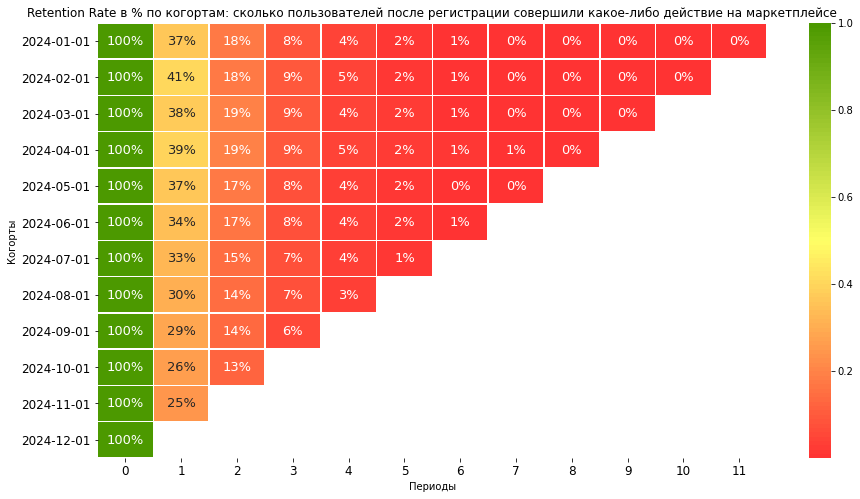

In [64]:
plt.subplots(figsize=(15, 8))
sns.heatmap(retention,
cmap=cmap,
annot=True,
fmt='.0%',
linewidth=0.5,
annot_kws={"size":13})
plt.title('Retention Rate в % по когортам: сколько пользователей после регистрации совершили какое-либо действие на маркетплейсе')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) 
plt.show()

*Retention показывает довольно резкий спад: спустя месяц возвращается лишь 25–40% пользователей, что ниже желаемого уровня для маркетплейса. Через 2 месяца остаётся только 13-19%, а к 6-му месяцу — 1–2%, что говорит о слабой долгосрочной лояльности. Последние когорты (осень 2024) заметно хуже предыдущих, что может указывать на сезонность или низкую заинтересованность приложением. Требуется работа над вовлечением и повторным возвращением.*

### 3. Оценка метрик монетизации и юнит-экономики

*Для начала рассчитаем среднюю стоимость привлечения пользователя (**CAC**) в разрезе каждого месяца:*

In [65]:
first_visits = users.groupby('user_id')['registration_date'].min().reset_index()
first_visits['month'] = first_visits['registration_date'].dt.to_period('M')

In [66]:
new_users_monthly = first_visits.groupby('month')['user_id'].nunique().reset_index()
new_users_monthly = new_users_monthly.rename(columns={'user_id': 'total_users'})

In [67]:
campaign_costs['month'] = campaign_costs['spend_month'].dt.to_period('M')

In [68]:
costs_monthly = campaign_costs.groupby('month')['budget'].sum().reset_index()

In [69]:
cac_data = costs_monthly.merge(new_users_monthly, on='month', how='left')

In [70]:
cac_data['cac'] = cac_data['budget'] / cac_data['total_users']

In [71]:
cac_data['month'] = pd.to_datetime(cac_data['month'].astype(str))
cac_data = cac_data.dropna()

In [72]:
display(cac_data)

,month,budget,total_users,cac
0,2024-01-01,1177456.97,2985.00,394.46
1,2024-02-01,1061385.93,2711.00,391.51
2,2024-03-01,1167680.37,2965.00,393.82
3,2024-04-01,1147739.92,2905.00,395.09
4,2024-05-01,1225322.28,3066.00,399.65
5,2024-06-01,1130439.77,2810.00,402.29
6,2024-07-01,1776446.60,4388.00,404.84
7,2024-08-01,1811677.75,4431.00,408.86
8,2024-09-01,1820718.83,4466.00,407.68
9,2024-10-01,1810802.57,4440.00,407.84


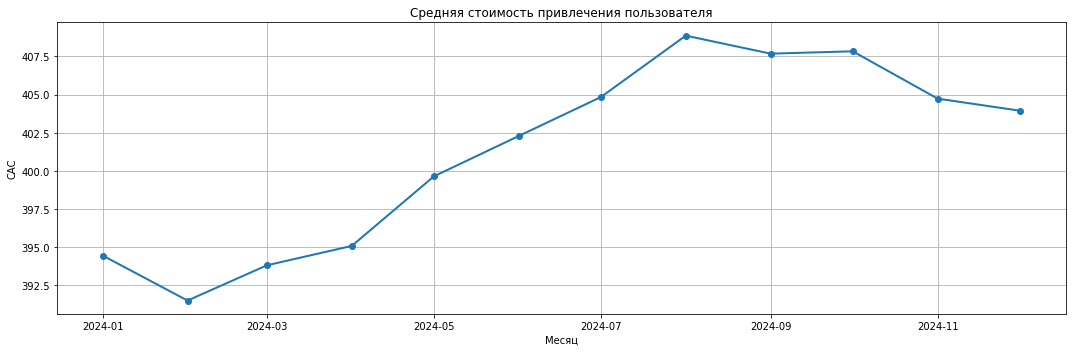

In [73]:
plt.figure(figsize=(15, 5))
plt.plot(cac_data['month'], cac_data['cac'], marker='o', linewidth=2)
plt.title('Средняя стоимость привлечения пользователя')
plt.xlabel('Месяц')
plt.ylabel('CAC')
plt.grid(True)
plt.tight_layout()
plt.show()

*Cредняя стоимость привлечения одного клиента растет до августа и на пике составляет 408.86. В сентябре - октябреCAC немного снижается, но остается выше уровня первых месяцев года, что говорит о стабильном увеличении стоимости привлечения в долгосрочном тренде.*

*Теперь рассчитаем значение LTV (пожизненная ценность клиента) и ROI (коэффициент окупаемости) с учётом покупок, совершённых за 60 дней с момента привлечения. Для начала добавим 60 дней к дате привлечения:*

*Теперь рассчитаем значение LTV (пожизненная ценность клиента) и ROI (коэффициент окупаемости):*

*Соединяем `first_users` с данными о заказах:*

In [74]:
users_orders = pd.merge(first_visits[['user_id', 'registration_date', 'month']],
                            orders, on='user_id', how = 'inner')

*Группируем по месяцам и считаем выручку маркетплейса:*

In [75]:
revenue_by_month = users_orders.groupby('month')['marketplace_revenue'].sum().reset_index()
revenue_by_month = revenue_by_month.rename(columns={'marketplace_revenue': 'total_marketplace_revenue'})
revenue_by_month['month'] = pd.to_datetime(revenue_by_month['month'].astype(str))

In [76]:
ltv_data = cac_data.merge(revenue_by_month, on='month', how='left')
display (ltv_data)

,month,budget,total_users,cac,total_marketplace_revenue
0,2024-01-01,1177456.97,2985.00,394.46,2105090.29
1,2024-02-01,1061385.93,2711.00,391.51,2052689.15
2,2024-03-01,1167680.37,2965.00,393.82,2481937.70
3,2024-04-01,1147739.92,2905.00,395.09,2456668.31
4,2024-05-01,1225322.28,3066.00,399.65,2246673.71
5,2024-06-01,1130439.77,2810.00,402.29,1891357.64
6,2024-07-01,1776446.60,4388.00,404.84,2480705.40
7,2024-08-01,1811677.75,4431.00,408.86,1883228.28
8,2024-09-01,1820718.83,4466.00,407.68,1446349.32
9,2024-10-01,1810802.57,4440.00,407.84,1107371.11


*Рассчитаем LTV и ROI по месяцам:*

In [77]:
ltv_data['ltv'] = ltv_data['total_marketplace_revenue'] / ltv_data['total_users']
ltv_data['roi'] = (ltv_data['ltv'] - ltv_data['cac']) / ltv_data['cac'] * 100
display(ltv_data)

,month,budget,total_users,cac,total_marketplace_revenue,ltv,roi
0,2024-01-01,1177456.97,2985.00,394.46,2105090.29,705.22,78.78
1,2024-02-01,1061385.93,2711.00,391.51,2052689.15,757.17,93.40
2,2024-03-01,1167680.37,2965.00,393.82,2481937.70,837.08,112.55
3,2024-04-01,1147739.92,2905.00,395.09,2456668.31,845.67,114.04
4,2024-05-01,1225322.28,3066.00,399.65,2246673.71,732.77,83.35
5,2024-06-01,1130439.77,2810.00,402.29,1891357.64,673.08,67.31
6,2024-07-01,1776446.60,4388.00,404.84,2480705.40,565.34,39.64
7,2024-08-01,1811677.75,4431.00,408.86,1883228.28,425.01,3.95
8,2024-09-01,1820718.83,4466.00,407.68,1446349.32,323.86,-20.56
9,2024-10-01,1810802.57,4440.00,407.84,1107371.11,249.41,-38.85


*Визуализируем:*

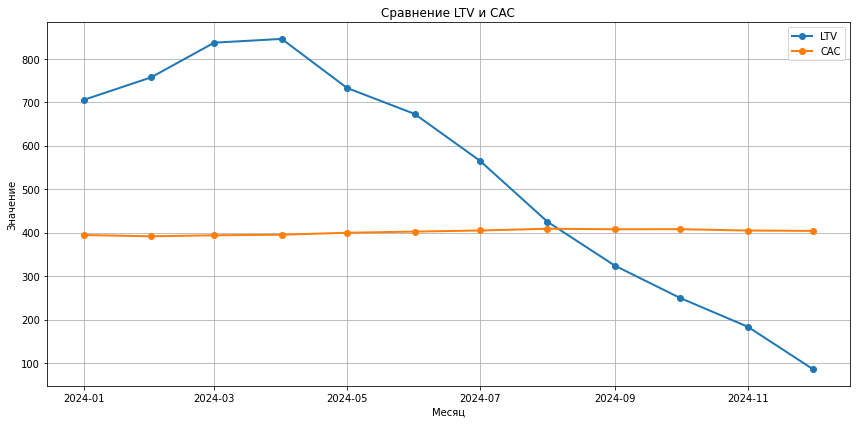

In [78]:
plt.figure(figsize=(12, 6))
plt.plot(ltv_data['month'], ltv_data['ltv'], label='LTV', marker='o', linewidth=2)
plt.plot(ltv_data['month'], ltv_data['cac'], label='CAC', marker='o', linewidth=2)
plt.title('Сравнение LTV и CAC')
plt.xlabel('Месяц')
plt.ylabel('Значение')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*В первые месяцы LTV значительно превышает CAC, что делает привлечение пользователей прибыльным. Однако начиная с апреля наблюдается резкое снижение LTV при стабильном уровне CAC — к концу года стоимость привлечения становится выше, чем доход от пользователя. Это означает ухудшение окупаемости маркетинга и рост рисков убыточного привлечения.:*

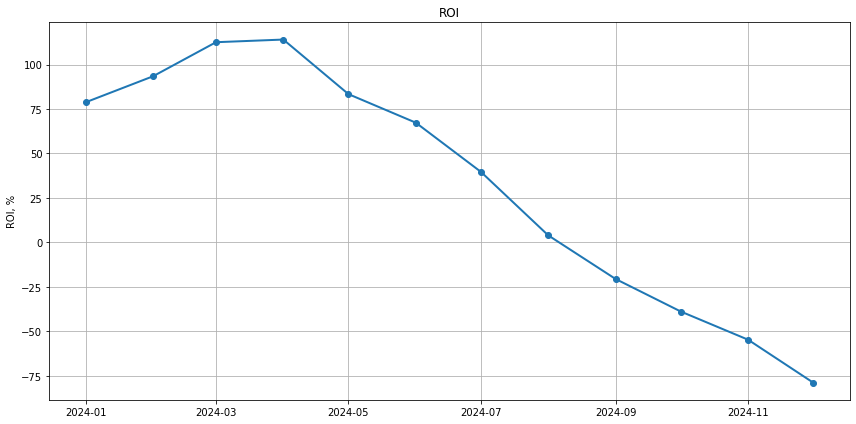

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(ltv_data['month'], ltv_data['roi'], marker='o', linewidth=2)
plt.title('ROI')
plt.ylabel('ROI, %')
plt.grid(True)
plt.tight_layout()
plt.show()

*ROI показывает, что первые месяцы привлечения были прибыльными: январь–апрель дают положительный возврат, достигая пика около 114% в апреле.Начиная с мая, эффективность начинает постепенно снижаться, а с августа ROI уходит в отрицательную зону, что означает, что компания тратит больше на привлечение пользователей, чем зарабатывает на них.*

*Проанализируем ROI детальнее, чтобы понять, как быстро “окупаются” пользователи каждой когорты после регистрации. Создадим когортный датасет.*

In [80]:
orders['order_month'] = orders['order_date'].dt.to_period('M')
first_visits['cohort_month'] = first_visits['registration_date'].dt.to_period('M')
orders_cohort = orders.merge(first_visits[['user_id', 'cohort_month']], on='user_id', how='left')

*Возраст пользователя в месяцах:*

In [81]:
orders_cohort['order_month'] = orders_cohort['order_month'].astype('period[M]')
orders_cohort = orders_cohort.dropna(subset=['cohort_month'])

*Вычисляем возраст когорты:*

In [82]:
age = orders_cohort['order_month'] - orders_cohort['cohort_month']
orders_cohort['cohort_age'] = age.apply(lambda x: x.n if hasattr(x, "n") else np.nan).astype("float")

*Доход по когортам и месяцам жизни когорты:*

In [83]:
cohort_revenue = orders_cohort.groupby(['cohort_month', 'cohort_age'])['marketplace_revenue'].sum().reset_index()

*Количество новых пользователей по когортам:*

In [84]:
cohort_users = (first_visits.groupby('cohort_month')['user_id'].nunique().reset_index()
    .rename(columns={'user_id': 'new_users'}))

*Присоединяем CAC к когортам:*

In [85]:
cac_data['month'] = pd.to_datetime(cac_data['month']).dt.to_period('M')
cohort_users['cohort_month'] = cohort_users['cohort_month'].astype('period[M]')
cohort_base = cohort_users.merge(cac_data[['month', 'cac']], left_on='cohort_month',
    right_on='month', how='left').drop(columns=['month'])

*Добавляем кумулятивный LTV:*

In [86]:
cohort_revenue['cohort_month'] = cohort_revenue['cohort_month'].astype('period[M]')
cohort_base['cohort_month'] = cohort_base['cohort_month'].astype('period[M]')
cohort_ltv = cohort_revenue.merge(cohort_base, on='cohort_month', how='left')
cohort_ltv['ltv_step'] = cohort_ltv['marketplace_revenue'] / cohort_ltv['new_users']
cohort_ltv['ltv_cum'] = cohort_ltv.groupby('cohort_month')['ltv_step'].cumsum()

*Добавляем кумулятивный ROI:*

In [87]:
cohort_ltv['roi'] = (cohort_ltv['ltv_cum'] - cohort_ltv['cac']) / cohort_ltv['cac']

*Создаём матрицу для тепловой карты:*

In [88]:
roi_matrix = cohort_ltv.pivot(index='cohort_month', columns='cohort_age', values='roi')

*Строим тепловую карту кумулятивного ROI по когортам и возрасту когорты:*

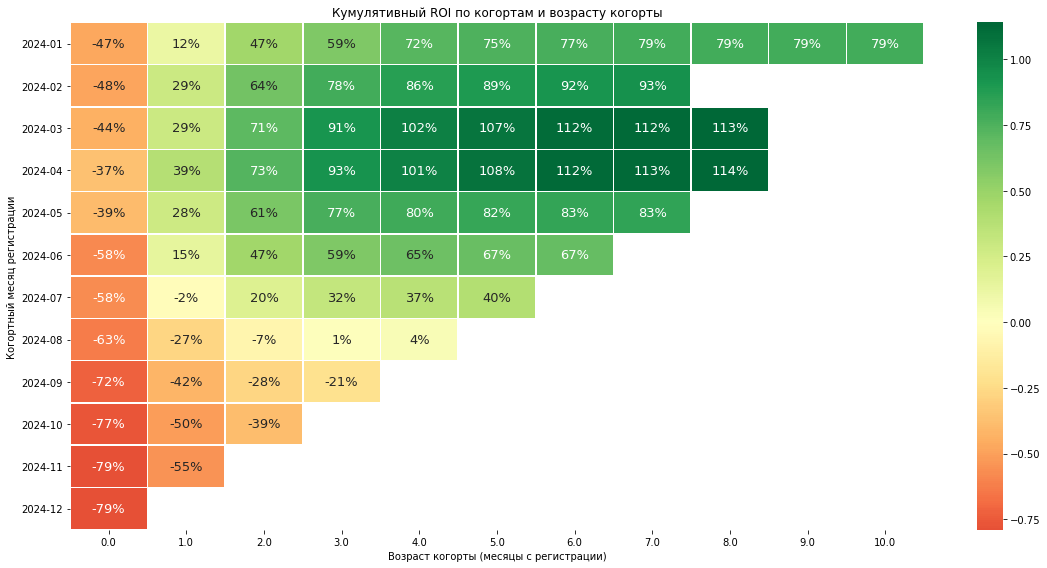

In [89]:
plt.figure(figsize=(16, 8))
sns.heatmap(
    roi_matrix,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    center=0,
    linewidth=0.5,
    annot_kws={"size":13}
)

plt.title('Кумулятивный ROI по когортам и возрасту когорты')
plt.xlabel('Возраст когорты (месяцы с регистрации)')
plt.ylabel('Когортный месяц регистрации')
plt.tight_layout()
plt.show()

*Как интерпретировать данную карту:*

- *Строки - месяцы регистрации (когорты).*
- *Столбцы - возраст когорты (сколько месяцев прошло после регистрации).*
- *Ячейка - кумулятивный ROI на этом месяце жизни когорты.*

*ROI > 0%  — когорты окупились и приносят прибыль. ROI около 0% — когорты вышли в ноль. ROI < 0% — когорты пока убыточны*

*Когорты начала года (2024-01 – 2024-04) окупаются быстро и растут стабильно.Это лучшие пользователи — либо была сильная кампания, либо сезонный пик, либо платёжеспособная аудитория. Когорты поздней весны и лета (2024-05 – 2024-07) окупаются медленнее и растут хуже. Финальный ROI достаточно низкий, что уже начинает отображать ухудшение трафика. Осенние когорты (2024-08 – 2024-11) — проблемные. ROI около или ниже 0. Вероятно, ROI падает из-за дорогих или низкокачественных источников.*

*Добавим к нашему датасету метрики, которые мы вычислили ранее (AOV - средняя стоимость заказов пользователей на маркетплейсе и ARPU - средняя выручка маркетплейса на одного пользователя):*

In [90]:
ltv_data['month_period'] = ltv_data['month'].dt.to_period('M')

In [91]:
ltv_data = ltv_data.merge(
    monthly_dynamics[['month', 'aov', 'arpu']],
    left_on='month_period',
    right_on='month',
    how='left'
)

In [92]:
ltv_data = ltv_data.drop(['month_period', 'month_y'], axis=1)
ltv_data = ltv_data.rename(columns={'month_x': 'month'})

In [93]:
display(ltv_data)

,month,budget,total_users,cac,total_marketplace_revenue,ltv,roi,aov,arpu
0,2024-01-01,1177456.97,2985.00,394.46,2105090.29,705.22,78.78,13462.45,564.74
1,2024-02-01,1061385.93,2711.00,391.51,2052689.15,757.17,93.40,13526.94,599.70
2,2024-03-01,1167680.37,2965.00,393.82,2481937.70,837.08,112.55,13907.20,682.40
3,2024-04-01,1147739.92,2905.00,395.09,2456668.31,845.67,114.04,13718.56,700.50
4,2024-05-01,1225322.28,3066.00,399.65,2246673.71,732.77,83.35,14091.86,748.87
5,2024-06-01,1130439.77,2810.00,402.29,1891357.64,673.08,67.31,13773.79,663.52
6,2024-07-01,1776446.60,4388.00,404.84,2480705.40,565.34,39.64,14336.57,702.83
7,2024-08-01,1811677.75,4431.00,408.86,1883228.28,425.01,3.95,14534.64,638.64
8,2024-09-01,1820718.83,4466.00,407.68,1446349.32,323.86,-20.56,14044.75,516.92
9,2024-10-01,1810802.57,4440.00,407.84,1107371.11,249.41,-38.85,13850.75,479.23


*Построим график, на котором отразим сравнение средней выручки маркетплейса на одного пользователя и затраты на привлечение)*

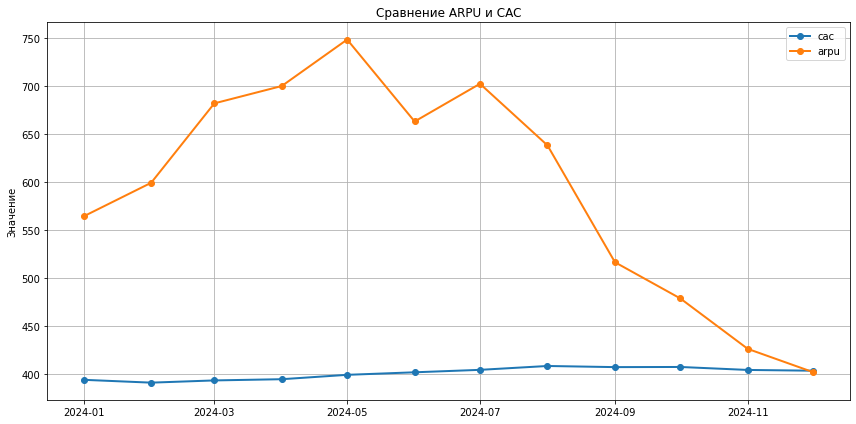

In [94]:
plt.figure(figsize=(12, 6))
plt.plot(ltv_data['month'], ltv_data['cac'], label='cac', marker='o', linewidth=2)
plt.plot(ltv_data['month'], ltv_data['arpu'], label='arpu', marker='o', linewidth=2)
plt.title('Сравнение ARPU и CAC')
plt.ylabel('Значение')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Очевидно, что ARPU ≈ CAC (в конце периода): к декабрю линии почти сходятся. Это тревожный сигнал — рентабельность снижается, компания почти не зарабатывает сверх затрат на привлечение.*

*Рассчитаем срок окупаемости вложений на привлечение пользователей:*

In [95]:
arpu_new = revenue_by_month['total_marketplace_revenue'] / new_users_monthly['total_users']
ltv_data['arpu_new'] = arpu_new
ltv_data['payback_period'] = ltv_data['cac'] / ltv_data['arpu_new']
ltv_data = ltv_data.drop(columns=['arpu_new'])

In [96]:
display(ltv_data)

,month,budget,total_users,cac,total_marketplace_revenue,ltv,roi,aov,arpu,payback_period
0,2024-01-01,1177456.97,2985.00,394.46,2105090.29,705.22,78.78,13462.45,564.74,0.56
1,2024-02-01,1061385.93,2711.00,391.51,2052689.15,757.17,93.40,13526.94,599.70,0.52
2,2024-03-01,1167680.37,2965.00,393.82,2481937.70,837.08,112.55,13907.20,682.40,0.47
3,2024-04-01,1147739.92,2905.00,395.09,2456668.31,845.67,114.04,13718.56,700.50,0.47
4,2024-05-01,1225322.28,3066.00,399.65,2246673.71,732.77,83.35,14091.86,748.87,0.55
5,2024-06-01,1130439.77,2810.00,402.29,1891357.64,673.08,67.31,13773.79,663.52,0.60
6,2024-07-01,1776446.60,4388.00,404.84,2480705.40,565.34,39.64,14336.57,702.83,0.72
7,2024-08-01,1811677.75,4431.00,408.86,1883228.28,425.01,3.95,14534.64,638.64,0.96
8,2024-09-01,1820718.83,4466.00,407.68,1446349.32,323.86,-20.56,14044.75,516.92,1.26
9,2024-10-01,1810802.57,4440.00,407.84,1107371.11,249.41,-38.85,13850.75,479.23,1.64


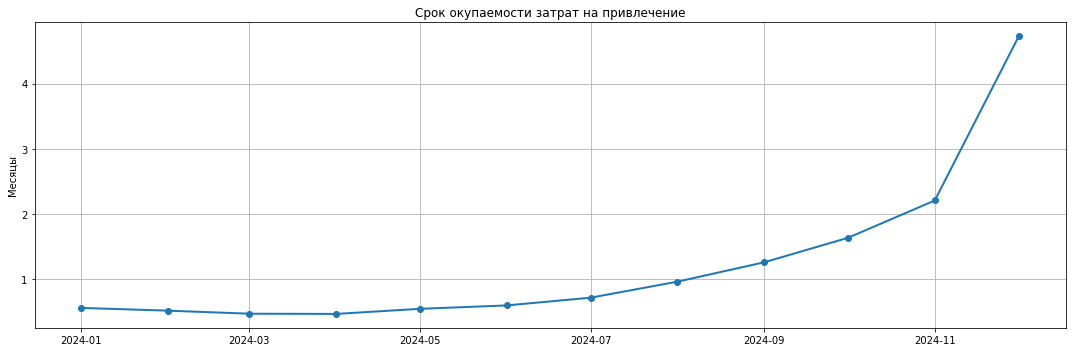

In [97]:
plt.figure(figsize=(15, 5))
plt.plot(ltv_data['month'], ltv_data['payback_period'], marker='o', linewidth=2)
plt.title('Cрок окупаемости затрат на привлечение')
plt.ylabel('Месяцы')
plt.grid(True)
plt.tight_layout()
plt.show()

*В первые месяцы клиенты окупались менее чем за 1 месяц, что очень хорошо. Начиная с лета, срок окупаемости начал увеличиваться. К осени он превысил 1–2 месяца, а к декабрю резко вырос до почти 5 месяцев. Вывод: эффективность привлечения ухудшается — клиенты приносят меньше выручки относительно стоимости привлечения, и бизнес окупает маркетинг всё дольше.*

## Выводы по этапам 2 и 3


**Аналитическая записка: обзор продуктовых метрик и юнит-экономики**

**Обзор ключевых продуктовых метрик.**

**Активность пользователей (DAU/WAU/MAU):**

- *Активность пользователей с начала года заметно растет и достигает пика в августе (3861 пользователей).*
- *Далее наблюдается плавное снижение вовлечённости во второй половине года и к концу года месячная активность пользователей держится на отметке 3336.*

**Выручка и ARPU:**

- *Средняя выручка на одного пользователя (ARPU) росла до мая (максимальное значение ARPU - 748.84 руб. на пользователя), затем начал снижаться и к концу года упала до 402.43 руб. на пользователя.*

- *Выручка маркетплейса следует той же траектории: пик весной, далее небольшое проседание в июне, в июле-августе показатели снова держатся на уровне мая, даоее наблюдается снижение осенью и зимой.*

**AOV (средний чек):**

- *Наблюдается плавный волнообразный рост средней стоимости заказов, который увеличивается в июле (14336.57), но в сентябре снова резкий спад. Далее в ноябре виден рост средней стоимости (14845.23) и потом в декабре метрика вновь идет на спад (средний чек декабря - 13733.94)*.

- *Пользователи стали покупать меньше и дешевле.*

**Retention (удержание пользователей):**

- *Удержание ухудшается: все когортные показатели снижаются.*
- *Клиенты из последних месяцев возвращаются заметно хуже, чем в начале года.*

**CTR и CR в заказ:**

- *CTR карточек товара по данным (product_click / product_view) составляет 97.31%. Такой показатель является аномально высоким и не отражает реального поведения пользователей. Необходимо проверить корректность логирования событий.*

- *CR в заказ резко снижается, начиная с июля. Несмотря на то, что пользователи достаточно активно заходят в приложение маркетплейса, они все реже совершают заказы. Если в апреде 43% пользователей переходили к оформлению заказа, то в конце года этот показатель упал до 24%.*


**Общий вывод:**
*В первой половине года продукт демонстрировал рост, но во второй — ощутимое снижение всех ключевых метрик: активности, среднего чека, ARPU и удержания. Это первые признаки ухудшения ценности продукта для пользователей.*

**Метрики монетизации и юнит-экономики:**

**CAC (стоимость привлечения клиента):**
- *Стоимость привлечения клиента постенно растет до августа и на пике составляет 408.86.*
- *В сентябре - октябре CAC немного снижается, но остается выше уровня первых месяцев года, что говорит о стабильном увеличении стоимости привлечения в долгосрочном тренде.*

**LTV (суммарный доход, который получает бизнес от одного клиента за весь период взаимодействия с продуктом (в нашем случае был выбран период 60 дней):**

- *LTV падает вслед за снижением ARPU и вовлечённости.*

- *Соотношение LTV/CAC ухудшается и приближается к неустойчивому. В первые месяцы LTV значительно превышает CAC, что делает привлечение пользователей прибыльным. Однако начиная с июня наблюдается резкое снижение LTV при стабильном уровне CAC — к концу года стоимость привлечения становится выше, чем доход от пользователя.* 

**ROI (коэффициент окупаемости вложений):**

- *ROI положительный до июля 2024 года, далее снижается и становится отрицательным уже в августе и сохраняет тенденцию к падению до конца года.*

- *Это означает: каждый привлечённый пользователь начинает приносить убыток.*

**Payback Period (срок окупаемости):**

- *В начале года клиенты окупались за 0.6–0.8 месяца — очень хороший показатель.*
- *В октябре срок окупаемости растёт до 2+ месяцев.*
- *В декабре достигает почти 5 месяцев, что уже неприемлемо при текущем уровне рисков и удержания.*

**Итоговый вывод:**

- *Рост продукта остановился. Несмотря на резкое увеличение количества новых пользователей в июле, во второй половине года наблюдается падение ключевых метрик: выручки, ARPU, AOV, активности пользователей и удержания.*

- *Пользователи становятся менее ценными. Они реже возвращаются и тратят меньше денег.*

- *CAC растёт, LTV падает. Соотношение LTV/CAC ухудшается, эффективность вложений снижается.*

- *ROI уходит в минус, а Payback Period растёт в 5 раз. Привлечение новых пользователей стало убыточным.*

- *Основной риск: при текущей динамике продукт теряет прибыльность, а маркетинг перестаёт окупаться.*

## 4. Поиск инсайтов, точек роста и сегментация


*Чтобы найти инсайты и точки роста, проанализируем данные в разрезах: по каналам, сегментам пользователей, категориям товаров, регионам, типам устройств.*

**Для начала проанализируем путь пользователя по типу устройства и типу операционной системы.**

*Чтобы понять, какой процент пользователей теряется на каждом этапе событий построим **классическую** воронку событий (конверсия относительно первого шага воронки) и **пошаговую** воронку (конверсия относительно предыдущего шага).*

In [98]:
funnel_steps = events['event_type'].unique()
display(funnel_steps)

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

*Из списка событий выберем те, что будут отражать важные для бизнеса показатели:*

In [99]:
funnel_sequence = [
    'page_view', # 1. Открыл страницу приложения
    'product_view', # 2. Посмотрел товар
    'add_to_cart', # 3. Добавил в корзину
    'checkout_start', # 4. Начал оформление
    'checkout_complete' # 5. Завершил оформление
]

*Фильтруем только эти события:*

In [100]:
event_steps = events[events['event_type'].isin(funnel_sequence)]

*Группируем в правильном порядке:*

In [101]:
event_steps = events[events['event_type'].isin(funnel_sequence)]
event_steps = event_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_sequence).reset_index()
event_steps = event_steps.rename(columns={'user_id': 'users_n'})

*Добавляем расчет конверсии для **классической** воронки:*

In [102]:
event_steps['conversion_from_first_step_%'] = event_steps['users_n'] / event_steps['users_n'].iloc[0] * 100

*Добавляем расчет конверсии для **пошаговой** воронки:*

In [103]:
event_steps['conversion_from_previous_step_%'] = event_steps['users_n'] / event_steps['users_n'].shift(1) * 100

*Визуализируем обе воронки, чтобы посмотреть, на каком этапе теряются пользователи:*

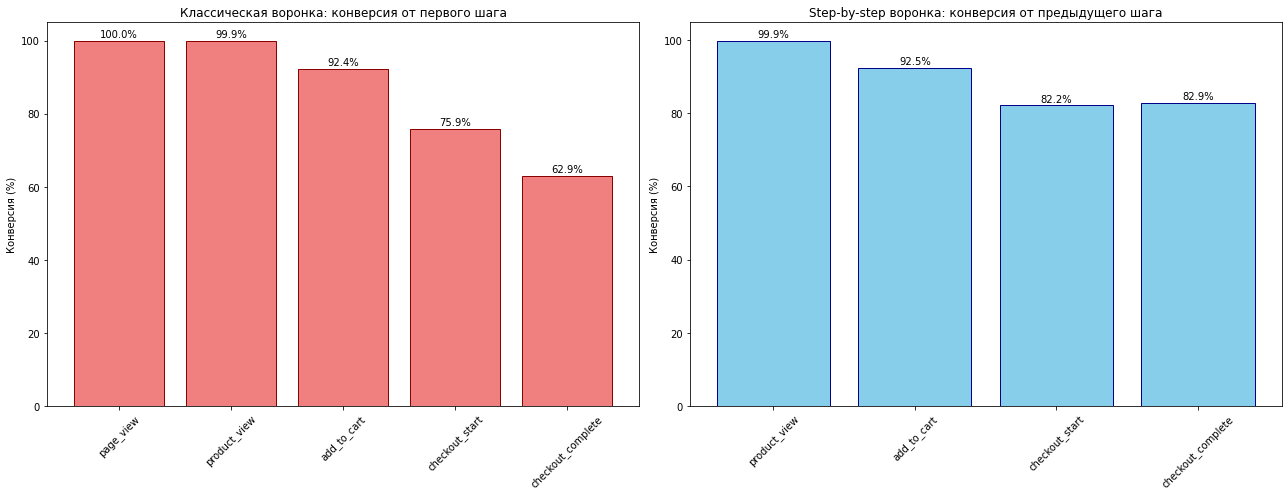

In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.bar(event_steps['event_type'], 
        event_steps['conversion_from_first_step_%'],
        color='lightcoral', edgecolor='darkred')

ax1.set_title('Классическая воронка: конверсия от первого шага')
ax1.set_ylabel('Конверсия (%)')

for idx, val in enumerate(event_steps['conversion_from_first_step_%']):
    ax1.text(idx, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

ax1.tick_params(axis='x', rotation=45)

ax2.bar(event_steps['event_type'],
        event_steps['conversion_from_previous_step_%'],
        color='skyblue', edgecolor='darkblue')

ax2.set_title('Step-by-step воронка: конверсия от предыдущего шага')
ax2.set_ylabel('Конверсия (%)')

for idx, val in enumerate(event_steps['conversion_from_previous_step_%']):
    if np.isfinite(val): 
        ax2.text(idx, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

ax2.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

*Классическая воронка показала нам, что до оформления заказа дошли только 62.9% пользователей от тех, кто зашел в приложение. Конверсия достаточно неплохая. Пошаговая воронка также показала достаточно плавный переход от одного шага к другому. Есть небольшой провал от добавления товара в корзину до начала оформления заказа (82.2% от тех, кто добавил товар в корзину переходят к оформлению. Тем не менее, на этапе завершения оформления наблюдается небольшой подъем, что говорит о том, что пользователи завершают оформление, а некоторые это делают сразу после добавления товара в корзину, пропуская шаг оформления. `Checkout_complete` показывает только момент завершения оформления заказа, но не гарантирует его покупку и стоит добавить столбец `purchase` в датасет, чтобы отобразить пользователей, которые купили товар, чтобы вычислить конверсию в покупку как от первого, так и от предыдущего шага.*

*Построим аналогичные воронки по типу устройства, чтобы выяснить, есть ли проседания по конверсии на каком-либо шаге воронки в зависимости от используемого устройства:*

In [105]:
unique_devices = events['device'].unique()
display(f"Уникальные типы устройств: {unique_devices}")

"Уникальные типы устройств: ['mobile' 'desktop' 'tablet']"

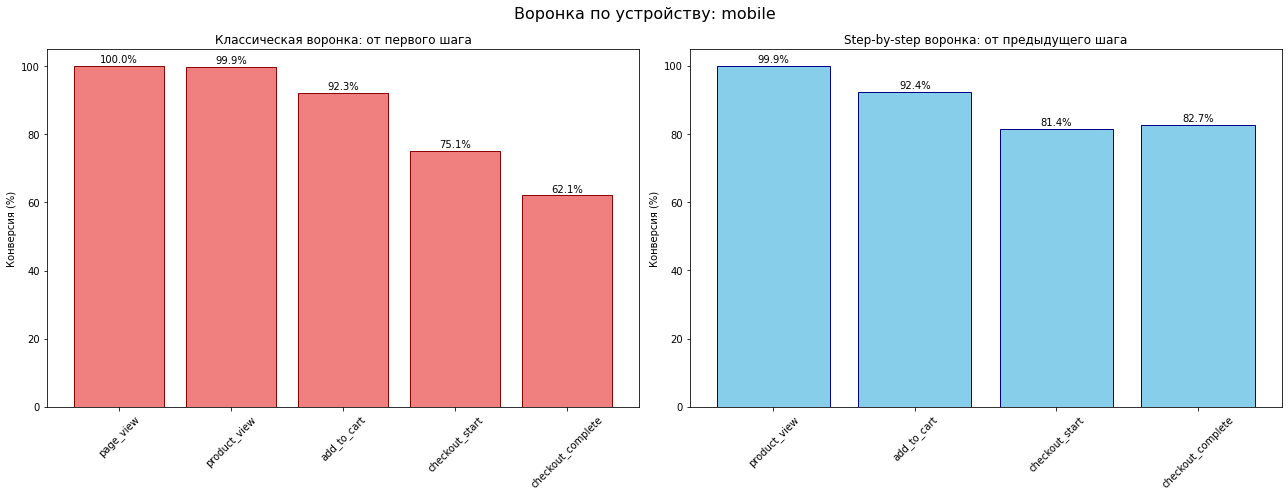

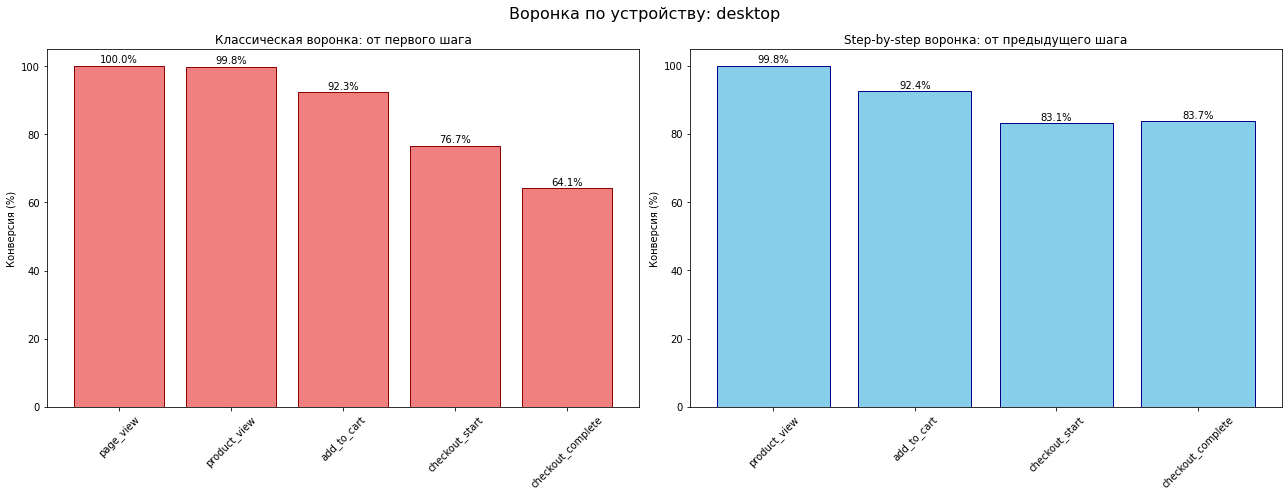

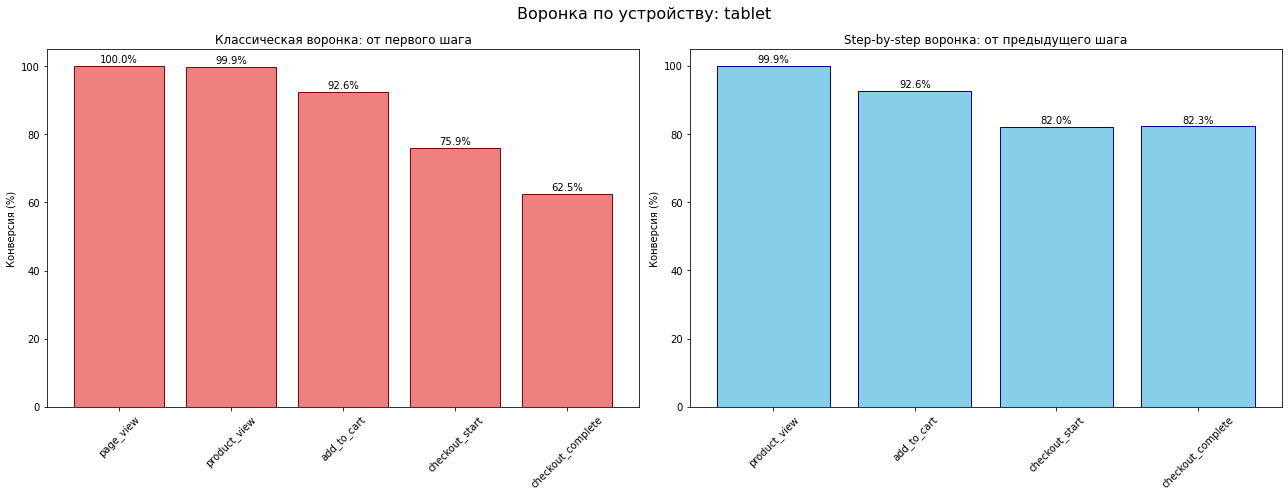

In [106]:
for device in unique_devices:
    device_events = events[events['device'] == device]

    # фильтруем только интересующие события
    event_steps = (
        device_events[device_events['event_type'].isin(funnel_sequence)]
        .groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_sequence)
        .reset_index()
        .rename(columns={'user_id': 'users_n'})
    )

    # Конверсии
    event_steps['conversion_from_first_step_%'] = (
        event_steps['users_n'] / event_steps['users_n'].iloc[0] * 100
    )

    event_steps['conversion_from_previous_step_%'] = (
        event_steps['users_n'] / event_steps['users_n'].shift(1) * 100
    )

    # --- Визуализация ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Воронка по устройству: {device}", fontsize=16)

    # Классическая воронка:
    ax1.bar(
        event_steps['event_type'],
        event_steps['conversion_from_first_step_%'],
        color='lightcoral',
        edgecolor='darkred'
    )
    ax1.set_title("Классическая воронка: от первого шага")
    ax1.set_ylabel("Конверсия (%)")
    ax1.tick_params(axis='x', rotation=45)

    for idx, val in enumerate(event_steps['conversion_from_first_step_%']):
        if np.isfinite(val):
            ax1.text(idx, val + 1, f"{val:.1f}%", ha='center')

    # Пошаговая воронка (step-by-step):
    ax2.bar(
        event_steps['event_type'],
        event_steps['conversion_from_previous_step_%'],
        color='skyblue',
        edgecolor='darkblue'
    )
    ax2.set_title("Step-by-step воронка: от предыдущего шага")
    ax2.set_ylabel("Конверсия (%)")
    ax2.tick_params(axis='x', rotation=45)

    for idx, val in enumerate(event_steps['conversion_from_previous_step_%']):
        if np.isfinite(val):
            ax2.text(idx, val + 1, f"{val:.1f}%", ha='center')

    plt.tight_layout()
    plt.show()

*Конверсия по воронкам примерно одинаковая, значит тип устройства, с которого пользователь заходит в приложение маркетплейса, не влияет на конверсию.*

*Далее аналогично построим **воронки по типу операционной системы** пользователей маркетплейса:*

In [107]:
unique_os = events['os'].unique()
display(f"Уникальные типы ОС: {unique_os}")

"Уникальные типы ОС: ['iOS' 'Windows' 'macOS' 'Android']"

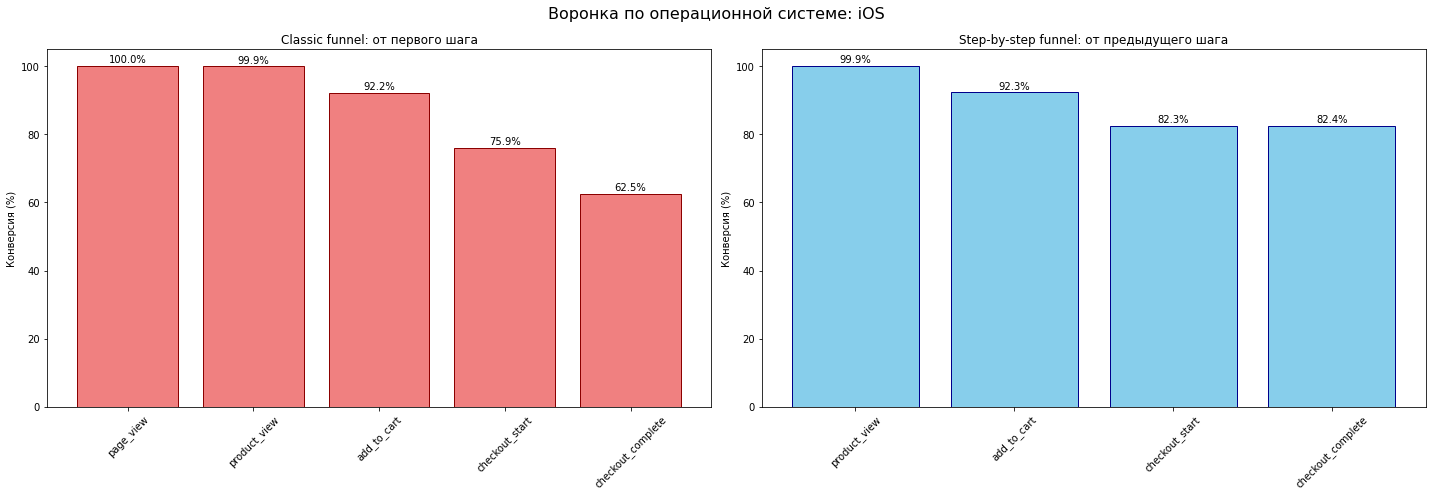

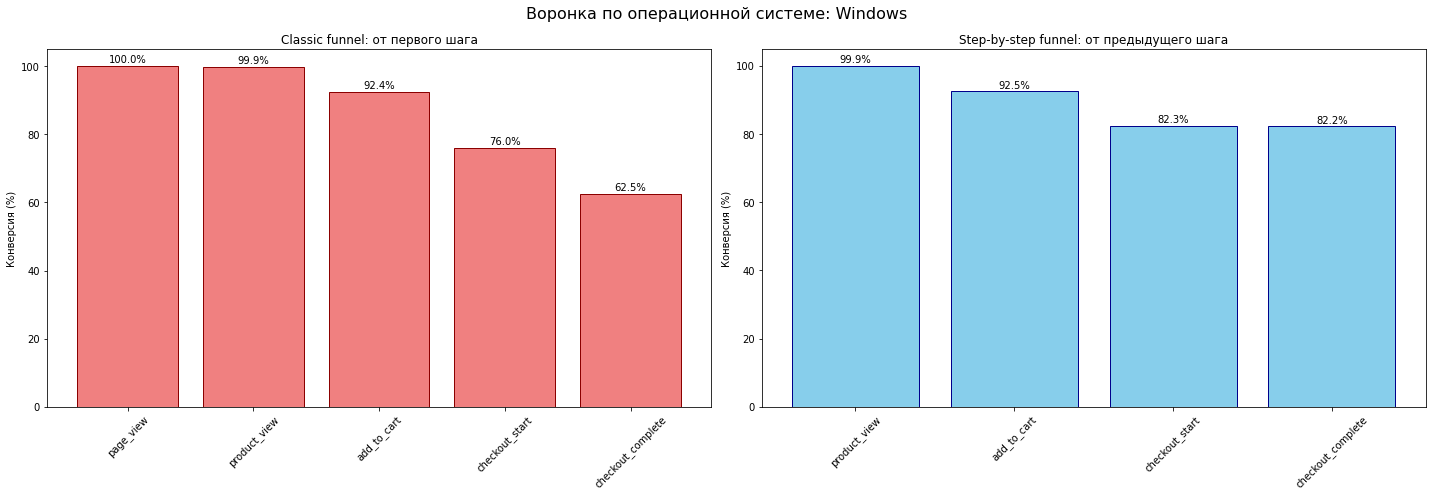

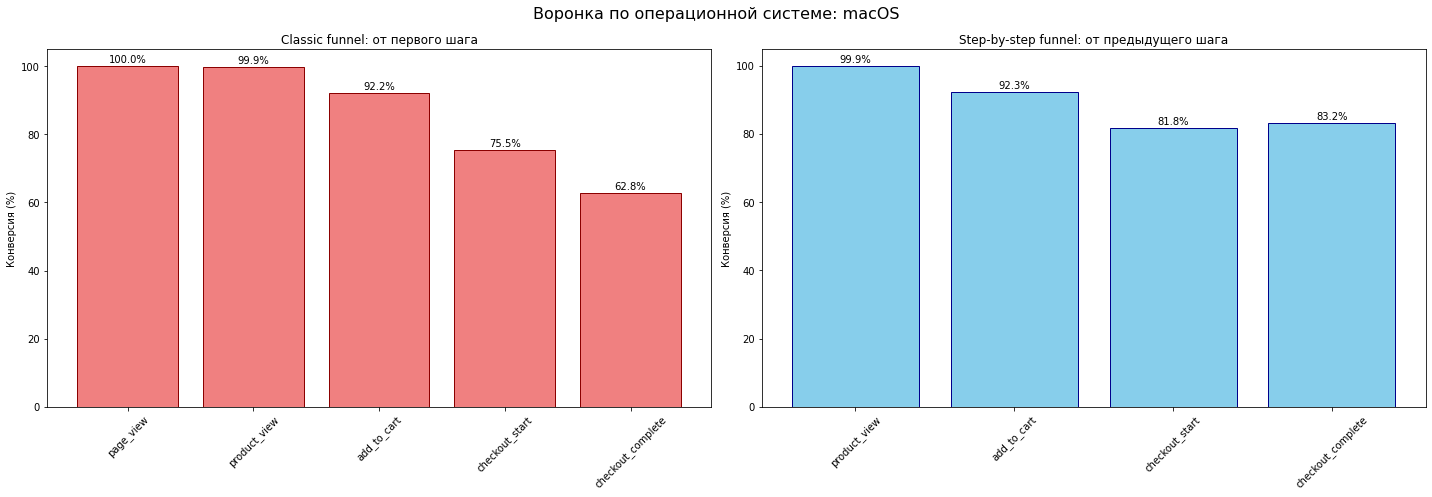

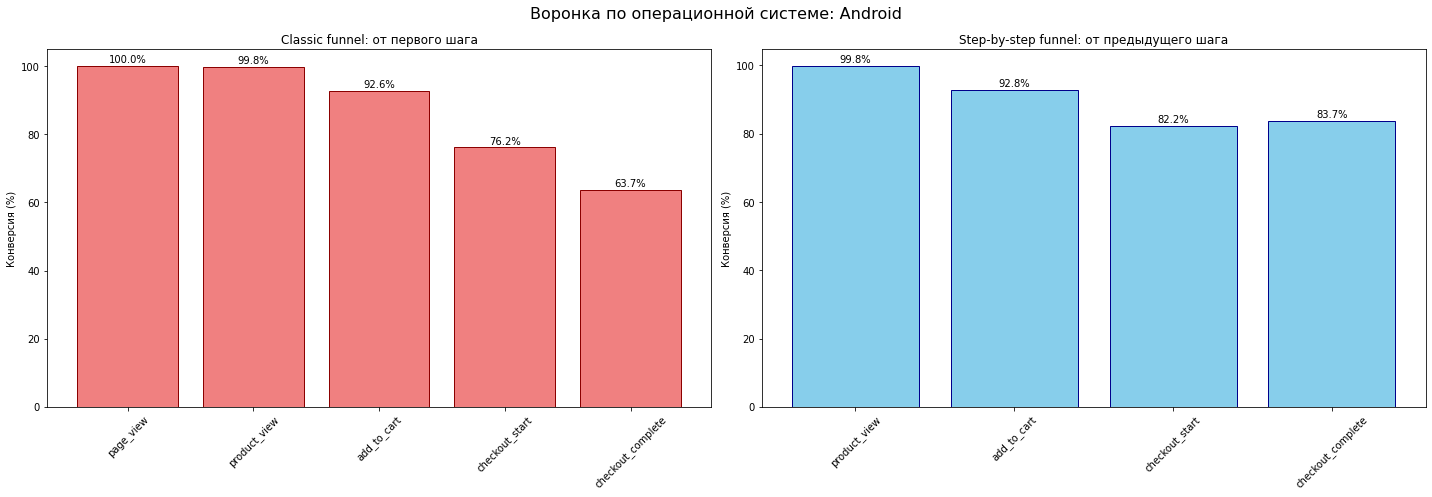

In [108]:
for os_name in unique_os:
    os_events = events[events['os'] == os_name]

    event_steps = (
        os_events[os_events['event_type'].isin(funnel_sequence)]
        .groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_sequence)
        .reset_index()
        .rename(columns={'user_id': 'users_n'})
    )

    # конверсии
    event_steps['conversion_from_first_step_%'] = (
        event_steps['users_n'] / event_steps['users_n'].iloc[0] * 100
    )
    event_steps['conversion_from_previous_step_%'] = (
        event_steps['users_n'] / event_steps['users_n'].shift(1) * 100
    )

    # визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle(f"Воронка по операционной системе: {os_name}", fontsize=16)

    # Классическая воронка:
    ax1.bar(
        event_steps['event_type'],
        event_steps['conversion_from_first_step_%'],
        color='lightcoral',
        edgecolor='darkred'
    )
    ax1.set_title("Classic funnel: от первого шага")
    ax1.set_ylabel("Конверсия (%)")
    ax1.tick_params(axis='x', rotation=45)

    for idx, val in enumerate(event_steps['conversion_from_first_step_%']):
        if np.isfinite(val):
            ax1.text(idx, val + 1, f"{val:.1f}%", ha='center')

    # Пошаговая воронка (step-by-step):
    ax2.bar(
        event_steps['event_type'],
        event_steps['conversion_from_previous_step_%'],
        color='skyblue',
        edgecolor='darkblue'
    )
    ax2.set_title("Step-by-step funnel: от предыдущего шага")
    ax2.set_ylabel("Конверсия (%)")
    ax2.tick_params(axis='x', rotation=45)

    for idx, val in enumerate(event_steps['conversion_from_previous_step_%']):
        if np.isfinite(val):
            ax2.text(idx, val + 1, f"{val:.1f}%", ha='center')

    plt.tight_layout()
    plt.show()

*Аналогично, конверсия по воронкам примерно одинаковая, значит тип операционной системы, с которой пользователь заходит в приложение маркетплейса, не влияет на конверсию.*

*Аналогично построим **воронки по каналам привлечения** пользователей маркетплейса:*

In [109]:
unique_channels = users['acq_channel'].unique()
display(f"Уникальные каналы привлечения: {unique_channels}")

"Уникальные каналы привлечения: ['Google Ads' 'Email Marketing' 'Affiliate' 'SEO' 'Social Media' 'TikTok']"

In [110]:
events_channel = events.merge(users[['user_id', 'acq_channel']], on='user_id', how='left')

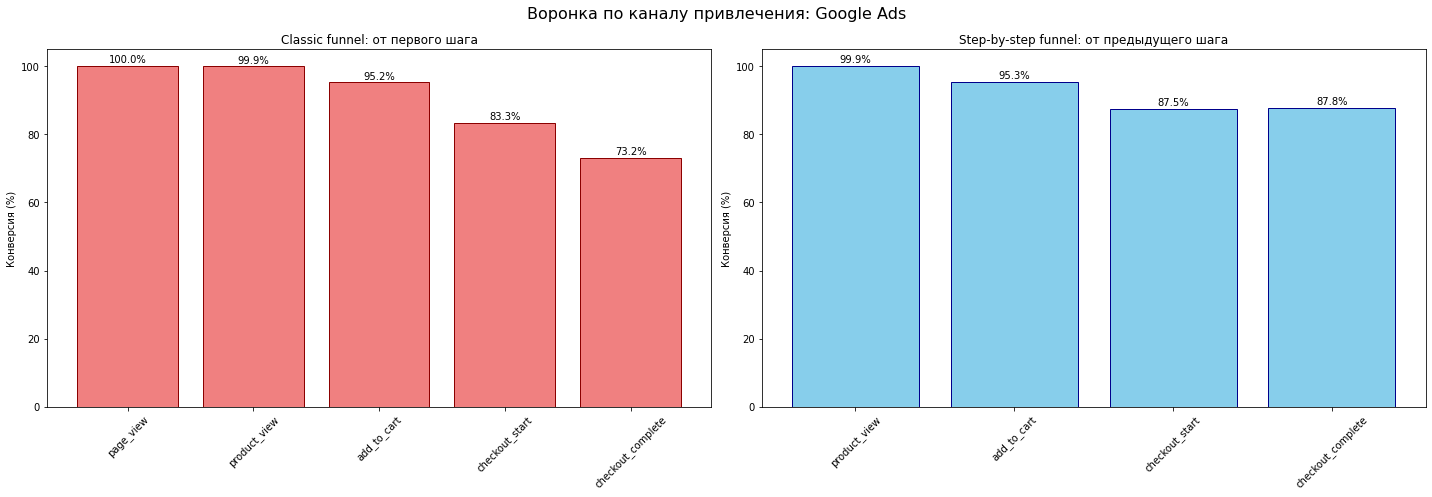

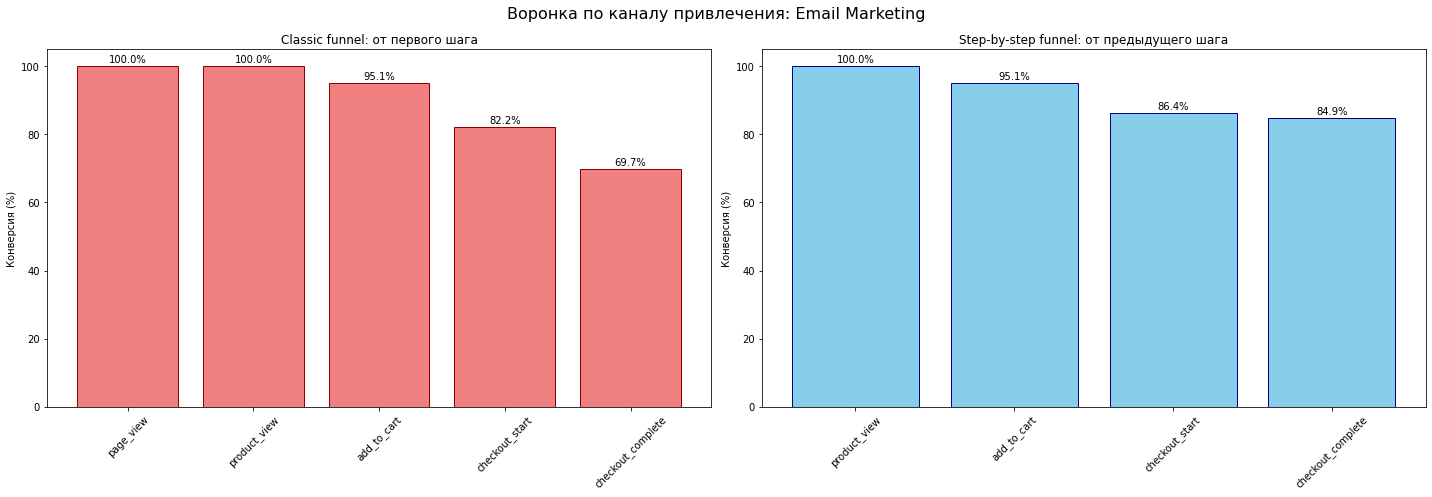

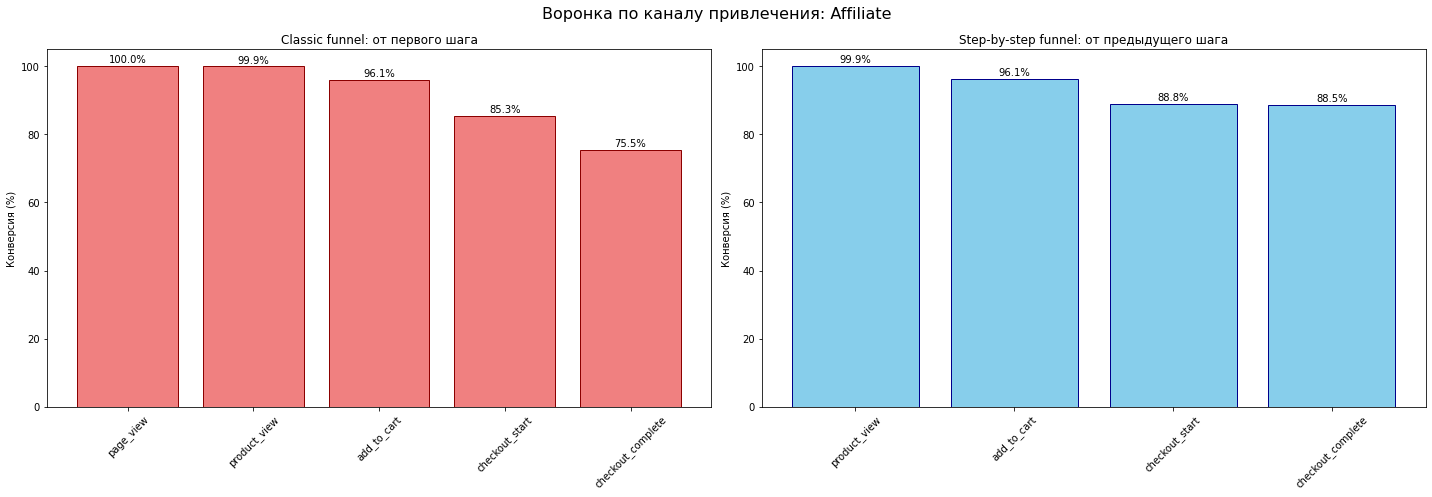

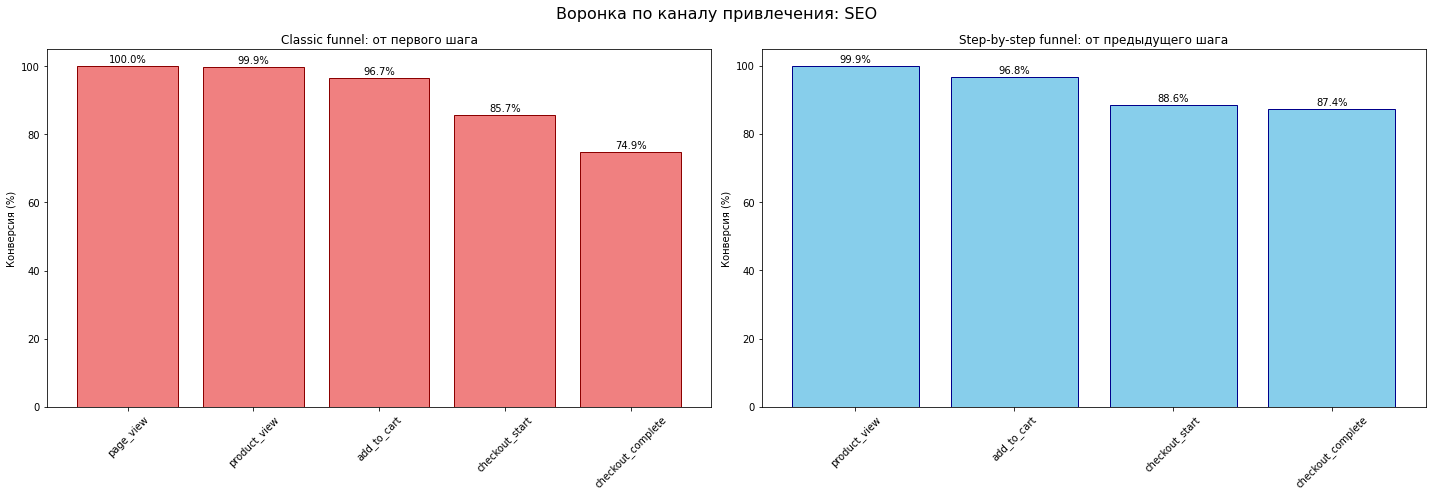

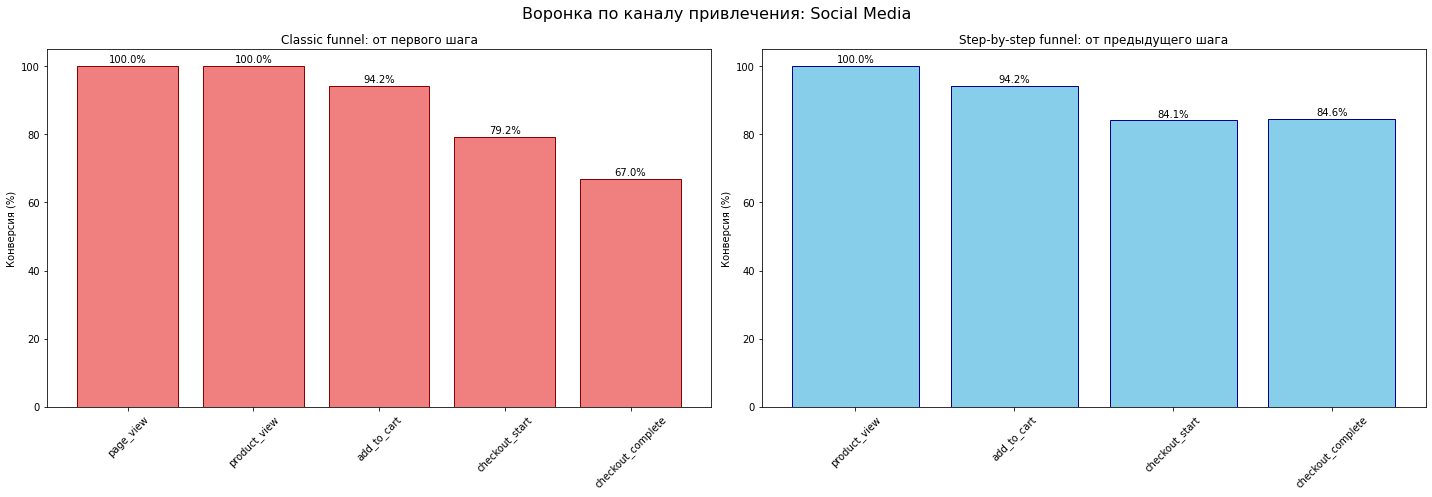

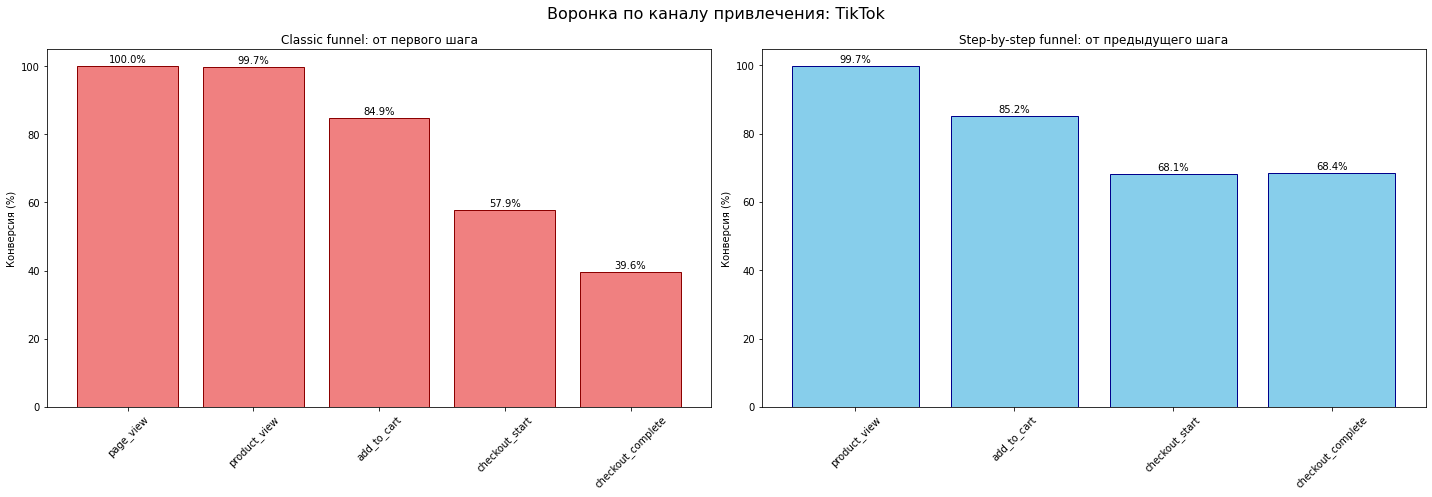

In [111]:
for channel_name in unique_channels:
    channel_events = events_channel[events_channel['acq_channel'] == channel_name]

    event_steps = (
        channel_events[channel_events['event_type'].isin(funnel_sequence)]
        .groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_sequence)
        .reset_index()
        .rename(columns={'user_id': 'users_n'})
    )

    # конверсии
    event_steps['conversion_from_first_step_%'] = (
        event_steps['users_n'] / event_steps['users_n'].iloc[0] * 100
    )
    event_steps['conversion_from_previous_step_%'] = (
        event_steps['users_n'] / event_steps['users_n'].shift(1) * 100
    )

    # визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle(f"Воронка по каналу привлечения: {channel_name}", fontsize=16)

    # Классическая воронка:
    ax1.bar(
        event_steps['event_type'],
        event_steps['conversion_from_first_step_%'],
        color='lightcoral',
        edgecolor='darkred'
    )
    ax1.set_title("Classic funnel: от первого шага")
    ax1.set_ylabel("Конверсия (%)")
    ax1.tick_params(axis='x', rotation=45)

    for idx, val in enumerate(event_steps['conversion_from_first_step_%']):
        if np.isfinite(val):
            ax1.text(idx, val + 1, f"{val:.1f}%", ha='center')

    # Пошаговая воронка (step-by-step):
    ax2.bar(
        event_steps['event_type'],
        event_steps['conversion_from_previous_step_%'],
        color='skyblue',
        edgecolor='darkblue'
    )
    ax2.set_title("Step-by-step funnel: от предыдущего шага")
    ax2.set_ylabel("Конверсия (%)")
    ax2.tick_params(axis='x', rotation=45)

    for idx, val in enumerate(event_steps['conversion_from_previous_step_%']):
        if np.isfinite(val):
            ax2.text(idx, val + 1, f"{val:.1f}%", ha='center')

    plt.tight_layout()
    plt.show()

*Явные проблемы с оформлением заказа происходят у пользователей, которые пришли с канала TikTok. До этапа начала оформления заказа доходит только 57.9% пользователей, а до завершения оформления заказа всего 39.6%. При этом Пользователи активно переходят к товару и добавляют в корзину.*

**Рассчитаем активных пользователей по типу операционной системы, чтобы выяснить, пользователи какой ОС приносят больше прибыли:**

*Берём OS из events (оставляем уникальные пары user_id - os):*

In [112]:
user_os = events[['user_id', 'os']].drop_duplicates()

*Считаем активных пользователей по типу операционной системы:*

In [113]:
active_users_os = (user_os.groupby('os')['user_id'].nunique().rename('active_users'))

*Добавляем тип ОС к заказам:*

In [114]:
orders_os = orders.merge(user_os, on='user_id', how='left')

*Добавляем revenue (выручку маркетплейса - комиссия 5%):*

In [115]:
orders_os['revenue'] = orders_os['total_price'] * 0.05

*Считаем платящих пользователей по типу ОС:*

In [116]:
paying_users_os = (orders_os.groupby('os')['user_id'].nunique().rename('paying_users'))

*Считаем выручку маркетплейса по типу ОС:*

In [117]:
revenue_os = (orders_os.groupby('os')['revenue'].sum().rename('revenue'))

*Собираем всё вместе:*

In [118]:
os_metrics = pd.concat([active_users_os, paying_users_os, revenue_os], axis=1)

*Считаем ARPU:*

In [119]:
os_metrics['ARPU'] = os_metrics['revenue'] / os_metrics['active_users'].replace(0, np.nan)
display(os_metrics)

,active_users,paying_users,revenue,ARPU
os,,,,
Android,5523,1845,5069056.18,917.81
Windows,5594,1837,4686727.49,837.81
iOS,5603,1816,5214976.92,930.75
macOS,5418,1800,5050384.76,932.15


*Построим график, на котором отобразим количество активных и платящих пользователей (столбцы) и ARPU (красная линия):*

In [120]:
os_metrics_plot = os_metrics.sort_values('active_users', ascending=False)
x = np.arange(len(os_metrics_plot))
width = 0.35 

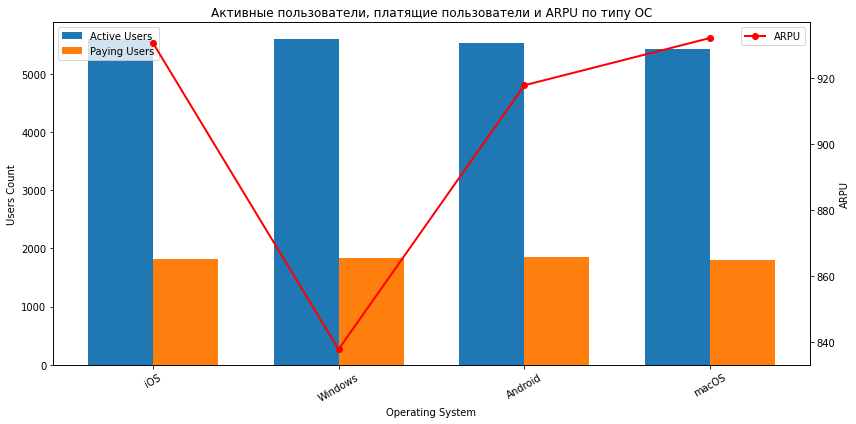

In [121]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Левый Y: столбцы Active & Paying users ---
ax1.bar(x - width/2, os_metrics_plot['active_users'], width, label='Active Users')
ax1.bar(x + width/2, os_metrics_plot['paying_users'], width, label='Paying Users')

ax1.set_xlabel('Operating System')
ax1.set_ylabel('Users Count')
ax1.set_xticks(x)
ax1.set_xticklabels(os_metrics_plot.index, rotation=30)
ax1.legend(loc='upper left')

# --- Правый Y: красная линия ARPU ---
ax2 = ax1.twinx()
ax2.plot(x, os_metrics_plot['ARPU'], marker='o', linewidth=2, color='red', label='ARPU')
ax2.set_ylabel('ARPU')
ax2.legend(loc='upper right')

plt.title('Активные пользователи, платящие пользователи и ARPU по типу ОС')
plt.tight_layout()
plt.show()


*Самые прибыльные платформы по качеству аудитории: macOS и iOS, которые показывают высокий ARPU. Чуть ниже ARPU у пользователей платформы Android и самая слабая платформа по монетизации: Windows (чуть более низкий ARPU при высокой активности). Стоит усилить кампании на iOS/macOS — там самая ценная аудитория.*

*Проанализируем конверсию в покупку по типу устройства:*

In [122]:
events_dev = events[['user_id', 'device']].drop_duplicates()

*Активные пользователи по типу устройства:*

In [123]:
active_users_dev = (events_dev.groupby('device')['user_id'].nunique().rename('active_users'))

*Платящие пользователи по типу устройства (присоединим таблицу `orders`):*

In [124]:
orders_dev = orders.merge(users[['user_id']], on='user_id', how='left').merge(
    events[['user_id', 'device']].drop_duplicates(), on='user_id', how='left')

In [125]:
paying_users_dev = (orders_dev.groupby('device')['user_id'].nunique().rename('paying_users'))

*Собираем все вместе:*

In [126]:
device_metrics = pd.concat([active_users_dev, paying_users_dev], axis=1).fillna(0)

In [127]:
device_metrics['conversion_rate'] = (device_metrics['paying_users'] / device_metrics['active_users'])
device_metrics = device_metrics.reset_index()
device_metrics = device_metrics.sort_values('conversion_rate', ascending=False)
display(device_metrics)

,device,active_users,paying_users,conversion_rate
1,mobile,7431,2493,0.34
2,tablet,7260,2377,0.33
0,desktop,7447,2428,0.33


*Конверсия в заказ по всем типам устройств приблизительно одинаковая. В мобильной версии приложения она чуть выше (34 % против 33% по другим типам устройств, но это не критичная разница).*

**Общий вывод** - *ни тип устройства, ни тип операционной системы не влияют на конверсию в заказ, а путь пользователя от открытия страницы приложения до оформления заказа приблизительно одинаковый.*

**Перейдем к анализу данных в разрезе регионов.**

*Проанализиуем активных пользователей и ARPU по регионам:*

*Привязываем регионы к событиям:*

In [128]:
events_reg = events.merge(users[['user_id', 'region']], on='user_id', how='left')

*Активные пользователи по регионам:*

In [129]:
active_users_by_region = (events_reg.groupby('region')['user_id'].nunique().rename('active_users'))

*Выручка по регионам (5% комиссии маркетплейса от общей стоимости товара):*

In [130]:
orders_reg = orders.merge(users[['user_id', 'region']], on='user_id', how='left')
orders_reg['revenue'] = orders_reg['total_price'] * 0.05
revenue_by_region = orders_reg.groupby('region')['revenue'].sum()

*Собираем все вместе:*

In [131]:
region_metrics = pd.concat([active_users_by_region, revenue_by_region], axis=1).fillna(0)
region_metrics['ARPU'] = region_metrics['revenue'] / region_metrics['active_users']
region_metrics = region_metrics.reset_index().sort_values('active_users', ascending=False)
display(region_metrics)

,region,active_users,revenue,ARPU
0,Другие регионы,7146,6837361.32,956.81
3,Москва,5433,5410184.15,995.80
8,Санкт-Петербург,3239,3396292.57,1048.56
4,Московская область,1729,1658614.02,959.29
1,Екатеринбург,1019,1143765.90,1122.44
5,Нижний Новгород,833,841422.00,1010.11
6,Новосибирск,817,728729.05,891.96
2,Краснодар,698,728837.63,1044.18
7,Ростов-на-Дону,688,603704.79,877.48


*Построим график, на котором отобразим активных пользователей и ARPU по регионам:*

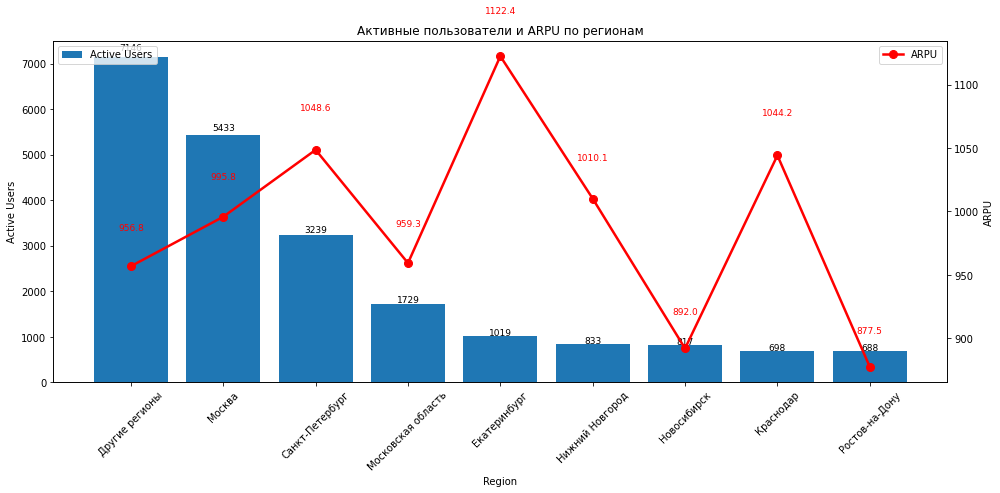

In [132]:
fig, ax1 = plt.subplots(figsize=(14, 7))

x = np.arange(len(region_metrics['region']))

bars = ax1.bar(
    x,
    region_metrics['active_users'],
    label='Active Users'
)

ax1.set_xlabel("Region")
ax1.set_ylabel("Active Users")
ax1.set_xticks(x)
ax1.set_xticklabels(region_metrics['region'], rotation=45)
ax1.set_title("Активные пользователи и ARPU по регионам")
ax1.legend(loc='upper left')

for i, val in enumerate(region_metrics['active_users']):
    ax1.text(i, val + val*0.02, str(val), ha='center', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(
    x,
    region_metrics['ARPU'],
    color='red',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='ARPU'
)

ax2.set_ylabel("ARPU")
ax2.legend(loc='upper right')

for i, val in enumerate(region_metrics['ARPU']):
    ax2.text(i, val + val*0.03, f"{val:.1f}", color='red', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

*Регионы-лидеры по числу активных пользователей:*
- *Другие регионы – 7146*
- *Москва – 5433*
- *Санкт-Петербург – 3239*

*Эти регионы дают основной трафик и пользовательскую активность.*

- *Другие регионы — высокое количество активных пользователей, но ARPU ниже топа (956).*
- *Самая ценная аудитория по ARPU — Екатеринбург (ARPU: 1122), Санкт-Петербург (ARPU: 1048) и Краснодар (ARPU: 1044).*
- *Новосибирск и Ростов-на-Дону — заметный трафик, но слабый ARPU (892 и 877).*

*Здесь возможны точки роста через увеличение конверсии/монетизации.*

*Сбалансированные и перспективные регионы: Москва, Санкт-Петербург, Краснодар - хорошие кандидаты для инвестиций в маркетинг.*

**Проанализируем категории региональных интересов:**

*Привязываем регион к заказам:*

In [133]:
orders_reg_cat = orders.merge(users[['user_id', 'region']], on='user_id', how='left')

*Группируем: количество заказов по наименованию категории и региону:*

In [134]:
category_by_region = (orders_reg_cat.groupby(['region', 'category_name'])['order_id'].nunique()
    .rename('orders_count').reset_index())

*Берём TOP-5 категорий для каждого региона:*

In [135]:
top_categories_by_region = (category_by_region.sort_values(['region', 'orders_count'], ascending=[True, False])
    .groupby('region').head(5))

*Добавляем ранги внутри региона:*

In [136]:
top_categories_by_region['rank'] = top_categories_by_region.groupby('region')['orders_count'].rank(
    method='first', ascending=False).astype(int)

*Построим сводную таблицу для наглядности:*

In [137]:
pivot_categories = top_categories_by_region.pivot(
    index='region',
    columns='rank',
    values='category_name'
).rename_axis(None, axis=1)

In [138]:
pivot_categories.columns = [f"category_{c}" for c in pivot_categories.columns]
display(pivot_categories)

,category_1,category_2,category_3,category_4,category_5
region,,,,,
Другие регионы,Продукты питания,Детская одежда,Книги и канцтовары,Средства для ухода,Женская одежда
Екатеринбург,Продукты питания,Зоотовары,Товары для новорожденных,Товары для кухни,Товары для туризма
Краснодар,Продукты питания,Товары для кухни,Зоотовары,Книги и канцтовары,Обувь женская
Москва,Продукты питания,Аксессуары для гаджетов,Зоотовары,Книги и канцтовары,Женская одежда
Московская область,Продукты питания,Одежда для спорта,Аксессуары для гаджетов,Сумки и аксессуары,Зоотовары
Нижний Новгород,Продукты питания,Обувь мужская,Детская одежда,Сумки и аксессуары,Бытовая техника
Новосибирск,Продукты питания,Детские игрушки,Детская одежда,Косметика и парфюмерия,Обувь женская
Ростов-на-Дону,Продукты питания,Аксессуары для гаджетов,Одежда для спорта,Средства для ухода,Бытовая техника
Санкт-Петербург,Продукты питания,Сумки и аксессуары,Детская одежда,Обувь женская,Зоотовары


*Во всех регионах без исключения категория «Продукты питания» занимает 1 место. Это указывает на универсальный и повседневный характер спроса.*

*Категории типа «Детская одежда», «Игрушки», «Товары для новорожденных» входят в топ-5 практически везде кроме Москвы и МО.
Это указывает на высокую долю семейной аудитории в регионах.*

*Зоотовары также имеют стабильный спрос. В топ-5 сразу в нескольких регионах: Москва, Краснодар, Новосибирск, Московская область имеют устойчивый спрос на товары для животных.*

*Данные выводы важны для таргетинга, рекомендаций, закупок и персонализации каталога.*

**Также стоит посмотреть, какие категории товаров приносят самую большую выручку на пользователя:**

*Считаем выручку по категориям:*

In [139]:
revenue_by_cat = (orders.groupby('category_name')['marketplace_revenue'].sum().rename('revenue'))


*Количество активных пользователей (уникальных покупателей по категории):*

In [140]:
users_by_cat = (orders.groupby('category_name')['user_id'].nunique().rename('active_users'))

*Собираем таблицу:*

In [141]:
cat_metrics = pd.concat([revenue_by_cat, users_by_cat], axis=1)
cat_metrics['ARPU'] = cat_metrics['revenue'] / cat_metrics['active_users']
top5_by_arpu = cat_metrics.sort_values("ARPU", ascending=False).head(5)
display(top5_by_arpu)

,revenue,active_users,ARPU
category_name,,,
Мебель для дома,3580998.22,514,6966.92
Бытовая техника,2248933.06,546,4118.93
Украшения и часы,1718297.10,495,3471.31
Товары для туризма,1137317.79,498,2283.77
Спортивный инвентарь,1165361.15,523,2228.22


*Самый большой доход приносят категории "Мебель для дома" (ARPU: 6967) и "Бытовая техника" (ARPU: 4119). Такие товары относятся к дорогостоящим и имеют широкий охват аудитории. "Украшения и часы" больше относятся к импульсивным покупкам, но также приносят хороший доход (3471 на пользователя). Категории с массовым спросом (спорт, туризм) приносят ниже ARPU, но также обеспечивают широкий охват.*

**Далее посмотрим, какие каналы привлечения приносят большую и платящую аудиторию, а какие - только расходы.**

**Начнем с сравнения CAC и ARPU по каналам привлечения.**

*Для расчета САС по каналам привлечения:*

In [142]:
first_visits_by_ch = first_visits.merge(users[['user_id', 'acq_channel']], on='user_id', how='left')

*Новые пользователи по каналам и месяцам:*

In [143]:
new_users_monthly_by_ch = (first_visits_by_ch.groupby(['month', 'acq_channel'])['user_id']
    .nunique().reset_index().rename(columns={'user_id': 'total_users'}))

*Приводим месяцы расходов:*

In [144]:
campaign_costs['month'] = campaign_costs['spend_month'].dt.to_period('M')

*Суммарные расходы по каналам:*

In [145]:
costs_monthly_by_ch = (campaign_costs.groupby(['month', 'acq_channel'])['budget'].sum().reset_index())

*Соединяем расходы и новых пользователей:*

In [146]:
cac_data_by_ch = costs_monthly_by_ch.merge(new_users_monthly_by_ch, on=['month', 'acq_channel'], how='left')
cac_data_by_ch['total_users'] = cac_data_by_ch['total_users'].replace(0, pd.NA)
cac_data_by_ch['cac'] = cac_data_by_ch['budget'] / cac_data_by_ch['total_users']

*Средний CAC по каналу:*

In [147]:
cac_by_channel = ( cac_data_by_ch.groupby('acq_channel')['cac'].mean().reset_index())

*ARPU по каналам:*

*Cвязываем заказы с каналами:*

In [148]:
orders_ch = orders.merge(users[['user_id', 'acq_channel']], on='user_id', how='left')

*Выручка по каналам:*

In [149]:
rev_by_ch = orders_ch.groupby('acq_channel')['marketplace_revenue'].sum().rename('revenue')

*Активные пользователи по каналам (все зарегистрированные):*

In [150]:
active_by_ch = users.groupby('acq_channel')['user_id'].nunique().rename('active_users')
arpu_by_channel = (rev_by_ch / active_by_ch).reset_index().rename(columns={0: 'ARPU'})
arpu_by_channel.columns = ['acq_channel', 'ARPU']

*Объединяем CAC + ARPU:*

In [151]:
compare_df = cac_by_channel.merge(arpu_by_channel, on='acq_channel', how='left')
compare_df = compare_df.dropna(subset=['cac'])
display(compare_df)

,acq_channel,cac,ARPU
0,Affiliate,312.72,1109.87
2,Email Marketing,250.39,271.87
3,Google Ads,500.51,883.87
4,SEO,187.44,576.67
5,Social Media,373.75,717.94
6,TikTok,435.99,47.35


*Визуализируем:*

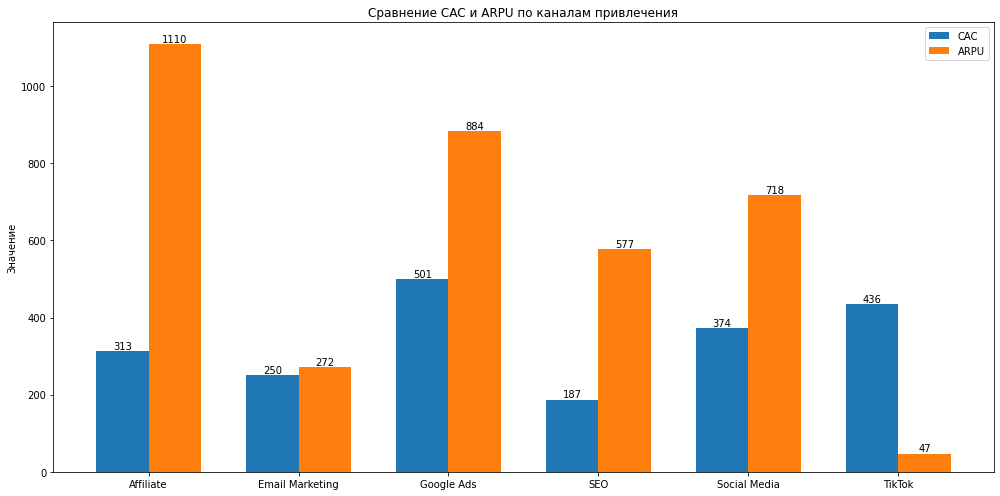

In [152]:
plt.figure(figsize=(14, 7))

x = np.arange(len(compare_df))
width = 0.35

plt.bar(x - width/2, compare_df['cac'], width, label='CAC')
plt.bar(x + width/2, compare_df['ARPU'], width, label='ARPU')

for i, val in enumerate(compare_df['cac']):
    plt.text(i - width/2, val + 5, f"{val:.0f}", ha='center')

for i, val in enumerate(compare_df['ARPU']):
    plt.text(i + width/2, val + 5, f"{val:.0f}", ha='center')

plt.xticks(x, compare_df['acq_channel'])
plt.title("Сравнение CAC и ARPU по каналам привлечения")
plt.ylabel("Значение")
plt.legend()
plt.tight_layout()
plt.show()

*`Affiliate` и `SEO` — самые эффективные каналы, у них достаточно низкий CAC при высоком ARPU.
`Google Ads` и` Social Media` — дорогие, но приносят высокий ARPU — каналы работают, но эффективность средняя относительно стоимости привлечения пользователя.
`Email Marketing` - относительно дорогой канал привлечения, и при этом доход с пользователя едва покрывает расходы на привлечение. Сложно назвать данный канал прибыльным.
`TikTok` — самый слабый канал: высокий CAC при крайне низком ARPU. Канал очень убыточный и стоит от него отказаться, чтобы сократить ненужные расходы.*

**Проанализируем метрики по каналам привлечения пользователей:**

In [153]:
events_ch = events.merge(users[['user_id', 'acq_channel']], on='user_id', how='left')
orders_ch = orders.merge(users[['user_id', 'acq_channel']], on='user_id', how='left')

In [154]:
orders_ch['revenue'] = orders_ch['total_price'] * 0.05

*Активные пользователи:*

In [155]:
active_users_ch = (events_ch.groupby('acq_channel')['user_id'].nunique().rename('active_users'))

*Платящие пользователи:*

In [156]:
paying_users_ch = (orders_ch.groupby('acq_channel')['user_id'].nunique().rename('paying_users'))

*Выручка маркетплейса по каналам привлечения:*

In [157]:
revenue_ch = (orders_ch.groupby('acq_channel')['revenue'].sum().rename('revenue'))

*Количество заказов:*

In [158]:
orders_count_ch = (orders_ch.groupby('acq_channel')['order_id'].nunique().rename('orders_count'))

*Считаем ARPU по каналам привлечения:*

In [159]:
channel_metrics = pd.concat([active_users_ch, paying_users_ch, revenue_ch], axis=1).fillna(0)

In [160]:
channel_metrics['ARPU'] = channel_metrics['revenue'] / channel_metrics['active_users']

In [161]:
channel_metrics = channel_metrics.reset_index()
channel_metrics = channel_metrics[['acq_channel', 'active_users', 'paying_users', 'ARPU']]
channel_metrics = channel_metrics.sort_values('ARPU', ascending=False)
display(channel_metrics)

,acq_channel,active_users,paying_users,ARPU
0,Affiliate,3690,2338,1825.42
2,Google Ads,5612,3187,1467.70
4,Social Media,2198,1211,1364.99
3,SEO,2167,874,881.37
1,Email Marketing,1272,325,436.87
5,TikTok,6663,719,136.64


*Построим график, на котором отобразим количество активных и платящих пользователей по каналам привлечения (столбцы) и ARPU (красная линия):*

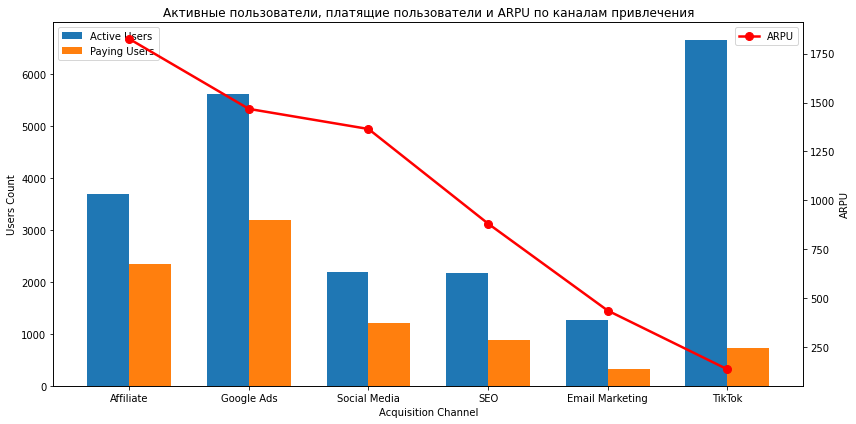

In [162]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(channel_metrics['acq_channel']))
width = 0.35

# --- Левый Y: active & paying users (столбцы) ---
ax1.bar(x - width/2, channel_metrics['active_users'], width, label='Active Users')
ax1.bar(x + width/2, channel_metrics['paying_users'], width, label='Paying Users')

ax1.set_xlabel('Acquisition Channel')
ax1.set_ylabel('Users Count')
ax1.set_xticks(x)
ax1.set_xticklabels(channel_metrics['acq_channel'])
ax1.legend(loc='upper left')

# --- Правый Y: ARPU линия (красная) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    channel_metrics['ARPU'],
    color='red',
    marker='o',
    markersize=8,
    linewidth=2.5,
    label='ARPU'
)
ax2.set_ylabel('ARPU')
ax2.legend(loc='upper right')

plt.title('Активные пользователи, платящие пользователи и ARPU по каналам привлечения')
plt.tight_layout()
plt.show()

*`Affiliate` — лучший канал: высокий ARPU (1825) и много платящих. `Google Ads` — большой объём и высокий ARPU (1468). `TikTok` — больше всего активных, но почти не монетизируется (ARPU 137).`SEO` — средний объём, слабая монетизация (ARPU 881).*

*`Affiliate` и `Google Ads` — качественные каналы; `TikTok` приводит много трафика, но почти не монетизируется.*

*А теперь посмотрим на затраты на привлечение по каналам и выясним, оправданы ли затраты на `TikTok`:*

In [163]:
acquired_users = users.groupby('acq_channel')['user_id'].nunique().rename('acquired_users')
channel_budget = campaign_costs.groupby('acq_channel')['budget'].sum().rename('budget')
cac = (channel_budget / acquired_users).rename('CAC')

In [164]:
channel_metrics = pd.concat([
    active_users_ch,
    paying_users_ch,
    revenue_ch,
    acquired_users,
    cac
], axis=1).fillna(0)

In [165]:
channel_metrics['ARPU'] = channel_metrics['revenue'] / channel_metrics['active_users']
channel_metrics = channel_metrics.reset_index()

In [166]:
channel_metrics = channel_metrics[['acq_channel', 'active_users', 'paying_users', 'CAC']]
channel_metrics = channel_metrics[channel_metrics['acq_channel'] != 'Direct']
channel_metrics = channel_metrics.sort_values('CAC', ascending=False)

display(channel_metrics)

,acq_channel,active_users,paying_users,CAC
5,TikTok,6663.00,719.00,504.23
2,Google Ads,5612.00,3187.00,500.43
4,Social Media,2198.00,1211.00,394.21
0,Affiliate,3690.00,2338.00,331.58
1,Email Marketing,1272.00,325.00,263.38
3,SEO,2167.00,874.00,199.73


*Построим график, на котором отобразим количество активных и платящих пользователей по каналам привлечения (столбцы) и CAC (красная линия):*

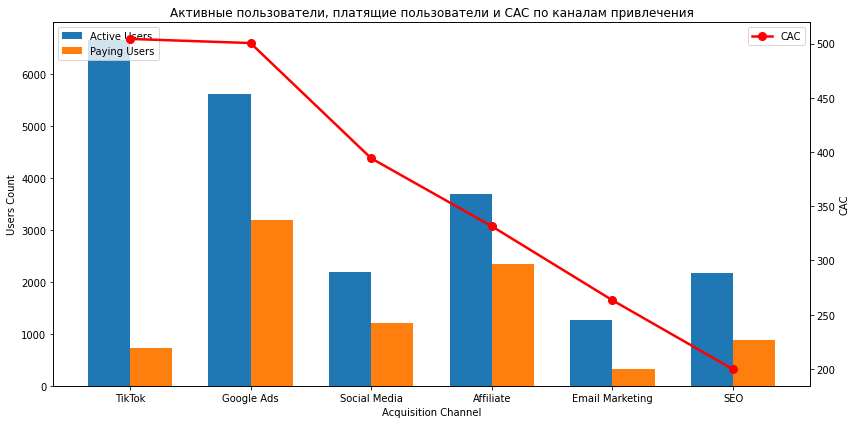

In [167]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(channel_metrics['acq_channel']))
width = 0.35

# --- Левый Y: active & paying users (столбцы) ---
ax1.bar(x - width/2, channel_metrics['active_users'], width, label='Active Users')
ax1.bar(x + width/2, channel_metrics['paying_users'], width, label='Paying Users')

ax1.set_xlabel('Acquisition Channel')
ax1.set_ylabel('Users Count')
ax1.set_xticks(x)
ax1.set_xticklabels(channel_metrics['acq_channel'])
ax1.legend(loc='upper left')

# --- Правый Y: ARPU линия (красная) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    channel_metrics['CAC'],
    color='red',
    marker='o',
    markersize=8,
    linewidth=2.5,
    label='CAC'
)
ax2.set_ylabel('CAC')
ax2.legend(loc='upper right')

plt.title('Активные пользователи, платящие пользователи и CAC по каналам привлечения')
plt.tight_layout()
plt.show()

*`TikTok` привлекает большой объём трафика, но делает это дороже всех, и доля платящих пользователей не компенсирует высокий CAC.*

**ВЫВОДЫ с учетом воронки**

**Общий вывод** - *канал `TikTok` хоть и приводит в сервис наибольшее количество пользователей, но они не становятся платящими и не приносят выручку маркетплейсу. Затраты на него явно неоправданы и дальнейшие крупные вложения могут привести к убыточности бизнеса.*

**Далее проведем анализ по сегментам покупателей.**

*Для начала выясним, какие сегменты покупателей присутствуют в данных:*

In [168]:
unique_segments = users['buyer_segment'].unique()
display(f"Уникальные сегменты покупателей: {unique_segments }")

"Уникальные сегменты покупателей: ['regular' 'rare' 'one_time' 'medium']"

*Покупатели делятся на четыре сегмента:*
- *`regular` - постоянные покупатели, совершают покупки регулярно и демонстрируют наивысший уровень активности*
- *`medium` - среднеактивные покупатели, делают заказы периодически, но не так часто, как regular*
- *`rare` - редкие покупатели, совершают покупки нерегулярно и с большими интервалами*
- *`one_time` - одноразовые покупатели, совершили единственную покупку и больше не возвращались.*

**Проанализируем ARPU по сегментам покупателей:**

*Привязываем сегмент к заказам:*

In [169]:
orders_seg = orders.merge(users[['user_id', 'buyer_segment']], on='user_id', how='left')

*Суммарная выручка маркетплейса по сегментам:*

In [170]:
revenue_by_seg = (orders_seg.groupby('buyer_segment')['marketplace_revenue'].sum().rename('revenue'))

*Количество активных пользователей по сегменту:*

In [171]:
active_users_seg = (users.groupby('buyer_segment')['user_id'].nunique().rename('active_users'))

*Количество платящих пользователей по сегменту:*

In [172]:
paying_users_seg = (orders_seg.groupby('buyer_segment')['user_id'].nunique().rename('paying_users'))

*Собираем все вместе:*

In [173]:
seg_metrics = pd.concat([revenue_by_seg, active_users_seg, paying_users_seg], axis=1)
seg_metrics['ARPU'] = seg_metrics['revenue'] / seg_metrics['active_users']
display(seg_metrics.sort_values('ARPU', ascending=False))

,revenue,active_users,paying_users,ARPU
buyer_segment,,,,
regular,14890442.21,7773,3716,1915.66
medium,5190507.73,16421,3692,316.09
rare,1046909.80,13256,988,78.98
one_time,221051.71,6701,258,32.99


*Построим график, на котором отобразим количество активных и платящих пользователей по сегментам покупателей (столбцы) и ARPU (красная линия):*

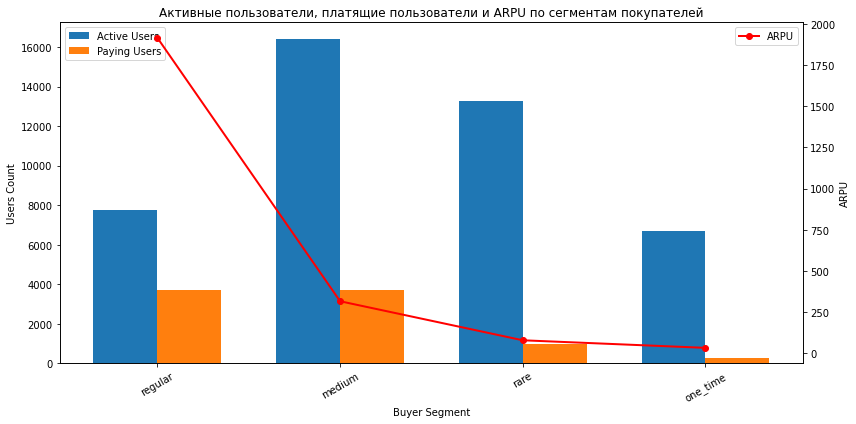

In [174]:
plot_df = seg_metrics.sort_values('ARPU', ascending=False).reset_index()

x = np.arange(len(plot_df['buyer_segment']))  # позиции X
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Столбцы: Active vs Paying ---
ax1.bar(x - width/2, plot_df['active_users'], width, label='Active Users')
ax1.bar(x + width/2, plot_df['paying_users'], width, label='Paying Users')

ax1.set_xlabel('Buyer Segment')
ax1.set_ylabel('Users Count')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df['buyer_segment'], rotation=30)
ax1.legend(loc='upper left')

# --- Линия ARPU ---
ax2 = ax1.twinx()
ax2.plot(
    x, 
    plot_df['ARPU'], 
    marker='o', 
    linewidth=2, 
    color='red', 
    label='ARPU'
)
ax2.set_ylabel('ARPU')
ax2.legend(loc='upper right')

plt.title('Активные пользователи, платящие пользователи и ARPU по сегментам покупателей')
plt.tight_layout()
plt.show()

*`Regular` — ключевой и самый прибыльный сегмент. Самый высокий ARPU - 1915. При этом пользователей меньше, чем в medium/rare, но они приносят 70% всей выручки. Это основа бизнеса, сегмент с высокой лояльностью и регулярными покупками.*

*`Medium` — самый большой сегмент по размеру (16.4k активных). ARPU всего 316 — низкая монетизация для такого объёма. Потенциал: они активны, но мало покупают → стоит работать над конверсией и частотой.*

*`Rare` — очень низкое вовлечение в покупки. Много активных пользователей, но мало платящих. ARPU всего 79, что означает, что пользователи почти не совершают покупки. Сегмент с большим потенциалом, если повысить мотивацию к первой/следующей покупке.*

*`One-time` — почти не монетизируются. Очень низкий ARPU (33). 6700 активных и всего 258 платящих — почти нулевая LTV. Это пользователи, которые приходят и пропадают. Их надо возвращать спецпредложениями.*

**Проанализируем распределение пользователей по сегментам в каналах привлечения**

*Привязываем сегмент к пользователю и его каналу:*

In [175]:
users_seg = users[['user_id', 'acq_channel', 'buyer_segment']]

*Считаем количество пользователей каждого сегмента в каждом канале:*

In [176]:
seg_by_channel = (users_seg.groupby(['acq_channel', 'buyer_segment'])['user_id'].nunique().rename("users_count").reset_index())

*Считаем общий объём пользователей в каждом канале:*

In [177]:
channel_totals = (seg_by_channel.groupby('acq_channel')['users_count'].sum().rename("total_users").reset_index())

*Добавляем total к основной таблице:*

In [178]:
seg_by_channel = seg_by_channel.merge(channel_totals, on='acq_channel', how='left')

*Расчёт процента сегмента внутри канала:*

In [179]:
seg_by_channel['percent'] = (seg_by_channel['users_count'] / seg_by_channel['total_users']) * 100

*Создадим сводную таблицу для наглядности результатов:*

In [180]:
pivot_percent = seg_by_channel.pivot_table(
    index='acq_channel',
    columns='buyer_segment',
    values='percent',
    fill_value=0
)

display(pivot_percent)

buyer_segment,medium,one_time,rare,regular
acq_channel,,,,
Affiliate,37.19,15.65,29.59,17.56
Email Marketing,36.20,14.43,30.58,18.79
Google Ads,37.59,15.43,29.65,17.33
SEO,38.10,13.77,30.16,17.96
Social Media,36.99,15.17,30.73,17.11
TikTok,36.99,15.23,30.11,17.67


*Каналы привлечения не влияют существенно на распределение типов покупателей — структура сегментов почти одинаковая в каждом канале. Это означает, что качество трафика по сегментам равномерное.*

**В конце проведем RFM сегментацию пользователей (давность последнего заказа, частота заказов и сумма трат).**

*Для проведения RFM сегментации возьмем данные из таблицы `orders`:*

In [181]:
df_orders = orders.copy()
df_orders['order_date'] = pd.to_datetime(df_orders['order_date']).dt.normalize()

*В качестве даты анализа установим последний день 2024 года, чтобы посмотреть итоговые годовые значения:*

In [182]:
analysis_date = pd.to_datetime('2024-12-31')

*Группируем данные для каждого пользователя и рассчитываем данные для RFM-анализа:*

In [183]:
# Recency — дни с последней покупки
recency_df = df_orders.groupby('user_id')['order_date'].max().reset_index()
recency_df['recency'] = (analysis_date - recency_df['order_date']).dt.days

# Frequency — количество заказов
frequency_df = df_orders.groupby('user_id')['order_id'].nunique().reset_index()
frequency_df = frequency_df.rename(columns={'order_id': 'frequency'})

# Monetary — суммарная выручка
monetary_df = df_orders.groupby('user_id')['marketplace_revenue'].sum().reset_index()
monetary_df = monetary_df.rename(columns={'marketplace_revenue': 'monetary_value'})

*Визуализируем Recency:*

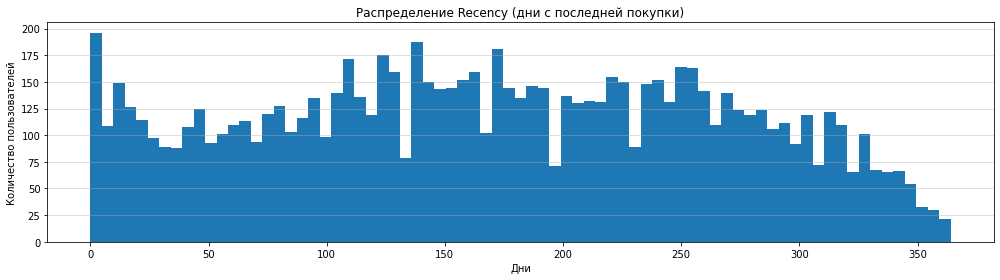

In [184]:
plt.figure(figsize=(14,4))
plt.hist(recency_df['recency'], bins=75)
plt.title('Распределение Recency (дни с последней покупки)')
plt.xlabel('Дни')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

*Есть выраженный пик у значения 0–10 дней. Это значит, что заметная часть пользователей делала покупку совсем недавно. Однако, достаточно большая часть пользователей совершила покупку в течение последних 130-180 дней, а также есть крупный сегмент пользователей, не покупавших 220-250 дней — для таких пользователей можно предложить персональные предложения на последующие покупки.*

*Визуализируем Frequency:*

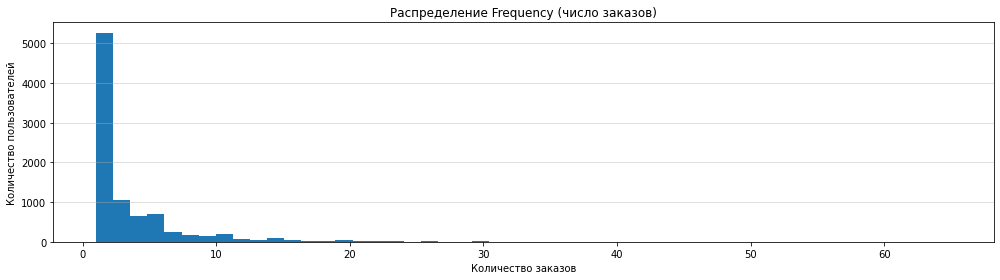

In [185]:
plt.figure(figsize=(14,4))
plt.hist(frequency_df['frequency'], bins=50)
plt.title('Распределение Frequency (число заказов)')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

*Гистограмма метрики Frequency показывает смещение влево. Это означает, что большая часть пользователей совершила заказ только 1 раз.*

*Визуализируем Monetary:*

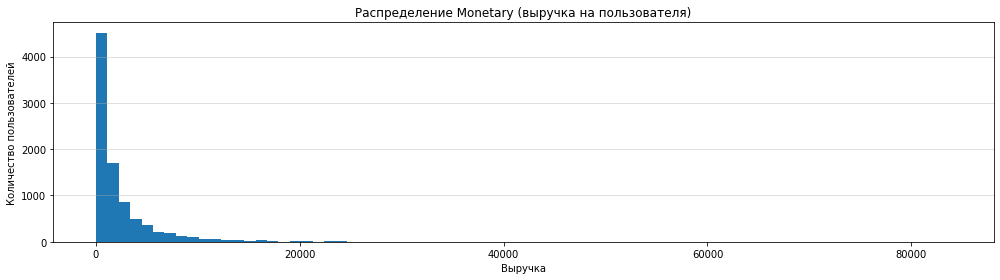

In [186]:
plt.figure(figsize=(14,4))
plt.hist(monetary_df['monetary_value'], bins=75)
plt.title('Распределение Monetary (выручка на пользователя)')
plt.xlabel('Выручка')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

*Распределение метрики Monetary смещено в левую сторону — резко преобладают пользователи с недорогими заказами (до 1 000).*

*Выделим **RFM-сегменты** и изучите распределение пользователей по ним.*
    
*Применим следующие подходы к выделению RFM сегментов:*
- **Recency** — р*азделим на три равные группы.*
- **Frequency** —  *разделим на три группы:*
    - *пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);*
    - *пользователи с 2 заказами (F-сегмент со средним количеством заказов);*
    - *пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).*
- **Monetary** — *разделим на три группы по 33-му и 66-му перцентилям.*
    
*После этого посчитаем количество и долю заказов в каждом сегменте:*

In [187]:
orders_rfm = recency_df.merge(frequency_df, on='user_id')
orders_rfm = orders_rfm.merge(monetary_df, on='user_id')

*Для распределения пользователей для метрики **Recency** разделим пользователей на три равные группы по количеству дней с момента последнего заказа:*

In [188]:
orders_rfm['r'] = pd.cut(orders_rfm['recency'], bins=3, labels=[3,2,1])

*Для метрики **Frequency** разделим пользователей на три сегмента по количеству заказов (пользователи с 1 заказом, пользователи с 2 заказами, пользователи с 3 и более заказами):*

In [189]:
orders_rfm['f'] = pd.cut(orders_rfm['frequency'], bins=[0,1,2, orders_rfm['frequency'].max()+1],
    labels=[1,2,3], include_lowest=True)

*Для метрики **Monetary** разделим пользователей на три группы по 33-му и 66-му перцентилям:*

In [190]:
orders_rfm['m'] = pd.qcut(orders_rfm['monetary_value'], q=3, labels=[1,2,3])

*Находим групповой RFM-индекс:*

In [191]:
orders_rfm[['r','f','m']] = orders_rfm[['r','f','m']].astype(str)
orders_rfm['rfm_group'] = orders_rfm['r'] + orders_rfm['f'] + orders_rfm['m']

*Группируем данные по сегментам и считаем их размер:*

In [192]:
rfm_group = (orders_rfm.groupby('rfm_group')['user_id'].nunique().reset_index()
    .rename(columns={'user_id':'total_users'}))

*Считаем долю пользователей в каждом сегменте:*

In [193]:
rfm_group['user_share'] = rfm_group['total_users'] / rfm_group['total_users'].sum()
rfm_group = rfm_group.sort_values('total_users', ascending=False)
display(rfm_group)

,rfm_group,total_users,user_share
17,233,1021,0.11
26,333,887,0.10
9,211,870,0.10
0,111,740,0.08
18,311,701,0.08
8,133,523,0.06
16,232,422,0.05
10,212,375,0.04
25,332,372,0.04
13,222,351,0.04


*Ключевая ценность бизнеса сосредоточена в сегментах 233 и 333 (заходят часто + много тратят). Такие сегменты в топе и это хорошо. Значит пользователи достаточно лояльны и платежеспособны,и их нужно удержать. Сегменты 211, 111, 311 — это массовая база, они же - недавние клиенты. Видно, что они тратят мало и покупают немного. Стоит поработать с такими клиентами, чтобы увеличить частоту заказов и их средний чек.*

## Выводы по этапу 4

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

**Аналитическая записка по итогам исследования данных маркетплейса.**

**1. Общий анализ воронки и пользовательского поведения:**

*Анализ пользовательской воронки показал, что 62,9 % пользователей, зашедших в приложение, доходят до оформления заказа. Воронка равномерная, без резких провалов на ключевых этапах.*
*Основной «просадкой» является переход от «добавления в корзину» к «началу оформления заказа» — только 82,2 % пользователей продолжают путь. На финальном шаге конверсия слегка возрастает за счёт пользователей, которые оформляют заказ сразу после добавления в корзину.*

*Важно также отметить, что событие `checkout_complete` фиксирует завершение оформления, но не гарантирует реальной покупки. Необходимо добавить событие `purchase` для корректной оценки конечной конверсии.*

**2. Анализ в разрезе устройств и операционных систем:**

*Разница конверсии между устройствами и операционными системами минимальная — поведение пользователей при прохождении воронки практически одинаково.*

*Тем не менее по монетизации аудитории есть различия:*

- *iOS и macOS — самые прибыльные платформы (высокий ARPU - выручка маркетплейса на одного пользователя).*

- *Android — чуть меньший ARPU.*

- *Windows — высокая активность, как и у остальных операционных систем, но самый низкий ARPU среди остальных ОС.*

*Это говорит о том, что качество аудитории iOS/macOS выше, и эти платформы подходят для масштабирования рекламных кампаний.*

**3. Анализ в разрезе регионов:**

*Трафик концентрируется в 3 ключевых регионах:*

- *Другие регионы – 7146 активных пользователей,*

- *Москва – 5433,*

- *Санкт-Петербург – 3239.*

*По ARPU: наиболее прибыльны Екатеринбург, Санкт-Петербург, Краснодар — высокая платёжеспособность и регулярные заказы.*

*Новосибирск и Ростов-на-Дону — большой трафик, но низкая доходность.*

*Регионы, в которые стоит инвестировать: Москва, Санкт-Петербург, Краснодар, Екатеринбург.*

**4. Анализ товарных категорий:**

*У всех регионов лидер — **Продукты питания**. Это универсальный массовый спрос — категория, которая должна оставаться доступной и хорошо представленной в каталоге.*

*Повсеместно высок спрос на:*

- *товары для детей,*

- *игрушки,*

- *товары для новорожденных,*

- *зоотовары.*

*По ARPU лидируют дорогие сегменты:*

- *Мебель для дома (Самый высокий ARPU 6967),*

- *Бытовая техника (ARPU 4119),*

- *Украшения и часы (ARPU 3471).*

*Массовые категории дают большой объём, но меньший ARPU. Это разные типы спроса и нужно балансировать ассортимент: дорогие товары дают прибыль, массовые — охват.*

**5. Анализ в разрезе каналов привлечения:**

*Самые эффективные каналы: Affiliate и SEO. Низкий CAC + высокий ARPU делают эти каналы прибыльными.*

*Средние: Google Ads, Social Media — дорогие, но рабочие.*

*Неприбыльные: Email Marketing (расход на привлечение приблизительно равен доходу на пользователя, что явно не принесет большой прибыли маркетплейсу) и **TikTok** — самый высокий CAC и самый низкий ARPU, что делает данный канал привлечения крайне убыточным.*

*TikTok приводит много активных пользователей, но почти не конвертирует в покупки. Канал лучше отключить или переработать стратегию.*

*Распределение по сегментам покупателей в каналах при этом однородное: каналы приводят пользователей примерно одинакового поведенческого типа: различия в эффективности каналов обусловлены не качеством, а стоимостью.*

**6. Анализ поведения покупателей:**

*Покупатели делятся на четыре сегмента:*
- *`regular` - постоянные покупатели, совершают покупки регулярно и демонстрируют наивысший уровень активности*
- *`medium` - реднеактивные покупатели, делают заказы периодически, но не так часто, как regular*
- *`rare` - редкие покупатели, совершают покупки нерегулярно и с большими интервалами*
- *`one_time` - одноразовые покупатели, совершили единственную покупку и больше не возвращались.*

*`Regular` - самый прибыльный сегмент (ARPU 1915 и при этом всего 7773 пользователя). Приносят самый большой процент выручки. Это ядро аудитории — важно удерживать и мотивировать.*

*`Medium` - самый большой сегмент (16 421 пользователей), но выручка на пользователя при этом всего 316. Стоит проработать стратегию для повышения конверсии в покупку.*

*`Rare` - много активных пользователей (13 256), но при этом почти нет покупок. Можно предложить таким пользователям персонализированные предложения в виде скидок или бонусов на повторную покупку.*

*`One_time` - Достаточно много активных пользователей (6 701), но прибыли от них почти нет. Можно сделать акцент на push-уведомления с интересными предложениями, чтобы завлечь таких пользователей повторно.*

**7. Анализ RFM-сегментации (давность последней покупки + частота покупок + сколько потратил пользователь).**

*`Recency` (давность последней покупки): Большой свежий кластер покупателей (0–10 дней) — хорошая текущая покупательская активность. Много пользователей с давними покупками (130–250 дней) — большой потенциал для разработки новых маркетинговых стратегий по привлечению таких пользователей на совершение повторных заказов.*

*`Frequency` (как часто совершали покупку): Большинство совершило 1 заказ. Несмотря на то, что количество новых пользователей рпастет, лояльность к сервису остается низкая. Стоит продумать стратегию стимуляции пользователей к повторным покупкам (например, скидка на второй заказ или повышенное количество бонусов.*

*`Monetary` (сколько в среднем тратили): Наблюдается смещение к низким чекам (Большая часть пользователей совершает покупки в пределах 1000). Основной приоритет на массовые категории (например, продукты питания). Стоит "раскрутить" дорогие сегменты.*

*`Сегменты RFM`: Лучшие сегменты: 233, 333 — частые, недавние и высокотратящие пользователи. Они в топе и это очень хорошо. Таких пользователей нужно всячески удерживать. Сегменты 211, 111, 311 — это массовая база, они же - недавние клиенты. Видно, что они тратят мало и покупают немного. Стоит поработать с такими клиентами, чтобы увеличить частоту заказов и их средний чек.*

**Ключевые направления роста по данным анализа:**

- *Отказаться или переработать TikTok — полностью убыточный канал.*
- *Инвестировать в регионы с высокой платёжеспособностью (СПб, Краснодар, Екатеринбург, Москва).*
- *Увеличить частоту покупок у сегментов Medium и Rare.*
- *Реанимировать пользователей с Recency 130–250 дней.*
- *Работать с повторными покупками — большинство покупателей сделали только 1 заказ.*

**Гипотезы, которые можно протестировать:**

**Гипотеза 1:**
*Если изменить стратегию TikTok (или отключить его), то можно снизить маркетинговые расходы при сохранении оборота.*

**Основание:**
*TikTok — самый дорогой канал и почти не монетизируется.*

**Гипотеза 2:**
*Если усилить продвижение в регионах с высоким ARPU (СПб, Краснодар, Екатеринбург, Москва), ROI (окупаемость) маркетинга вырастет.*

**Основание**:
*Эти регионы показывают лучшую монетизацию.*

**Гипотеза 3:**
*Если запустить кампанию повторных покупок для сегмента Medium (например, скидку на 2-й заказ), то частота покупок и выручка увеличатся.*

**Основание:**
*Medium — крупнейший сегмент, но ARPU низкий. Большой потенциал роста.*

**Гипотеза 4:**
*Если проработать механики финансовых стимуляций пользователям с Recency 130–250 дней, то можно вернуть часть «спящих» клиентов.*

**Основание:**
*В Recency-гистограмме ярко выраженный кластер «дальних» покупателей.*

**Гипотеза 5:**
*Если увеличить ассортимент и продвижение категорий с самым высоким ARPU (мебель, техника), то общая выручка вырастет.*

**Основание:**
*Эти категории дают значительно больше дохода на покупателя.*

## 5. Подготовка эксперимента и подведение его результатов


## 5. Подготовка эксперимента и подведение его результатов


Команда продукта рассмотрела гипотезы, предложенные аналитиком (автором проекта), и на основании этого решила влиять на конверсию при помощи финансовых стимуляций. Так как ситуация со снижением выручки срочная и безотлагательная, они подключили другого аналитика для подготовки дизайн документа. Необходимо провести эксперимент и подготовить выводы по нему. Если при формировании выводов возникнут проблемы, их необходимо описать.


Таблицы с данными о пользователях, событиях и заказах идентичны таблицам с историческими данными.

Описание таблицы `sessions_AB`

| Поле | Описание |
|------|----------|
| `session_id` | Уникальный идентификатор сессии. |
| `user_id` | Уникальный идентификатор пользователя. |
| `session_start` | Дата и время начала сессии. |
| `os` | Операционная система устройства. |
| `device` | Тип устройства. |
| `region` | Регион пользователя. |
| `browser` | Браузер, используемый пользователем. |
| `country` | Страна пользователя. |
| `entry_path` | Путь входа (начальная страница сессии). |
| `path_start` | Путь начала отслеживания. |
| `utm_source` |  |
| `screen_size` | Разрешение экрана устройства. |
| `scroll_depth` | Глубина прокрутки. |
| `user_segment` | Сегмент пользователя (regular/premium и т.д.). |
| `utm_campaign_id` | Идентификатор рекламной кампании. |
| `session_week` | Неделя сессии. |
| `session_month` | Месяц сессии. |

Описание таблицы `split_users`

| Поле      | Описание                               |
|-----------|----------------------------------------|
| `user_id` | Уникальный идентификатор пользователя. |
| `group`   | Группа, в которую попал клиент         |

# Дизайн эксперимента:

Бонус на первую покупку для пользователей TikTok

## 1. Контекст и цель эксперимента

- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.  
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.  
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку

---

## 2. Формат эксперимента

- **Тип эксперимента:** Сплит-роллинг (rolling split)  
- **Канал:** Только пользователи, пришедшие с TikTok  
- **Группы:**  
  - **Контрольная (A):** пользователи TikTok без бонуса  
  - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку  
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации  
- **Период проведения:** 3 недели (фиксировано)

---

## 3. Ключевые метрики

### Основная метрика

- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку  
  - *Цель:* увеличить конверсию с помощью бонуса  
  - *Критерий успеха:* статистически значимый рост конверсии в тестовой группе

### Вспомогательные метрики

- **ARPU** (средняя выручка на пользователя TikTok)  
- **ARPPU** (средняя выручка на покупателя TikTok)  
- **AOV** (средний чек TikTok)

### Барьерная метрика

- **Общая выручка от пользователей TikTok**

---

## 4. Размеры групп и запуск

- **Целевая аудитория:** только пользователи TikTok  
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента  
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


*Загрузим данные из датасетов `pa_diploma_sessions_AB` и `pa_diploma_AB_split_users`, предварительно преобразовав столбцы, содержащие даты и время к верному формату:*

In [194]:
diploma_users_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv',
                      parse_dates = ['registration_date', 'cohort_week', 'cohort_month'])
diploma_orders_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv',
                      parse_dates = ['order_date', 'order_week', 'order_month'])
diploma_events_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv',
                      parse_dates = ['event_date', 'event_week', 'event_month'])
diploma_sessions_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv',
                         parse_dates = ['session_start',  'session_week', 'session_month'])
diploma_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v2:</b>

    
Молодец, что сразу же парсишь даты

*Проведем предобработку данных по каждому датасету. Начнем с датасета `users_ab`:*

In [195]:
diploma_users_ab.head()

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.00,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.00,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.00,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.00,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.00,спящий,rare,2024-01-01,2024-01-01


*Убедимся, что пользователи в датасете привлечены только через канал TikTok:*

In [196]:
unique_channels_ab = diploma_users_ab['acq_channel'].unique()
display(f"Уникальные каналы привлечения: {unique_channels_ab}")

"Уникальные каналы привлечения: ['TikTok']"

In [197]:
diploma_users_ab.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 22196 entries, 0 to 22195
,Data columns (total 15 columns):
, #   Column             Non-Null Count  Dtype         
,---  ------             --------------  -----         
, 0   user_id            22196 non-null  int64         
, 1   registration_date  22196 non-null  datetime64[ns]
, 2   os                 22196 non-null  object        
, 3   age                22196 non-null  int64         
, 4   device             22196 non-null  object        
, 5   gender             22196 non-null  object        
, 6   region             22196 non-null  object        
, 7   browser            22196 non-null  object        
, 8   country            22196 non-null  object        
, 9   acq_channel        22196 non-null  object        
, 10  campaign_id        22196 non-null  float64       
, 11  user_segment       22196 non-null  object        
, 12  buyer_segment      22196 non-null  object        
, 13  cohort_week        22196 non-null  datetime

*Датасет users_ab содержит информацию о пользователях, привлеченных через канал TikTok. Сам датасет состоит из 15 столбцов и 22196 строк. Пропусков в данном датасете нет. Столбцы с датами приведены к верному формату. Проверим на наличие явных и неявных дубликатов.*

*Проверим наличие дубликатов. Сначала выявим неявные дубликаты по столбцам `user_id` и `registration_date`, так как один и тот же пользователь не мог зарегистрироваться дважды в одно и то же время:*

In [198]:
diploma_users_ab_duplicates = diploma_users_ab.duplicated(subset=['user_id', 'registration_date'], keep='last')
duplicate_rows_users_ab = diploma_users_ab[diploma_users_ab_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_users_ab.shape[0]}")
display(duplicate_rows_users_ab)

'Найдено дубликатов: 0'

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month


*Неявных дубликатов нет. Теперь проанализируем явные дубликаты:*

In [199]:
diploma_users_ab_sorted = diploma_users_ab.sort_values(by=diploma_users_ab.columns.tolist())
diploma_duplicates_users_ab = diploma_users_ab_sorted[diploma_users_ab_sorted.duplicated(keep=False)]
display(diploma_duplicates_users_ab)

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month


*Дубликатов нет. Данные готовы для дальнейшего анализа.*

*Перейдем к датасету `orders_ab`:*

In [200]:
diploma_orders_ab.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [201]:
diploma_orders_ab.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 33280 entries, 0 to 33279
,Data columns (total 10 columns):
, #   Column         Non-Null Count  Dtype         
,---  ------         --------------  -----         
, 0   order_id       33280 non-null  int64         
, 1   user_id        33280 non-null  int64         
, 2   order_date     33280 non-null  datetime64[ns]
, 3   product_name   33280 non-null  object        
, 4   quantity       33280 non-null  int64         
, 5   unit_price     33280 non-null  float64       
, 6   total_price    33280 non-null  float64       
, 7   category_name  33280 non-null  object        
, 8   order_week     33280 non-null  datetime64[ns]
, 9   order_month    33280 non-null  datetime64[ns]
,dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
,memory usage: 2.5+ MB


*Датасет `orders_ab` содержит информацию о заказах пользователей. Сам датасет состоит из 10 столбцов и 33280 строк. Пропусков в данном датасете нет. Столбцы с датами приведены к верному формату. Проверим на наличие явных и неявных дубликатов.*

*Найдем дубликаты в датасете по столбцам `user_id`, `order_id` и `order_date`, так как один и тот же пользователь не может дважды в одно и тоже время совершить один и тот же заказ:*

In [202]:
diploma_orders_ab_duplicates = diploma_orders_ab.duplicated(subset=['user_id', 'order_id', 'order_date'], keep='last')
duplicate_rows_orders_ab = diploma_orders_ab[diploma_orders_ab_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_orders_ab.shape[0]}")
display(duplicate_rows_orders_ab)

'Найдено дубликатов: 0'

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month


*Неявные дубликаты не найдены. Отсортируем датасет и найдем явные дубликаты:*

In [203]:
diploma_orders_ab_sorted = diploma_orders_ab.sort_values(by=diploma_orders_ab.columns.tolist())
diploma_duplicates_orders_ab = diploma_orders_ab_sorted[diploma_orders_ab_sorted.duplicated(keep=False)]
display(diploma_duplicates_orders_ab)

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month


*Явных дубликатов нет. Данные готовы для дальнейшего анализа.*

*Перейдем к датасету `events_ab`:*

In [204]:
diploma_events_ab.head()

,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01


In [205]:
diploma_events_ab.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 831231 entries, 0 to 831230
,Data columns (total 12 columns):
, #   Column        Non-Null Count   Dtype         
,---  ------        --------------   -----         
, 0   event_id      831231 non-null  int64         
, 1   session_id    831231 non-null  int64         
, 2   user_id       831231 non-null  int64         
, 3   event_date    831231 non-null  datetime64[ns]
, 4   event_type    831231 non-null  object        
, 5   os            831231 non-null  object        
, 6   device        831231 non-null  object        
, 7   event_index   831231 non-null  int64         
, 8   user_segment  831231 non-null  object        
, 9   product_name  409054 non-null  object        
, 10  event_week    831231 non-null  datetime64[ns]
, 11  event_month   831231 non-null  datetime64[ns]
,dtypes: datetime64[ns](3), int64(4), object(5)
,memory usage: 76.1+ MB


*Датасет `events_ab` содержит информацию о событиях пользователей. Сам датасет состоит из 12 столбцов и 831231 строк. Столбец с датами приведен к верному формату. В столбце product_name имеются пропуски. Данный столбец содержит информацию о наименовании товара, к которому относится событие. Несмотря на очень большое количество пропусков заполнить их нулями или иными значениями мы не можем, так как нам неизвестно наименование товара. Оставим пропуски как есть. Проверим данные на наличие дубликатов. Неявные дубликаты будем проверять по столбцам `event_id`, `session_id` и `user_id`, так как у каждого пользователя не может быть два уникальных идентификатора события в одно и то же время.*

In [206]:
diploma_events_ab_duplicates = diploma_events_ab.duplicated(subset=['user_id', 'event_id', 'session_id'], keep='last')
duplicate_rows_events_ab = diploma_events_ab[diploma_events_ab_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_events_ab.shape[0]}")
display(duplicate_rows_events_ab)

'Найдено дубликатов: 0'

,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month


*Проверим данные на наличие явных дубликатов:*

In [207]:
diploma_events_ab_sorted = diploma_events_ab.sort_values(by=diploma_events_ab.columns.tolist())
diploma_duplicates_events_ab = diploma_events_ab_sorted[diploma_events_ab_sorted.duplicated(keep=False)]
display(diploma_duplicates_events_ab)

,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month


*Дубликатов нет. Данные готовы для дальнейшего анализа.*

*Далее переходим к датасету `sessions_ab`:*

In [208]:
diploma_sessions_ab.head()

,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month
0,705,160,2024-01-12 02:30:37,Windows,mobile,Москва,Safari,Россия,/home,/recommend/10,unknown,768x1024,51,regular,14.00,2024-01-08,2024-01-01
1,706,160,2024-01-10 06:04:41,Windows,mobile,Москва,Safari,Россия,/home,/sale/2,unknown,375x667,71,regular,14.00,2024-01-08,2024-01-01
2,707,160,2024-01-23 03:31:16,Windows,mobile,Москва,Safari,Россия,/checkout,/click/20,unknown,768x1024,84,regular,14.00,2024-01-22,2024-01-01
3,708,160,2024-01-18 13:43:45,Windows,mobile,Москва,Safari,Россия,/category,/campaign/20,unknown,768x1024,20,regular,14.00,2024-01-15,2024-01-01
4,709,160,2024-01-21 01:09:58,Windows,mobile,Москва,Safari,Россия,/promo,/sale/3,unknown,1366x768,88,regular,14.00,2024-01-15,2024-01-01


In [209]:
diploma_sessions_ab.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 127407 entries, 0 to 127406
,Data columns (total 17 columns):
, #   Column           Non-Null Count   Dtype         
,---  ------           --------------   -----         
, 0   session_id       127407 non-null  int64         
, 1   user_id          127407 non-null  int64         
, 2   session_start    127407 non-null  datetime64[ns]
, 3   os               127407 non-null  object        
, 4   device           127407 non-null  object        
, 5   region           127407 non-null  object        
, 6   browser          127407 non-null  object        
, 7   country          127407 non-null  object        
, 8   entry_path       127407 non-null  object        
, 9   path_start       127407 non-null  object        
, 10  utm_source       127407 non-null  object        
, 11  screen_size      127407 non-null  object        
, 12  scroll_depth     127407 non-null  int64         
, 13  user_segment     127407 non-null  object        
, 14  u

*Датасет `sessions_ab` — это лог сессий пользователей, содержащий информацию о том, когда, как, откуда и каким образом пользователь заходил в продукт. Сам датасет состоит из 17 столбцов и 127407 строк. Пропусков в данном датасете нет. Столбцы с датами приведены к верному формату. Проверим на наличие явных и неявных дубликатов. Начнем с неявных. Проверим по столбцам `user_id`, `session_id`, `session_start`, так как один пользователь не может зайти в одну и ту же сессию в одно и то же время дважды:*

In [210]:
diploma_sessions_ab_duplicates = diploma_sessions_ab.duplicated(subset=['user_id', 'session_id', 'session_start'], keep='last')
duplicate_rows_sessions_ab = diploma_sessions_ab[diploma_sessions_ab_duplicates]
display(f"Найдено дубликатов: {duplicate_rows_sessions_ab.shape[0]}")
display(duplicate_rows_sessions_ab)

'Найдено дубликатов: 0'

,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month


*Проверим данные на наличие явных дубликатов:*

In [211]:
diploma_sessions_ab_sorted = diploma_sessions_ab.sort_values(by=diploma_sessions_ab.columns.tolist())
diploma_duplicates_sessions_ab = diploma_sessions_ab_sorted[diploma_sessions_ab_sorted.duplicated(keep=False)]
display(diploma_duplicates_sessions_ab)

,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month


*Дубликатов нет. Данные готовы для дальнейшего анализа.*

*Последним на данном этапе анализа будет датасет `split_users`:*

In [212]:
diploma_split_users.head()

,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


In [213]:
diploma_split_users.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2968 entries, 0 to 2967
,Data columns (total 2 columns):
, #   Column   Non-Null Count  Dtype 
,---  ------   --------------  ----- 
, 0   user_id  2968 non-null   int64 
, 1   group    2968 non-null   object
,dtypes: int64(1), object(1)
,memory usage: 46.5+ KB


*Датасет `diploma_split_users` содержит информацию о том, в какую группу эксперимента попал пользователь. Датасет состоит из 2 столбцов и 2968 строк. Проверим, на какое количество групп разделены пользователи для эксперимента:*

In [214]:
unique_groups = diploma_split_users['group'].unique()
display(unique_groups)

array(['control', 'treatment'], dtype=object)

*Для эксперимента были выделены две группы: control - контрольная и treatment - тестовая.*

*Перейдем к проверки корректности распределения пользователей по группам эксперимента. Для начала создадим копии датасетов:*

In [215]:
users_ab = diploma_users_ab.copy()
orders_ab = diploma_orders_ab.copy()
events_ab = diploma_events_ab.copy()
sessions_ab = diploma_sessions_ab.copy()
split_users = diploma_split_users.copy()

*Проанализируем, какое количество пользователей находится в каждой группе:*

In [216]:
unique_users = split_users.groupby('group')['user_id'].nunique().reset_index()
display(unique_users)

,group,user_id
0,control,1503
1,treatment,1465


In [217]:
control_users = unique_users.loc[unique_users['group'] == 'control', 'user_id'].values[0]
test_users = unique_users.loc[unique_users['group'] == 'treatment', 'user_id'].values[0]
percentage_diff = 100 * abs(control_users - test_users) / control_users
display (f"Количество пользователей в контрольной группе: {control_users}")
display (f"Количество пользователей в тестовой группе: {test_users}")
display (f"Процентная разница: {percentage_diff:.2f}%")

'Количество пользователей в контрольной группе: 1503'

'Количество пользователей в тестовой группе: 1465'

'Процентная разница: 2.53%'

*Визуализируем:*

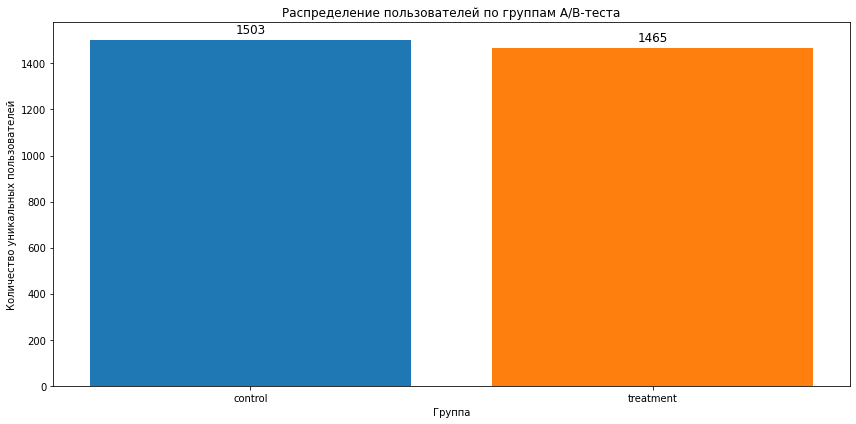

In [218]:
plt.figure(figsize=(12, 6))
plt.bar(
    unique_users['group'],
    unique_users['user_id'],
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Распределение пользователей по группам A/B-теста')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')
plt.tight_layout()


for i, value in enumerate(unique_users['user_id']):
    plt.text(
        i,
        value + max(control_users, test_users) * 0.02,
        str(value),
        ha='center',
        fontsize=12
    )
plt.show()

*Разница по количеству пользователей между группами составляет 2.53%. Это умеренная разница. Пока нет причин, чтобы останавливать тест, но необходимо убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — операционная система, браузер, тип устройства, регион, сегмент пользователя (buyer_segment).*

*Фильтруем данные по периоду эксперимента (3 недели). Для этого объединяем split с users, чтобы получить даты регистрации:*

In [219]:
exp_users_time = split_users.merge(users_ab[['user_id', 'registration_date']], on='user_id', how='left')
exp_users_time['registration_date'] = pd.to_datetime(exp_users_time['registration_date'])

In [220]:
start_date = exp_users_time['registration_date'].min()
end_date = start_date + timedelta(days=21)  # 3 недели эксперимента
print(f"Дата начала эксперимента: {start_date}")
print(f"Дата окончания эксперимента: {end_date}")

Дата начала эксперимента: 2025-01-01 00:05:00
,Дата окончания эксперимента: 2025-01-22 00:05:00


*Для более подробной проверки корректности распределения, объединим датасеты `exp_users_time` и `users_ab`:*

In [221]:
exp_users = exp_users_time.merge(users_ab, on='user_id', how='left')
exp_users["registration_date"] = exp_users["registration_date_x"]
exp_users = exp_users.drop(columns=["registration_date_x", "registration_date_y"])

In [222]:
exp_users.head()

,user_id,group,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month,registration_date
0,44965,control,iOS,66,desktop,M,Новосибирск,Safari,Россия,TikTok,14.00,новичок,one_time,2024-12-30,2025-01-01,2025-01-01 18:10:00
1,44967,control,iOS,70,tablet,M,Московская область,Firefox,Россия,TikTok,13.00,новичок,rare,2024-12-30,2025-01-01,2025-01-01 11:29:00
2,44968,control,Android,68,mobile,F,Нижний Новгород,Edge,Россия,TikTok,10.00,спящий,regular,2024-12-30,2025-01-01,2025-01-01 13:05:00
3,44969,treatment,Windows,24,mobile,F,Краснодар,Chrome,Россия,TikTok,8.00,спящий,medium,2024-12-30,2025-01-01,2025-01-01 00:23:00
4,44970,control,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,2.00,спящий,regular,2024-12-30,2025-01-01,2025-01-01 06:33:00


*Также убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — по типам операционной системы, типу устройства, браузеру, регионам и сегменту пользователя (`buyer_segment`). Для начала получим уникальных пользователей с их **типом операционной системы**:*

In [223]:
users_os = exp_users.drop_duplicates(subset='user_id', keep='last', inplace=False)
control_group_os = users_os[users_os['group'] == 'control'].groupby('os').size()
test_group_os = users_os[users_os['group'] == 'treatment'].groupby('os').size()

*Рассчитаем доли каждого типа устройства для пользователей из контрольной и тестовой групп:*

In [224]:
control_total_os = control_group_os.sum()
test_total_os = test_group_os.sum()
control_perc_os = control_group_os / control_total_os * 100
test_perc_os = test_group_os / test_total_os * 100

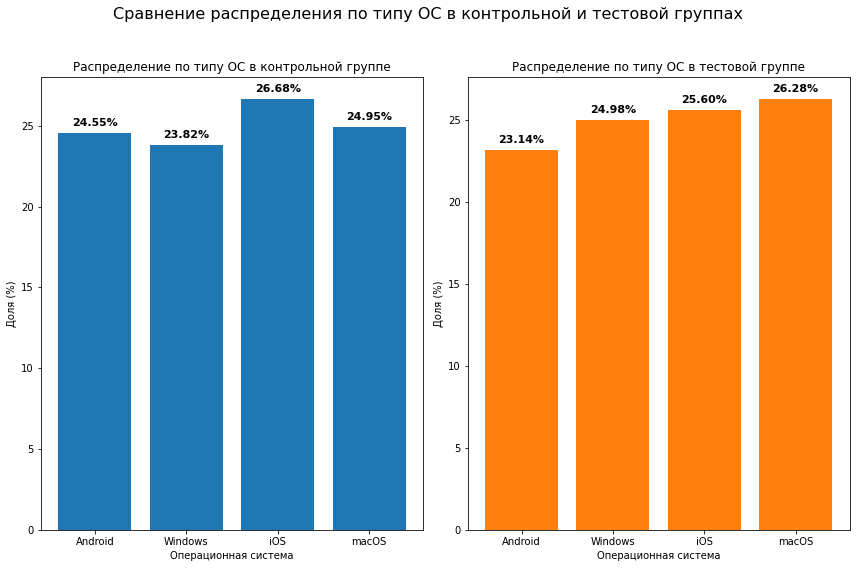

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].bar(
    control_perc_os.index,
    control_perc_os.values,
    color='#1f77b4'
)
axes[0].set_title('Распределение по типу ОС в контрольной группе')
axes[0].set_xlabel('Операционная система')
axes[0].set_ylabel('Доля (%)')

axes[1].bar(
    test_perc_os.index,
    test_perc_os.values,
    color='#ff7f0e'
)
axes[1].set_title('Распределение по типу ОС в тестовой группе')
axes[1].set_xlabel('Операционная система')
axes[1].set_ylabel('Доля (%)')
plt.suptitle('Сравнение распределения по типу ОС в контрольной и тестовой группах', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# Добавляем значения на столбцы
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

In [226]:
os_comparison = pd.DataFrame({
    'ОС': control_group_os.index,
    'Control group': control_group_os.values,
    'Test group': test_group_os.values,
    'Разница (%)': round(((control_group_os - test_group_os) / control_group_os * 100), 2)
})

display (os_comparison)

,ОС,Control group,Test group,Разница (%)
os,,,,
Android,Android,369,339,8.13
Windows,Windows,358,366,-2.23
iOS,iOS,401,375,6.48
macOS,macOS,375,385,-2.67


*Наблюдается умеренный дисбаланс распределения пользователей по контрольной и тестовой группам. Проверим статистическую значимость этих различий. Если p-value больше 0.05 (принятый в аналитике порог значимости), то распределение групп по типу операционной системы корректно и не исказит итоговые метрики теста:*

In [227]:
contingency_os = pd.crosstab(
    users_os['os'],
    users_os['group']
)

In [228]:
chi2, p_value, dof, expected = chi2_contingency(contingency_os)

display (f"Chi2 statistic: {chi2:.3f}")
display (f"p-value: {p_value:.4f}")

'Chi2 statistic: 1.876'

'p-value: 0.5985'

*Рандомизация корректна по признаку `os`. Контрольная и тестовая группы сопоставимы. Тип операционной системы не является источником смещения. Результаты A/B-теста по конверсии в заказ можно интерпретировать корректно.*

*Далее убедимся, что пользователи равномерно распределены по **типу устройства**:*

In [229]:
users_device = exp_users.drop_duplicates(subset='user_id', keep='last', inplace=False)
control_group_device = users_device[users_device['group'] == 'control'].groupby('device').size()
test_group_device = users_device[users_device['group'] == 'treatment'].groupby('device').size()

In [230]:
control_total_device = control_group_device.sum()
test_total_device = test_group_device.sum()
control_perc_device = control_group_device / control_total_device * 100
test_perc_device = test_group_device / test_total_device * 100

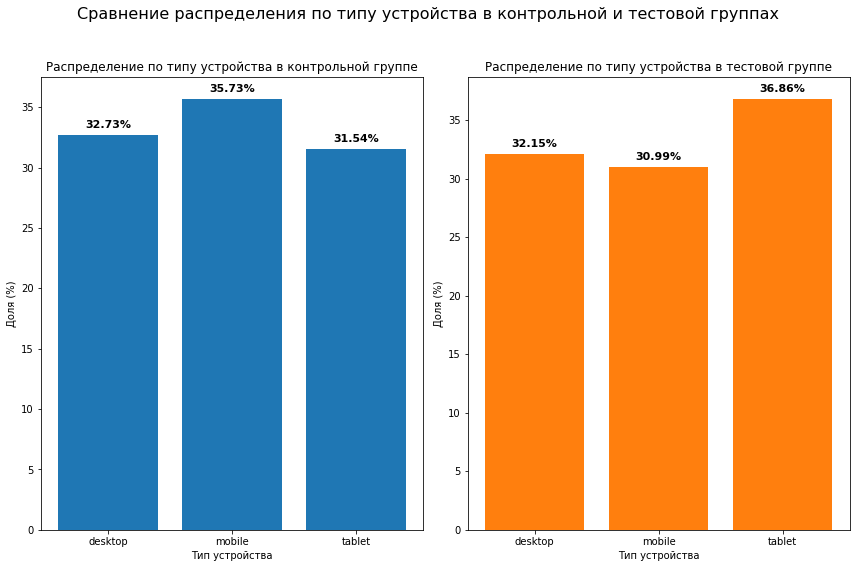

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].bar(
    control_perc_device.index,
    control_perc_device.values,
    color='#1f77b4'
)
axes[0].set_title('Распределение по типу устройства в контрольной группе')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля (%)')

axes[1].bar(
    test_perc_device.index,
    test_perc_device.values,
    color='#ff7f0e'
)
axes[1].set_title('Распределение по типу устройства в тестовой группе')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Доля (%)')
plt.suptitle('Сравнение распределения по типу устройства в контрольной и тестовой группах', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# Добавляем значения на столбцы
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

In [232]:
device_comparison = pd.DataFrame({
    'Устройство': control_group_device.index,
    'Control group': control_group_device.values,
    'Test group': test_group_device.values,
    'Разница (%)': round(((control_group_device - test_group_device) / control_group_device * 100), 2)
})

display (device_comparison)

,Устройство,Control group,Test group,Разница (%)
device,,,,
desktop,desktop,492,471,4.27
mobile,mobile,537,454,15.46
tablet,tablet,474,540,-13.92


In [233]:
contingency_device = pd.crosstab(
    users_device['device'],
    users_device['group']
)

In [234]:
chi2, p_value, dof, expected = chi2_contingency(contingency_device)

display (f"Chi2 statistic: {chi2:.3f}")
display (f"p-value: {p_value:.4f}")

'Chi2 statistic: 11.221'

'p-value: 0.0037'

*В контрольной группе заметно больше пользователей мобильными устройствами (на 15.46 % больше, чем в тестовой), тогда как в тестовой больше пользователей, которые заходят на маркетплейс через планшет (разница почти 14%). Данный перекос **может влиять** на ключевые метрики эксперимента! Эффект от бонуса может быть перепутан с эффектом от устройства. Результаты теста могут быть недостоверными!!!*

*Проведем аналогичную проверку равномерности распределения по **браузерам** пользователей:*

In [235]:
users_browser = exp_users.drop_duplicates(subset='user_id', keep='last', inplace=False)
control_group_browser = users_browser[users_browser['group'] == 'control'].groupby('browser').size()
test_group_browser = users_browser[users_browser['group'] == 'treatment'].groupby('browser').size()

In [236]:
control_total_browser = control_group_browser.sum()
test_total_browser = test_group_browser.sum()
control_perc_browser = control_group_browser / control_total_browser * 100
test_perc_browser = test_group_browser / test_total_browser * 100

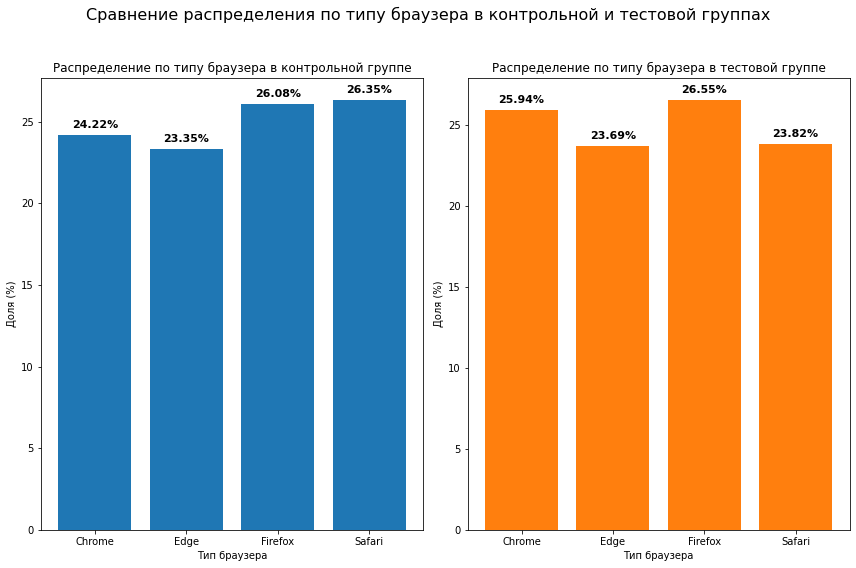

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].bar(
    control_perc_browser.index,
    control_perc_browser.values,
    color='#1f77b4'
)
axes[0].set_title('Распределение по типу браузера в контрольной группе')
axes[0].set_xlabel('Тип браузера')
axes[0].set_ylabel('Доля (%)')

axes[1].bar(
    test_perc_browser.index,
    test_perc_browser.values,
    color='#ff7f0e'
)
axes[1].set_title('Распределение по типу браузера в тестовой группе')
axes[1].set_xlabel('Тип браузера')
axes[1].set_ylabel('Доля (%)')
plt.suptitle('Сравнение распределения по типу браузера в контрольной и тестовой группах', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# Добавляем значения на столбцы
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

In [238]:
browser_comparison = pd.DataFrame({
    'Браузер': control_group_browser.index,
    'Control group': control_group_browser.values,
    'Test group': test_group_browser.values,
    'Разница (%)': round(((control_group_browser - test_group_browser) / control_group_browser * 100), 2)
})

display (browser_comparison)

,Браузер,Control group,Test group,Разница (%)
browser,,,,
Chrome,Chrome,364,380,-4.40
Edge,Edge,351,347,1.14
Firefox,Firefox,392,389,0.77
Safari,Safari,396,349,11.87


*Наблюдается умеренный дисбаланс распределения пользователей по контрольной и тестовой группам. Проверим статистическую значимость этих различий:*

In [239]:
contingency_browser = pd.crosstab(
    users_browser['browser'],
    users_browser['group']
)

In [240]:
chi2, p_value, dof, expected = chi2_contingency(contingency_browser)

display (f"Chi2 statistic: {chi2:.3f}")
display (f"p-value: {p_value:.4f}")

'Chi2 statistic: 2.858'

'p-value: 0.4141'

*Рандомизация корректна по признаку `browser`. Контрольная и тестовая группы сопоставимы. Тип браузера не является источником смещения. Результаты A/B-теста по конверсии в заказ можно интерпретировать корректно.*

*Наблюдается умеренный дисбаланс выборки (11.87%) среди пользователей браузера Safari. Такой дисбаланс допустим, если выборка большая, как в нашем случае, но ранее мы выяснили, что пользователи iOS и MacOS (которые непосредственно используют браузер Safari) являются более лояльными пользователями, с более высокой покупательской способностью), поэтому такой дисбаланс может исказить итоговые метрики теста.*

*Переходим к анализу равномерности распределения по **регионам** пользователей:*

In [241]:
users_region = exp_users.drop_duplicates(subset='user_id', keep='last', inplace=False)
control_group_region = users_region[users_region['group'] == 'control'].groupby('region').size()
test_group_region = users_region[users_region['group'] == 'treatment'].groupby('region').size()

In [242]:
control_total_region = control_group_region.sum()
test_total_region = test_group_region.sum()
control_perc_region = control_group_region / control_total_region * 100
test_perc_region = test_group_region / test_total_region * 100

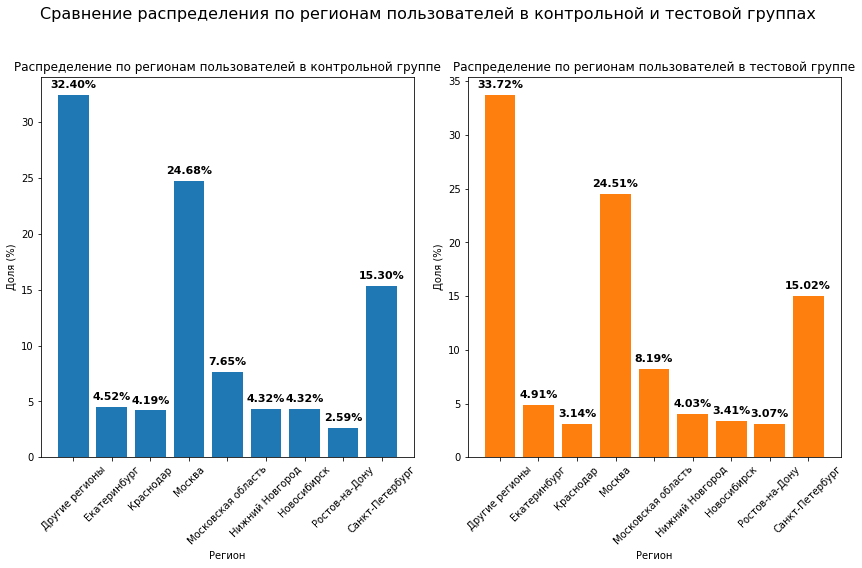

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].bar(
    control_perc_region.index,
    control_perc_region.values,
    color='#1f77b4'
)
axes[0].set_title('Распределение по регионам пользователей в контрольной группе')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Доля (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(
    test_perc_region.index,
    test_perc_region.values,
    color='#ff7f0e'
)
axes[1].set_title('Распределение по регионам пользователей в тестовой группе')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Доля (%)')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('Сравнение распределения по регионам пользователей в контрольной и тестовой группах', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# Добавляем значения на столбцы
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

In [244]:
region_comparison = pd.DataFrame({
    'Регион': control_group_region.index,
    'Control group': control_group_region.values,
    'Test group': test_group_region.values,
    'Разница (%)': round(((control_group_region - test_group_region) / control_group_region * 100), 2)
})

display (region_comparison)

,Регион,Control group,Test group,Разница (%)
region,,,,
Другие регионы,Другие регионы,487,494,-1.44
Екатеринбург,Екатеринбург,68,72,-5.88
Краснодар,Краснодар,63,46,26.98
Москва,Москва,371,359,3.23
Московская область,Московская область,115,120,-4.35
Нижний Новгород,Нижний Новгород,65,59,9.23
Новосибирск,Новосибирск,65,50,23.08
Ростов-на-Дону,Ростов-на-Дону,39,45,-15.38
Санкт-Петербург,Санкт-Петербург,230,220,4.35


*Наблюдается достаточно сильный дисбаланс распределения пользователей по контрольной и тестовой группам по регионам Краснодар, Новосибирск и Ростов-на-Дону. Проверим статистическую значимость этих различий:*

In [245]:
contingency_region = pd.crosstab(
    users_region['region'],
    users_region['group']
)

In [246]:
chi2, p_value, dof, expected = chi2_contingency(contingency_region)

print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

Chi2 statistic: 5.531
,p-value: 0.6996


*Рандомизация корректна по признаку `region`. Контрольная и тестовая группы сопоставимы. Регион пользователя не является источником смещения. Результаты A/B-теста по конверсии в заказ можно интерпретировать корректно.*

*Большой дисбаланс распределения пользователей по группам наблюдается по Краснодару (разница почти 27% и Новосибирску (разница 23%). Краснодар является регионом с высоким ARPU, тогда как Новосибирск - наоборот (ARPU очень низкий). Это важные для анализа регионы, где баланс между группами необходим. Такой дисбаланс может сделать эксперимент менее достоверным.*

*Теперь убедимся, что пользователи равномерно распределены по сегментам частоты покупок:*

In [247]:
users_buyer_segment = exp_users.drop_duplicates(subset='user_id', keep='last', inplace=False)
control_group_buyer_segment = users_buyer_segment[users_buyer_segment['group'] == 'control'].groupby('buyer_segment').size()
test_group_buyer_segment = users_buyer_segment[users_buyer_segment['group'] == 'treatment'].groupby('buyer_segment').size()

In [248]:
control_total_buyer_segment = control_group_buyer_segment.sum()
test_total_buyer_segment = test_group_buyer_segment.sum()
control_perc_buyer_segment = control_group_buyer_segment / control_total_buyer_segment * 100
test_perc_buyer_segment = test_group_buyer_segment / test_total_buyer_segment * 100

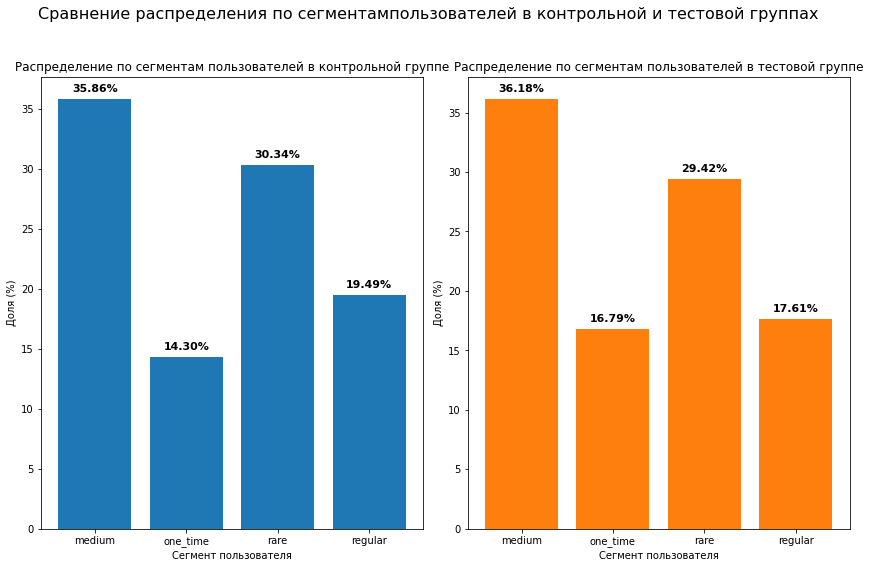

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].bar(
    control_perc_buyer_segment.index,
    control_perc_buyer_segment.values,
    color='#1f77b4'
)
axes[0].set_title('Распределение по сегментам пользователей в контрольной группе')
axes[0].set_xlabel('Сегмент пользователя')
axes[0].set_ylabel('Доля (%)')

axes[1].bar(
    test_perc_buyer_segment.index,
    test_perc_buyer_segment.values,
    color='#ff7f0e'
)
axes[1].set_title('Распределение по сегментам пользователей в тестовой группе')
axes[1].set_xlabel('Сегмент пользователя')
axes[1].set_ylabel('Доля (%)')
plt.suptitle('Сравнение распределения по сегментампользователей в контрольной и тестовой группах', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# Добавляем значения на столбцы
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

In [250]:
buyer_segment_comparison = pd.DataFrame({
    'Сегмент пользователя': control_group_buyer_segment.index,
    'Control group': control_group_buyer_segment.values,
    'Test group': test_group_buyer_segment.values,
    'Разница (%)': round(((control_group_buyer_segment - test_group_buyer_segment) / control_group_buyer_segment * 100), 2)
})

display (buyer_segment_comparison)

,Сегмент пользователя,Control group,Test group,Разница (%)
buyer_segment,,,,
medium,medium,539,530,1.67
one_time,one_time,215,246,-14.42
rare,rare,456,431,5.48
regular,regular,293,258,11.95


*Наблюдается умеренный дисбаланс распределения пользователей по контрольной и тестовой группам. Проверим статистическую значимость этих различий:*

In [251]:
contingency_buyer_segment = pd.crosstab(
    users_buyer_segment['buyer_segment'],
    users_buyer_segment['group']
)

In [252]:
chi2, p_value, dof, expected = chi2_contingency(contingency_buyer_segment)

print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

Chi2 statistic: 4.602
,p-value: 0.2033


*Рандомизация корректна по признаку `buyer_segment`. Контрольная и тестовая группы сопоставимы. Сегмент пользователя не является источником смещения. Результаты A/B-теста по конверсии в заказ можно интерпретировать корректно.*

*Перейдем к сравнению воронок событий в контрольной и тестовой группах. Для начала построим и визуализируем **классическую воронку** для контрольной и тестовой групп, чтобы понять, какой процент пользователей теряется на каждом этапе воронки относительно первого шага:*

*Для начала добавим в нашу таблицу данные по типу события из таблицы `events_ab`:*

In [253]:
abt_users = exp_users.merge(events_ab[['user_id', 'event_type']], on='user_id', how='left')

In [254]:
abt_users.info()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 6818 entries, 0 to 6817
,Data columns (total 17 columns):
, #   Column             Non-Null Count  Dtype         
,---  ------             --------------  -----         
, 0   user_id            6818 non-null   int64         
, 1   group              6818 non-null   object        
, 2   os                 6818 non-null   object        
, 3   age                6818 non-null   int64         
, 4   device             6818 non-null   object        
, 5   gender             6818 non-null   object        
, 6   region             6818 non-null   object        
, 7   browser            6818 non-null   object        
, 8   country            6818 non-null   object        
, 9   acq_channel        6818 non-null   object        
, 10  campaign_id        6818 non-null   float64       
, 11  user_segment       6818 non-null   object        
, 12  buyer_segment      6818 non-null   object        
, 13  cohort_week        6818 non-null   datetime64

*Отфильтруем датасет по группам:*

In [255]:
abt_control = abt_users[abt_users['group'] == 'control']
abt_test = abt_users[abt_users['group'] == 'treatment']

*Классическая воронка для контрольной группы:*

In [256]:
abt_control_steps = abt_control[abt_control['event_type'].isin(funnel_sequence)]
abt_control_steps = abt_control_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_sequence).reset_index()
abt_control_steps = abt_control_steps.rename(columns={'user_id': 'users_n'})

*Классическая воронка для тестовой группы:*

In [257]:
abt_test_steps = abt_test[abt_test['event_type'].isin(funnel_sequence)]
abt_test_steps = abt_test_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_sequence).reset_index()
abt_test_steps = abt_test_steps.rename(columns={'user_id': 'users_n'})

*Конверсия от первого шага воронки:*

In [258]:
abt_control_steps['conversion_from_first_step_%'] = abt_control_steps['users_n'] / abt_control_steps['users_n'].iloc[0] * 100
abt_test_steps['conversion_from_first_step_%'] = abt_test_steps['users_n'] / abt_test_steps['users_n'].iloc[0] * 100

*Визуализация классической воронки:*

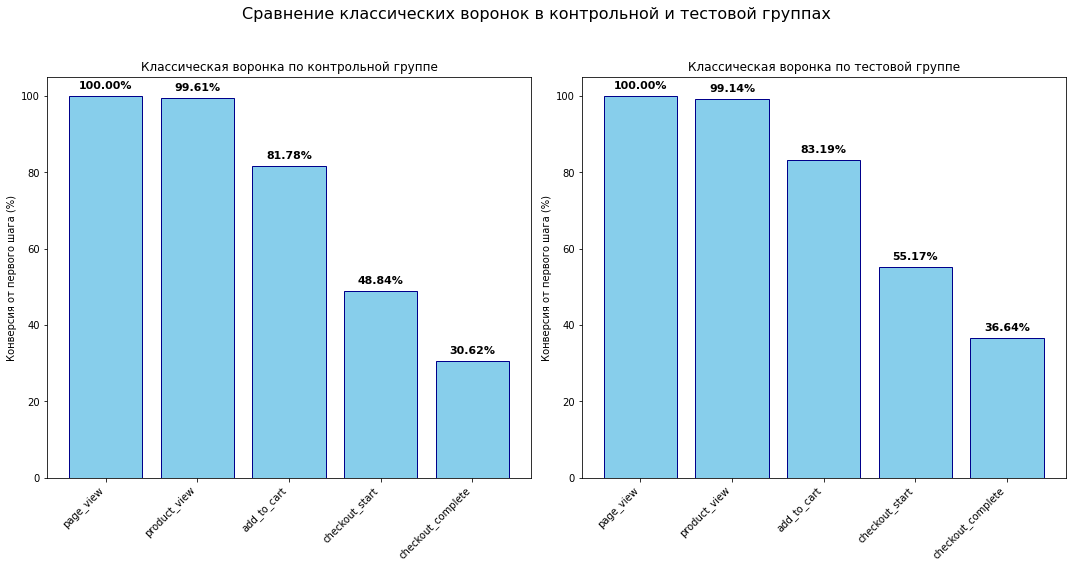

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].bar(
    abt_control_steps['conversion_from_first_step_%'].index,
    abt_control_steps['conversion_from_first_step_%'].values,
    color='skyblue', edgecolor='darkblue'
)
axes[0].set_xticks(range(len(abt_control_steps)))
axes[0].set_xticklabels(funnel_sequence, rotation=45, ha='right')
axes[0].set_title('Классическая воронка по контрольной группе')
axes[0].set_ylabel('Конверсия от первого шага (%)')

axes[1].bar(
    abt_test_steps['conversion_from_first_step_%'].index,
    abt_test_steps['conversion_from_first_step_%'].values,
    color='skyblue', edgecolor='darkblue'
)
axes[1].set_xticks(range(len(abt_test_steps)))
axes[1].set_xticklabels(funnel_sequence, rotation=45, ha='right')
axes[1].set_title('Классическая воронка по тестовой группе')
axes[1].set_ylabel('Конверсия от первого шага (%)')
plt.suptitle('Сравнение классических воронок в контрольной и тестовой группах', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

*Очевидно, что пользователи тестовой группы, которая применила бонус на покупку, стали активнее завершать оформление заказа (конверсия в начало оформления заказа увеличилась на 7 % относительно первого шага - просмотр страницы приложения, а в завершение оформления - на 6%).*

*Теперь построим и визуализируем **пошаговую воронку** для контрольной и тестовой групп.*

*Пошаговая воронка для контрольной группы:*

In [260]:
sbs_control_steps = abt_control[abt_control['event_type'].isin(funnel_sequence)]
sbs_control_steps = sbs_control_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_sequence).reset_index()
sbs_control_steps = sbs_control_steps.rename(columns={'user_id': 'users_n'})

*Пошаговая воронка для тестовой группы:*

In [261]:
sbs_test_steps = abt_test[abt_test['event_type'].isin(funnel_sequence)]
sbs_test_steps = sbs_test_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_sequence).reset_index()
sbs_test_steps = sbs_test_steps.rename(columns={'user_id': 'users_n'})

*Конверсия от предыдущего шага воронки:*

In [262]:
sbs_control_steps['conversion_from_previous_step_%'] = sbs_control_steps['users_n'] / sbs_control_steps['users_n'].shift(1) * 100
sbs_test_steps['conversion_from_previous_step_%'] = sbs_test_steps['users_n'] / sbs_test_steps['users_n'].shift(1) * 100

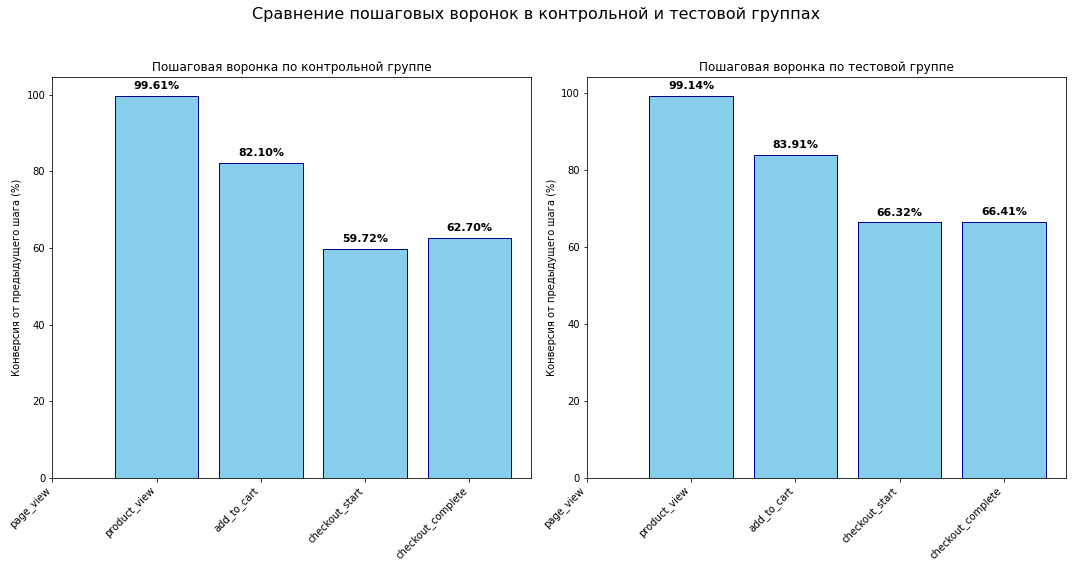

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].bar(
    sbs_control_steps['conversion_from_previous_step_%'].index,
    sbs_control_steps['conversion_from_previous_step_%'].values,
    color='skyblue', edgecolor='darkblue'
)
axes[0].set_xticks(range(len(sbs_control_steps)))
axes[0].set_xticklabels(funnel_sequence, rotation=45, ha='right')
axes[0].set_title('Пошаговая воронка по контрольной группе')
axes[0].set_ylabel('Конверсия от предыдущего шага (%)')

axes[1].bar(
    sbs_test_steps['conversion_from_previous_step_%'].index,
    sbs_test_steps['conversion_from_previous_step_%'].values,
    color='skyblue', edgecolor='darkblue'
)
axes[1].set_xticks(range(len(sbs_test_steps)))
axes[1].set_xticklabels(funnel_sequence, rotation=45, ha='right')
axes[1].set_title('Пошаговая воронка по тестовой группе')
axes[1].set_ylabel('Конверсия от предыдущего шага (%)')
plt.suptitle('Сравнение пошаговых воронок в контрольной и тестовой группах', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', 
                    va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords="offset points")
plt.show()

*Пошаговая воронка показала, что в тестовой группе отток пользователей происходит плавнее, нет видимых провалов и конверсия в предыдущий шаг выше, чем в контрольной. Это означает, что предложение бонусов дает положительные результаты.*

**Анализ ключевой метрики - конверсия в первую покупку.**

*Ключевой метрикой в нашем случае является конверсия в первую покупку (доля пользователей, зарегистрировавшихся с канала привлечения TikTok и совершивших первую покупку). Проанализируем, как финансовые стимуляции пользователей (в нашем случае это бонус на первую покупку) повлияли на конверсию.*

*Сортируем заказы по дате и берем первый заказ каждого пользователя:*

In [264]:
orders_sorted = orders_ab.sort_values(['user_id', 'order_date'])
first_orders = orders_sorted.drop_duplicates(subset='user_id', keep='first')[['user_id', 'order_date']]

In [265]:
abt_users_orders = exp_users.merge(first_orders, on='user_id', how='left')

*Создаём флаг «первая покупка была» (1 - первая покупка была, 0 - покупки не было):*

In [266]:
abt_users_orders['made_first_purchase'] = abt_users_orders['order_date'].notna().astype(int)

*Рассчитываем конверсию в первый заказ:*

In [267]:
abt_conversion = (abt_users_orders.groupby('group')['made_first_purchase'].agg(['mean', 'sum', 'count']).reset_index())
abt_conversion.columns = ['group', 'conversion', 'buyers', 'users']
display(abt_conversion)

,group,conversion,buyers,users
0,control,0.01,16,1503
1,treatment,0.08,110,1465


*Очевидно, что конверсия в первый заказ у тестовой группы значительно повысилась, как и повысилось количество пользователей, которые завершили оформление заказа.*

*Проверим статистическую значимость различий ключевой метрики. Так как мы анализируем доли пользователей (первая покупка совершена/не совершена) применим **Z-тест пропорций** (это статистический тест, который позволяет определить существует ли значимая разница между долями в двух независимых выборках (контрольной и тестовой группах)).*

In [268]:
successes = abt_conversion['buyers']
nobs = abt_conversion['users']

z_stat, p_value = proportions_ztest(successes, nobs)

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.20f}")

z-statistic: -8.705
,p-value: 0.00000000000000000316


*Значение p-value в нашем случае практически нулевое, что означает очень большую разницу ключевой метрики между контрольной и тестовой группами. Различия статистически значимы. Очевиден сильный положительный эффект после внедрения бонуса на первую покупку. Однако, стоит отметить, что ранее нами было выявлено нарушение распределения пользователей по типу устройства, а устройство может сильно влиять на конверсию в первый заказ. Поэтому эффект может быть частично объяснён устройствами, а не бонусом.*

**Анализ вспомогательных и барьерных метрик**

*Вспомогательными метриками в нашем случае служат ARPU, ARPPU, AOV, а барьерной метрикой является общая выручка. Рассчитаем их:*

In [269]:
abt_orders = exp_users.merge(orders_ab, on='user_id', how='left')

In [270]:
metrics = []

for group_name, df in abt_orders.groupby('group'):
    
    users = df['user_id'].nunique()
    buyers = df[df['order_id'].notna()]['user_id'].nunique()
    orders = df['order_id'].nunique()
    revenue = df['total_price'].sum()

    arpu = revenue / users if users > 0 else 0
    arppu = revenue / buyers if buyers > 0 else 0
    aov = revenue / orders if orders > 0 else 0

    metrics.append({
        'group': group_name,
        'users': users,
        'buyers': buyers,
        'orders': orders,
        'revenue': revenue,
        'ARPU': arpu,
        'ARPPU': arppu,
        'AOV': aov
    })

abt_metrics = pd.DataFrame(metrics).set_index('group')
display (abt_metrics)

,users,buyers,orders,revenue,ARPU,ARPPU,AOV
group,,,,,,,
control,1503,16,24,378372.90,251.75,23648.31,15765.54
treatment,1465,110,231,3845597.03,2624.98,34959.97,16647.61


*Визуализируем, чтобы наглядно увидить изменения между контрольной и тестовой группами:*

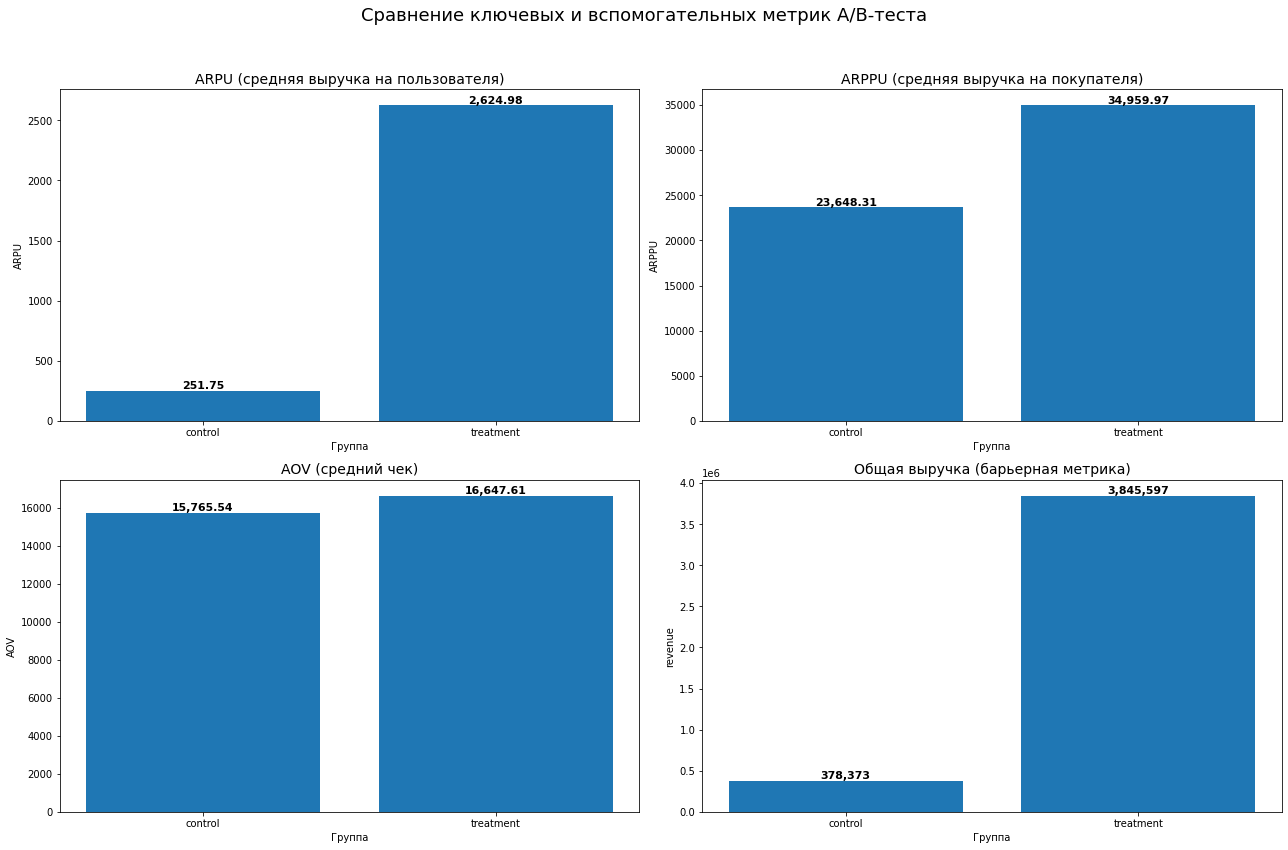

In [271]:
metrics_to_plot = ['ARPU', 'ARPPU', 'AOV', 'revenue']
titles = {
    'ARPU': 'ARPU (средняя выручка на пользователя)',
    'ARPPU': 'ARPPU (средняя выручка на покупателя)',
    'AOV': 'AOV (средний чек)',
    'revenue': 'Общая выручка (барьерная метрика)'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    
    values = abt_metrics[metric]
    
    ax.bar(values.index, values.values)
    ax.set_title(titles[metric], fontsize=14)
    ax.set_xlabel('Группа')
    ax.set_ylabel(metric)
    
    # подписи значений
    for i, value in enumerate(values.values):
        ax.text(
            i,
            value,
            f'{value:,.2f}' if metric != 'revenue' else f'{value:,.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

plt.suptitle(
    'Сравнение ключевых и вспомогательных метрик A/B-теста',
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*Очевидно, что бонусная система очень хорошо увеличила выручку на одного активного пользователя маркетплейса. Чуть меньше, но все же увеличила выручку на одного платящего пользователя, а вот средний чек покупки не сильно изменился, хотя и остается довольно высоким.*

*Проверим статистическую значимость изменений методом bootstrap (так как мы проверяем средние значения), чтобы понять насколько сильными стали изменения. Для начала проверим значимость изменений **ARPU**:*

In [272]:
def bootstrap_arpu(df_control, df_treatment, n_bootstrap=10_000, seed=42):
    np.random.seed(seed)

    control_users = df_control.groupby('user_id')['total_price'].sum()
    treatment_users = df_treatment.groupby('user_id')['total_price'].sum()

    diffs = []

    for _ in range(n_bootstrap):
        control_sample = control_users.sample(
            n=len(control_users),
            replace=True
        ).mean()

        treatment_sample = treatment_users.sample(
            n=len(treatment_users),
            replace=True
        ).mean()

        diffs.append(treatment_sample - control_sample)

    return np.array(diffs)

In [273]:
df_control = abt_orders[abt_orders['group'] == 'control']
df_treatment = abt_orders[abt_orders['group'] == 'treatment']
arpu_diff = bootstrap_arpu(df_control, df_treatment)

In [274]:
ci_low, ci_high = np.percentile(arpu_diff, [2.5, 97.5])
p_value = np.mean(arpu_diff <= 0)
display (f"ARPU diff CI: [{ci_low:.2f}, {ci_high:.2f}]")
display (f"p-value = {p_value:.4f}")

'ARPU diff CI: [1635.57, 3193.60]'

'p-value = 0.0000'

*Средняя выручка на одного пользователя в тестовой группе статистически значимо выше, чем в контрольной. Пользователи с бонусом приносят значительно больше денег на одного пользователя, чем без бонуса.*

*Сделаем такую же проверку для **ARPPU**.*

In [275]:
def bootstrap_arppu(df_control, df_treatment, n_bootstrap=10_000, seed=42):
    np.random.seed(seed)

    control_buyers = (
        df_control[df_control['order_id'].notna()]
        .groupby('user_id')['total_price']
        .sum()
    )

    treatment_buyers = (
        df_treatment[df_treatment['order_id'].notna()]
        .groupby('user_id')['total_price']
        .sum()
    )

    diffs = []

    for _ in range(n_bootstrap):
        control_sample = control_buyers.sample(
            n=len(control_buyers),
            replace=True
        ).mean()

        treatment_sample = treatment_buyers.sample(
            n=len(treatment_buyers),
            replace=True
        ).mean()

        diffs.append(treatment_sample - control_sample)

    return np.array(diffs)

In [276]:
arppu_diff = bootstrap_arppu(df_control, df_treatment)
ci_low, ci_high = np.percentile(arppu_diff, [2.5, 97.5])
p_value = np.mean(arppu_diff <= 0)
display (f"ARPPU diff CI: [{ci_low:.2f}, {ci_high:.2f}]")
display (f"p-value ≈ {p_value:.4f}")

'ARPPU diff CI: [269.38, 22395.79]'

'p-value ≈ 0.0225'

*Средняя выручка на одного платящего пользователя в тестовой группе статистически значимо выше, чем в контрольной, но эффект менее стабильный, чем у ARPU. Даже среди покупателей пользователи с бонусом в среднем тратят больше, чем покупатели без бонуса.*

*Аналогично для **AOV**.*

In [277]:
def bootstrap_aov(df_control, df_treatment, n_bootstrap=10_000, seed=42):
    np.random.seed(seed)

    control_orders = df_control[df_control['order_id'].notna()]['total_price']
    treatment_orders = df_treatment[df_treatment['order_id'].notna()]['total_price']

    diffs = []

    for _ in range(n_bootstrap):
        control_sample = control_orders.sample(
            n=len(control_orders),
            replace=True
        ).mean()

        treatment_sample = treatment_orders.sample(
            n=len(treatment_orders),
            replace=True
        ).mean()

        diffs.append(treatment_sample - control_sample)

    return np.array(diffs)

In [278]:
aov_diff = bootstrap_aov(df_control, df_treatment)
ci_low, ci_high = np.percentile(aov_diff, [2.5, 97.5])
p_value = np.mean(aov_diff <= 0)
display (f"AOV diff CI: [{ci_low:.2f}, {ci_high:.2f}]")
display (f"p-value ≈ {p_value:.4f}")

'AOV diff CI: [-5565.94, 6818.71]'

'p-value ≈ 0.3757'

*Различий в среднем чеке нет. Бонус не изменил размер одного заказа. Пользователи не стали покупать дешевле или дороже за один раз.*

*Проверим статистическую значимость изменений метрики **"Общая выручка"**. Данная метрика для нас является барьерной и важно, чтобы не было ухудшений:*

In [279]:
revenue_per_user = (abt_orders.groupby(['group', 'user_id'], as_index=False)['total_price'].sum())

In [280]:
def bootstrap_revenue_diff(df, n_bootstrap=10_000, seed=42):
    np.random.seed(seed)

    control = df[df['group'] == 'control']['total_price'].values
    treatment = df[df['group'] == 'treatment']['total_price'].values

    diffs = []
    for _ in range(n_bootstrap):
        c_sample = np.random.choice(control, size=len(control), replace=True)
        t_sample = np.random.choice(treatment, size=len(treatment), replace=True)
        diffs.append(t_sample.sum() - c_sample.sum())

    diffs = np.array(diffs)

    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_value = np.mean(diffs <= 0) * 2  # двусторонний тест

    return ci_low, ci_high, p_value

In [281]:
ci_low, ci_high, p_value = bootstrap_revenue_diff(revenue_per_user)
display (f"Revenue diff CI: [{ci_low:,.0f}, {ci_high:,.0f}]")
display (f"p-value ≈ {p_value:.4f}")

'Revenue diff CI: [2,386,117, 4,668,534]'

'p-value ≈ 0.0000'

*Барьерная метрика — общая выручка — статистически значимо выросла в тестовой группе. Бонус на первую покупку не только увеличил конверсию, но и привёл к реальному росту дохода маркетплейса.*

## Выводы по этапу 5

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

*Какие выводы мы можем сделать по итогу проведения эксперимента?*

**Цель эксперимента:**

*Проверить, приводит ли предоставление бонуса на первую покупку пользователям, привлечённым через TikTok, к росту конверсии в первую покупку, не уменьшая при этом общую выручку маркетплейса.*

**Описание эксперимента:**

*Тип: A/B-тест (rolling split)*

*Аудитория: только пользователи TikTok.*

*Группы:*
- *`Control` — без бонуса*
- *`Treatment` — с бонусом на первую покупку*

*Размер выборки:*
- *`Control`: 1 503 пользователя*
- *`Treatment`: 1 465 пользователей*
- *Разница: 2.53% (это допустимо при нашем объёме выборки)*

*Эксперимент длился 3 недели. Из-за срочности задачи запуск эксперимента был проведен без предварительного расчета мощности теста (вероятность обнаружить эффект, если он есть) и MDE (минимальное изменение метрики, которое тест должен выявить).*

**Проверка корректности эксперимента:**

*Распределение пользователей по ОС, браузеру, региону и сегменту пользователя статистически не отличается и не влияет на результаты теста. Однако, была выявлена большая разница по количеству пользователей между группами по типу устройства. Так в контрольной группе больше пользователей, которые заходят в маркетплейс с мобильных устройств (на 15.46% больше, чем в тестовой группе), тогда как в тестовой больше пользователей, которые заходят на маркетплейс через планшет (разница почти 14%). Тип устройства может влиять на поведение и конверсию, поэтому часть эффекта бонуса может быть объяснена различиями в устройствах, что может повлиять на результаты теста и сделать их недостоверными. На данном этапе стоит остановить эксперимент и повторно сделать выборку, но уже с корректным распределением пользователей по типу устройства.*

**Анализ воронки:**

*В тестовой группе пользователи чаще доходят до оформления заказа. Отток между шагами более плавный. Конверсия между шагами выше, чем в контрольной группе. Бонус снижает барьеры и мотивирует пользователей завершать покупку.*

**Ключевая метрика — конверсия в первую покупку:**

*Конверсия в первую покупку выросла в 8 раз, различие статистически значимо. Бонус оказывает сильный положительный эффект. Однако, часть эффекта может быть усилена дисбалансом по устройствам!*

**Вспомогательные и барьерная метрики:**

*ARPU и ARPPU статистически значимо увеличились. Средний чек при этом не снизился. Общая выручка выросла в 10 раз! Однако, снова отмечу, что часть эффекта может быть усилена дисбалансом по устройствам!*

**Рекомендации:**

*Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку. И эта фича работает. Бонус увеличивает и конверсию, и выручку, не имея негативного влияния на средний чек пользователя. Канал привлечения TikTok не стоит закрывать, так как он реально приводит "платежеспособных" клиентов (что видно по среднему чеку и увеличению выручки в несколько раз), которые позитивно отреагировали на предложение бонуса на первую покупку.*

*Однако, перед масштабированием также рекомендую провести повторный тест, но уже с корректным распределением пользователей на группы по типу устройств. Тогда мы убедимся, что эффект от бонуса действительно не случаен и тип устройства никак не влияет на такой резкий рост метрик!*

*Дополнительно, можно проверить, какой была рекламная кампания для пользователей, которые пришли с канала TikTok. Вероятно, рекламные предложения были не совсем корректны и вводили новых пользователей в заблуждение, в связи с чем метрики этого канала изначально показывали максимально плохие значения.*